# `GEA` demo: a Disease Graph Atlas from DISEASES + STRING

**Part 1 — data extraction and graph construction.**

The GEA tutorials so far build *sample-specific* networks (LIONESS co-expression + STRING prior),
where one graph = one biological sample. That works well for the node- and edge-level SAEs, but the
graph-level SAE has little to say: "properties of one LIONESS artefact" is hard to name biologically.

This notebook builds the alternative dataset — the **Disease Graph Atlas** — in which

$$\text{one graph} \;=\; \text{one disease}$$

$$G_d = (V_d,\; E_d,\; X_d,\; W_d)$$

| symbol | content | source |
|---|---|---|
| $V_d$ | protein-coding genes associated with disease $d$ | DISEASES gene–disease associations |
| $E_d$ | interactions **among those genes** (induced subgraph, no 1-hop expansion yet) | STRING |
| $X_d$ | node features: association evidence $\Vert$ per-graph topology $\Vert$ ESM-2 protein embedding | DISEASES + STRING + ESM-2 |
| $W_d$ | edge weights: STRING confidence $s_{ij}/1000$ | STRING |

Gene identity travels with the node through its ESM-2 embedding ("*what is this protein*"), while the
graph supplies the disease context ("*what is it doing here*"). That is why variable node sets across
diseases are acceptable: nodes do not need a shared index to be comparable.

**The universe is all of DISEASES.** Section 1 curates nothing: it reads every DOID in the DISEASES
file whose gene set is large enough, drops the ontology's own umbrella terms ("disease", "cancer",
"nervous system disease" — groupings, not disease modules), and keeps what is left. At the defaults
that is ~1,750 diseases across 18 Disease Ontology categories. An earlier version of this notebook
used a hand-checked 90-disease universe instead; its artefacts are tagged `diseases` rather than
`diseases-all` and are untouched on disk, so the two atlases can be compared.

**Scope of this notebook (Part 1):** disease universe → DISEASES retrieval → QC → gene filtering →
gene→protein mapping → STRING backbone → ESM node features → PyG graphs → graph QC → export.
Deliberately *no* model: the GCN, the three SAEs and the interpretation experiments come in Part 2,
so that any weirdness later can be attributed to the model rather than the dataset.

**Deliberately simple baseline.** Induced subgraph only (no 1-hop expansion), STRING confidence as a
single edge weight, one gene set per disease. Network expansion, GRN edges and multi-evidence seed
sets are follow-up ablations, not part of the first dataset.

## 0 — Configuration

In [ ]:
import gzip
import hashlib
import json
import os
import time
from pathlib import Path

import numpy as np
import pandas as pd
import requests
import torch
from tqdm.auto import tqdm

from gea.gea import set_seed

# ── Reproducibility ──────────────────────────────────────────────────────────
# One seed for the whole notebook. It fixes the fallback vectors drawn for genes missing from the ESM
# file (section 6), the train/val split, weight initialisation, every mask and augmentation drawn
# during training, and the resampling the section-15 metrics do. Determinism on GPU is best-effort:
# the scatter-add inside message passing has no deterministic CUDA kernel, so a metric's last digit
# still moves between runs — roughly ±0.01 on the edge AUC and ±0.05 on the section-15 correlations.
SEED = 42
DETERMINISTIC = True   # exact re-runs, at a price: forcing deterministic CUDA kernels made GCN

                       # training ~3× slower on this atlas (1.7 s/epoch against 0.5 s). Set False
                       # while iterating, True for anything you intend to report.
os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")   # must precede CUDA initialisation
set_seed(SEED)
if DETERMINISTIC:
    torch.use_deterministic_algorithms(True, warn_only=True)

# ── Paths ────────────────────────────────────────────────────────────────────
DATA_DIR   = Path("data/disgenet")         # historical name, kept so existing artefacts still resolve
STRING_DIR = DATA_DIR / "string"           # STRING bulk downloads (cached, ~160 MB)
for d in (DATA_DIR, STRING_DIR):
    d.mkdir(parents=True, exist_ok=True)

# Tag carried by every artefact name. Seeds come from Jensen-lab DISEASES (section 2); the tag exists
# so a second seed source — or a second slice of this one — can be added without overwriting an
# existing atlas. "diseases-all" is the whole of DISEASES, the universe section 1 builds; the earlier
# hand-curated 90-disease universe was tagged "diseases", and its artefacts (graphs, encoder, SAEs)
# are untouched on disk, so the two atlases can be compared rather than one replacing the other.
ATLAS_TAG = "diseases-all"

DISEASES_DIR = DATA_DIR / "diseases"       # DISEASES bulk downloads
DISEASES_DIR.mkdir(parents=True, exist_ok=True)
DISEASES_CHANNEL  = "integrated"           # "knowledge" (curated only) | "integrated" (+GWAS+text mining)
DISEASES_MIN_CONF = 2.0                    # DISEASES confidence is a 0–5 star scale

# Artefacts carry the atlas tag in their name so two atlases never overwrite each other.
UNIVERSE_FILE = DATA_DIR / f"disease_universe_{ATLAS_TAG}.tsv"        # the disease universe (cache)
GDA_FILE      = DATA_DIR / f"gene_disease_seeds_{ATLAS_TAG}.tsv.gz"   # tidy association table (cache)
MYGENE_FILE   = DATA_DIR / f"mygene_map_{ATLAS_TAG}.tsv"              # frozen mygene answer (§4)
GENEMAP_FILE  = DATA_DIR / f"gene_protein_map_{ATLAS_TAG}.tsv"        # gene → Ensembl → STRING protein
ENSEMBL_FILE  = DATA_DIR / f"ensembl_ids_{ATLAS_TAG}.txt"             # input for get_esm_embeddings.py
ESM_FILE      = DATA_DIR / f"esm_embeddings_{ATLAS_TAG}.pt"           # output of get_esm_embeddings.py
# The embeddings for one atlas can end up spread over several files: a top-up run for genes a
# previous pass missed, or the file computed for an earlier atlas that still covers most of this
# one. Section 6 merges everything in ESM_SOURCES (priority order, first file wins) into one
# consensus file rather than recomputing ~10,000 proteins to add a handful, and writes whatever is
# still uncovered to ESM_MISSING_FILE as the gene list for a top-up run.
ESM_SOURCES        = [ESM_FILE, DATA_DIR / "esm_embeddings_diseases.pt"]
ESM_CONSENSUS_FILE = DATA_DIR / f"esm_embeddings_{ATLAS_TAG}_consensus.pt"
ESM_MISSING_FILE   = DATA_DIR / f"ensembl_ids_{ATLAS_TAG}_missing.txt"
BUILD_ESM_CONSENSUS = True    # False reads ESM_FILE alone, as before
GRAPHS_FILE   = DATA_DIR / f"disease_graphs_{ATLAS_TAG}.pt"           # the atlas itself
STATS_FILE    = DATA_DIR / f"disease_graph_stats_{ATLAS_TAG}.csv"
LABELS_FILE   = DATA_DIR / f"disease_graph_labels_{ATLAS_TAG}.json"

# ── Seed sets ────────────────────────────────────────────────────────────────
# The binding evidence cutoff is DISEASES_MIN_CONF above (2.0 of 5 → score 0.40). SEED_MIN_SCORE is a
# second gate on the normalised 0–1 score; at these defaults it never binds, and section 3 shows what
# raising the cutoff would cost.
SEED_MIN_SCORE        = 0.30
MIN_GENES_PER_DISEASE = 20     # below this a disease cannot produce a usable graph — and, because
                               # section 1 reads the universe out of DISEASES rather than from a
                               # curated list, this also decides which diseases are in the atlas
MAX_GENES_PER_DISEASE = 500    # cap by association score: keeps |V_d| comparable across diseases
REFRESH_SEEDS         = False  # True re-reads DISEASES even when the cached universe + seed tables
                               # exist — needed after changing anything in this block or the next

# ── Disease universe ─────────────────────────────────────────────────────────
# Nothing here is hand-picked: section 1 takes every DOID in DISEASES whose gene set clears
# MIN_GENES_PER_DISEASE, and takes its category from the Disease Ontology's own is_a hierarchy
# (~7 MB, cached beside the DISEASES download).
DO_OBO_URL  = ("https://raw.githubusercontent.com/DiseaseOntology/HumanDiseaseOntology/"
               "main/src/ontology/HumanDO.obo")
DO_OBO_FILE = DISEASES_DIR / "HumanDO.obo"

# DO is a hierarchy, so its upper levels sit in the same file as the diseases beneath them and would
# enter the atlas as graphs of their own. Two gates remove them; section 1 reports what each drops.
PRUNE_UMBRELLA_TERMS    = True
UNIVERSE_MAX_GENES      = 2000   # "disease" (DOID:4) itself lists 13,474 genes and "cancer" 6,272:
                                 # groupings, not disease modules, and the top 500 of one is just
                                 # "the most-studied genes in medicine"
UNIVERSE_MAX_REDUNDANCY = 0.90   # also drop a term whose gene set is this far covered by the union
                                 # of its own subtypes — a near-union says nothing its children do
                                 # not. Deliberately *not* "drop everything with a subtype": that
                                 # rule takes breast carcinoma, Parkinson's disease and melanoma too
UNIVERSE_MAX_TWIN_OVERLAP = 0.90 # and keep one of any group of diseases whose gene sets are the same
                                 # set to within this Jaccard, however they are related in DO. The
                                 # gate above only looks along is_a, so it cannot see a *sibling*
                                 # pair like "cervix disease" / "cervical cancer" — which otherwise
                                 # enter the atlas as the identical graph carrying two labels
MIN_DISEASES_PER_CATEGORY = 10   # smaller categories fold into "other": a category of one cannot be
                                 # stratified over a split and carries no colour worth reading

# ── STRING ───────────────────────────────────────────────────────────────────
SPECIES          = 9606        # Homo sapiens
STRING_VERSION   = "12.0"
STRING_MIN_SCORE = 700         # high confidence; STRING's own "high" cutoff
# Edge relation split used by GEA's R-GCN (two relations). Here relation 0 = the interaction is
# supported by experiments or by a curated database ("physical/curated"), relation 1 = it is only
# supported by the inferred channels (coexpression, textmining, neighbourhood, fusion, cooccurrence).
PHYSICAL_CHANNELS = ["experimental", "database"]

# ── Graph construction ───────────────────────────────────────────────────────
# Structural node features: per-graph topology descriptors (degree, strength, k-core, PageRank …)
# appended to every node's features. OFF by default, because they leak into the masked-edge
# objective: they are computed on the *complete* graph, so a node's full-graph degree minus the
# degree message passing sees in the masked graph is exactly the number of its hidden edges. The
# edge head can read part of its target off x instead of inferring it from the surviving network —
# and the same holds for strength (which sums the confidence of the hidden edges), k-core and
# PageRank.
#
# The gains measured with them on are confounded by that leak and should not be quoted: held-out
# edge AUC 0.867 → 0.899 in an ablation and 0.917 in a full run, and corr(h_G, topology)
# 0.456 → 0.546 — a correlation the features partly *supply* rather than the encoder learning it.
#
# The switch is kept because the leak is specific to objectives that hide edges: for a node-only or
# supervised experiment these features are legitimate, and they are the cheapest way to give a
# protein per-graph context (without them h_i is ~97% protein identity — see section 15).
STRUCTURAL_FEATURES = False
STRUCTURAL_COLS = ["log_degree", "log_strength", "rel_degree", "clustering",
                   "kcore", "log_pagerank", "frac_physical"]

DROP_ISOLATED_NODES = True     # a gene with no high-confidence partner carries no graph signal
KEEP_LARGEST_CC     = False    # keep every component by default; flip to True for a stricter atlas
MIN_NODES, MIN_EDGES = 15, 20  # graphs smaller than this are dropped (reported, not silently)
ESM_PCA_DIM         = 256      # 1280 → 256 whitened PCA, as in the IBD/T2D tutorials

pd.set_option("display.width", 130)

# ── Categorical colours ──────────────────────────────────────────────────────
# Eight fixed hues, handed out in this order and never cycled — the order is what keeps adjacent
# pairs separable under colour-vision deficiency. The atlas has ~18 disease categories, more
# identities than any palette can carry, so the largest CATEGORY_SLOTS get a hue and the rest share
# one neutral grey. Plots that have to tell every category apart use position (a category axis)
# rather than colour, and SINGLE_HUE is for the ones with no identity to encode at all.
CATEGORY_COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100",
                   "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
CATEGORY_GREY   = "#c9c9c9"
CATEGORY_SLOTS  = 8
SINGLE_HUE      = "#2a78d6"


def category_palette(categories, n_slots=CATEGORY_SLOTS):
    """category → colour: hues to the most common categories, grey to the tail and to "other"."""
    counts = pd.Series(list(categories)).value_counts()
    ranked = sorted(counts.index, key=lambda c: (c == "other", -counts[c], c))
    return {c: (CATEGORY_COLORS[i] if i < n_slots else CATEGORY_GREY)
            for i, c in enumerate(ranked)}


def fingerprint(*parts):
    # Short content hash. Every derived artefact below (embeddings, GCN, SAEs) records the
    # fingerprint of what it was built from and is rebuilt when that changes — a row count or a
    # file's existence cannot detect a retrained encoder, which is exactly how a stale export
    # silently produced two different sets of activations for the same features.
    h = hashlib.sha1()
    for p in parts:
        if hasattr(p, "state_dict"):
            for k, v in sorted(p.state_dict().items()):
                h.update(k.encode()); h.update(v.detach().cpu().numpy().tobytes())
        elif isinstance(p, torch.Tensor):
            h.update(p.detach().cpu().numpy().tobytes())
        else:
            h.update(repr(p).encode())
    return h.hexdigest()[:12]


def graphs_fingerprint(graphs_list):
    return fingerprint(len(graphs_list), int(graphs_list[0].x.shape[1]),
                       sum(int(g.num_nodes) for g in graphs_list),
                       sum(int(g.edge_index.shape[1]) for g in graphs_list),
                       [g.disease for g in graphs_list][:20])


def download_file(url, dest):
    # Cache-aware streaming download. requests (not urllib) with an explicit User-Agent, because
    # download.jensenlab.org answers 403 to urllib's default agent.
    dest = Path(dest)
    if dest.exists():
        print(f"(cached) {dest.name}  {dest.stat().st_size / 1e6:.0f} MB")
        return dest
    print(f"downloading {url}")
    with requests.get(url, stream=True, timeout=180,
                      headers={"User-Agent": "gea-disease-atlas/1.0"}) as resp:
        resp.raise_for_status()
        with open(dest, "wb") as fh:
            for block in resp.iter_content(1 << 20):
                fh.write(block)
    print(f"  → {dest.name}  {dest.stat().st_size / 1e6:.0f} MB")
    return dest


print(f"Artefacts → {DATA_DIR.resolve()}")

Artefacts → /home/s243564/gea/docs/tutorial/data/disgenet


## 1 — The disease universe

**Every disease in DISEASES, not a hand-picked list.** The universe is read out of the DISEASES file
itself: each DOID whose gene set clears `MIN_GENES_PER_DISEASE` at the confidence floor is a
candidate graph. At the defaults (`integrated`, confidence ≥ 2, ≥ 20 genes) that is ~2,000
candidates, of which three gates remove the ontology's own upper levels and its duplicates, leaving
~1,730 diseases.

Diseases are addressed by **DOID**, the vocabulary DISEASES is indexed with, and the DOID doubles as
the disease key: the `cui` column and `data.cui` carry it. (The hand-curated universe this notebook
started from put UMLS CUIs there. DO's UMLS cross-references are neither complete nor 1:1, so there
is nothing to be gained by mapping onto them, and the column name is kept only so that nothing
downstream has to change.)

**What the three gates drop, and why.** DO is a hierarchy, and DISEASES lists genes at every level
of it: "disease" (`DOID:4`) comes with 13,474 genes, "cancer" with 6,272. Left in, those become
graphs whose node set is the top 500 most-studied genes in medicine, sitting in the atlas next to
their own children — and the ontology also carries near-synonymous concepts side by side, which
arrive as the same graph twice under two labels.

| gate | rule | drops at the defaults |
|---|---|---|
| size | more than `UNIVERSE_MAX_GENES` associated genes | 55 groupings, from "disease" down to "liver disease" |
| redundancy | ≥ `UNIVERSE_MAX_REDUNDANCY` of the gene set is covered by the union of its own subtypes | 187 mid-level terms, e.g. "male reproductive system disease" |
| twins | gene sets identical to within `UNIVERSE_MAX_TWIN_OVERLAP` Jaccard, whatever their relation in DO | ~19 duplicates, e.g. "cervix disease" beside "cervical cancer" |

No test works alone. The obvious rule — *drop every term that has a subtype in the universe* — is far
too blunt: it takes breast carcinoma, Parkinson's disease, rheumatoid arthritis and melanoma with it,
which is the opposite of the intent. Redundancy is what separates those. Breast carcinoma's ductal
and lobular subtypes cover 23% of its genes, so it stays; "cancer" is 95% covered by its 354
descendants, so it goes. Size then catches what redundancy cannot, since a grouping whose children
are thinly annotated still looks specific by overlap alone (`carcinoma`, 3,794 genes, is a grouping;
`melanoma`, 1,275, is a disease).

The **twin** gate exists because redundancy compares a term only against its own is_a descendants,
and every duplicate pair in this atlas turns out to be a pair of *siblings* rather than parent and
child — DISEASES annotates "cervix disease" almost entirely out of the cervical-cancer literature,
so the two hold the same 414 genes while being cousins in DO. Without this gate four pairs of graphs
came out byte-identical in node set *and* edge set, differing only in `y_dis`: an unsatisfiable
negative pair for the contrastive objective, and — where the twins sit in different branches, as
"tongue disease" (gastrointestinal) and "tongue cancer" (cancer) do — two identical inputs with
conflicting targets for the section-15 category probe. The survivor of each group is the most
specific term, measured by depth in DO. Two caveats: the gate is a *gene-set* test, so it will also
merge genuinely distinct diseases that DISEASES cannot tell apart (protein C and protein S
deficiency overlap 0.91 through shared coagulation text mining) — raise the threshold if you would
rather keep those; and it collapses connected groups, not just pairs, so a chain A~B~C leaves one
disease, not two.

Type 2 diabetes mellitus (`DOID:9352`) survives both gates, so the bridge to the mouse LIONESS
experiment (`demo-t2d.ipynb`) is intact.

**Categories** come from the DO branch a disease sits under — cancer, nervous, metabolic,
cardiovascular, immune, infectious, … `DO_CATEGORY_ROOTS` fixes the priority, so a lung carcinoma is
filed under *cancer* rather than *respiratory*, and multiple sclerosis under *immune* rather than
*nervous*. They are never a training target (see Part 2): they colour the QC plots, stratify the
train/val split, and act as the held-out probe in section 15.

In [3]:
# ── The Disease Ontology ─────────────────────────────────────────────────────
# (category, root DOID) — the first match down this list wins, which is what settles the diseases
# sitting under two branches at once: a lung carcinoma is filed under "cancer" rather than
# "respiratory", multiple sclerosis under "immune" rather than "nervous". The last three are DO's
# cross-cutting branches and catch what it files under no organ system at all.
DO_CATEGORY_ROOTS = [
    ("cancer",           "DOID:14566"),    # disease of cellular proliferation
    ("infectious",       "DOID:0050117"),  # disease by infectious agent
    ("immune",           "DOID:2914"),
    ("nervous",          "DOID:863"),
    ("mental",           "DOID:150"),      # disease of mental health
    ("cardiovascular",   "DOID:1287"),
    ("metabolic",        "DOID:0014667"),  # disease of metabolism
    ("endocrine",        "DOID:28"),
    ("respiratory",      "DOID:1579"),
    ("gastrointestinal", "DOID:77"),
    ("hematopoietic",    "DOID:74"),
    ("urinary",          "DOID:18"),
    ("reproductive",     "DOID:15"),
    ("musculoskeletal",  "DOID:17"),
    ("integumentary",    "DOID:16"),
    ("syndrome",         "DOID:225"),
    ("physical",         "DOID:0080015"),  # physical disorder: congenital malformations
    ("genetic",          "DOID:630"),
]


class DiseaseOntology:
    """The is_a hierarchy of the Human Disease Ontology, read from the .obo release."""

    def __init__(self, path):
        self.parents, self.names = {}, {}
        self.obsolete, self.merged = set(), {}   # merged: retired id → the term that absorbed it
        self._ancestors, self._depth = {}, {}
        term = None
        for line in Path(path).read_text().splitlines():
            if line.startswith("["):                       # a new stanza closes the previous term
                if term and term["id"]:
                    self._store(term)
                term = ({"id": None, "name": None, "is_a": [], "alt": [], "obsolete": False}
                        if line == "[Term]" else None)
            elif term is not None and line:
                if line.startswith("id: "):                term["id"] = line[4:].strip()
                elif line.startswith("name: "):            term["name"] = line[6:].strip()
                elif line.startswith("is_a: "):            term["is_a"].append(line[6:].split("!")[0].strip())
                elif line.startswith("alt_id: "):          term["alt"].append(line[8:].strip())
                elif line.startswith("is_obsolete: true"): term["obsolete"] = True
        if term and term["id"]:
            self._store(term)

    def _store(self, term):
        self.parents[term["id"]] = term["is_a"]
        self.names[term["id"]] = term["name"]
        if term["obsolete"]:
            self.obsolete.add(term["id"])
        for retired in term["alt"]:
            self.merged[retired] = term["id"]

    def depth(self, doid):
        # Shortest is_a distance to DOID:4 — how specific a term is. Used to pick which of two
        # diseases with the same gene set to keep: "cervical cancer" (deeper) over "cervix disease".
        if doid not in self._depth:
            parents = self.parents.get(doid, ())
            self._depth[doid] = 0 if not parents else 1 + min(self.depth(p) for p in parents)
        return self._depth[doid]

    def canonical(self, doid):
        """The current id for a DOID, following merges. None if this release never heard of it."""
        return doid if doid in self.parents else self.merged.get(doid)

    def ancestors(self, doid):
        if doid not in self._ancestors:
            seen, stack = set(), list(self.parents.get(doid, ()))
            while stack:                                   # DO is a DAG, so this is not a walk up
                parent = stack.pop()                       # a single chain
                if parent not in seen:
                    seen.add(parent)
                    stack.extend(self.parents.get(parent, ()))
            self._ancestors[doid] = seen
        return self._ancestors[doid]

    def category(self, doid):
        lineage = self.ancestors(doid) | {doid}
        return next((cat for cat, root in DO_CATEGORY_ROOTS if root in lineage), "other")


_ONTOLOGY = None


def disease_ontology():
    # ~15,000 terms, parsed once per kernel: both the universe and the seed table need it.
    global _ONTOLOGY
    if _ONTOLOGY is None:
        _ONTOLOGY = DiseaseOntology(download_file(DO_OBO_URL, DO_OBO_FILE))
        print(f"Disease Ontology: {len(_ONTOLOGY.parents):,} terms "
              f"({len(_ONTOLOGY.obsolete):,} obsolete, {len(_ONTOLOGY.merged):,} merged ids)")
    return _ONTOLOGY


# ── DISEASES: the one file both the universe and the seed table come from ────
DISEASES_URL = "https://download.jensenlab.org/human_disease_{channel}_full.tsv"
DISEASES_COLUMNS = {
    "integrated":  ["gene_id", "gene_symbol", "doid", "doid_name", "conf"],
    "knowledge":   ["gene_id", "gene_symbol", "doid", "doid_name", "source", "evidence", "conf"],
    "experiments": ["gene_id", "gene_symbol", "doid", "doid_name", "source", "evidence", "conf"],
    "textmining":  ["gene_id", "gene_symbol", "doid", "doid_name", "z_score", "conf", "url"],
}
DISEASES_CONF_MAX = 5.0        # 0–5 star confidence → divided by 5 to give a 0–1 score

_DISEASES_ROWS = {}


def load_diseases_table(channel=DISEASES_CHANNEL, min_conf=DISEASES_MIN_CONF):
    """Protein-level DISEASES rows above the confidence floor, DOIDs on their current ids. Read once
    per kernel — the integrated file is ~650 MB — and reused by section 2."""
    key = (channel, min_conf)
    if key in _DISEASES_ROWS:
        return _DISEASES_ROWS[key]

    do = disease_ontology()
    path = download_file(DISEASES_URL.format(channel=channel),
                         DISEASES_DIR / f"human_disease_{channel}_full.tsv")
    df = pd.read_csv(path, sep="\t", header=None, names=DISEASES_COLUMNS[channel], dtype=str,
                     usecols=["gene_id", "gene_symbol", "doid", "conf"])
    df["conf"] = pd.to_numeric(df["conf"], errors="coerce")
    n_raw = len(df)

    # Two restrictions, both by construction. ENSP rows only: DISEASES also lists RNA genes, which
    # have no STRING protein and no ESM entry. DOID rows only: the file mixes in ICD10 chapter codes
    # (whose names are things like "ICD10:A8"), the AmyCo amyloidosis vocabulary and one OMIM id,
    # none of which the ontology can place or categorise.
    df = df[df["gene_id"].str.startswith("ENSP", na=False)
            & df["doid"].str.startswith("DOID:", na=False)
            & (df["conf"] >= min_conf)]
    df = df.assign(doid=df["doid"].map(do.canonical))
    unknown = df["doid"].isna()
    stale = df["doid"].isin(do.obsolete)
    df = df[~(unknown | stale)].reset_index(drop=True)

    print(f"{channel}: {n_raw:,} rows → {len(df):,} protein rows on {df['doid'].nunique():,} DOIDs "
          f"at confidence >= {min_conf}"
          + (f" ({unknown.sum():,} rows on DOIDs this DO release does not know, "
             f"{stale.sum():,} on obsolete ones)" if (unknown | stale).any() else ""))
    _DISEASES_ROWS[key] = df
    return df


def twin_groups(terms, genes, threshold):
    """Groups of diseases whose gene sets are the same set to within `threshold` Jaccard.

    Found as connected components over the near-duplicate pairs, so a chain A~B~C stays one group
    and exactly one member of it survives. Vectorised through a disease × gene membership matrix:
    the pairwise overlap of ~1,700 diseases is one sparse product, not a million set intersections.
    """
    from scipy.sparse import csr_matrix
    from scipy.sparse.csgraph import connected_components

    order = sorted(terms)
    if len(order) < 2:
        return []
    gene_col = {g: i for i, g in enumerate(sorted({g for d in order for g in genes[d]}))}
    rows = np.concatenate([np.full(len(genes[d]), i) for i, d in enumerate(order)])
    cols = np.fromiter((gene_col[g] for d in order for g in genes[d]), dtype=np.int64)
    M = csr_matrix((np.ones(len(rows), dtype=np.float32), (rows, cols)),
                   shape=(len(order), len(gene_col)))
    intersection = (M @ M.T).toarray()
    size = np.asarray(M.sum(1)).ravel()
    jaccard = intersection / (size[:, None] + size[None, :] - intersection)
    np.fill_diagonal(jaccard, 0.0)

    n_groups, label = connected_components(csr_matrix(jaccard >= threshold), directed=False)
    grouped = [[] for _ in range(n_groups)]
    for i, lab in enumerate(label):
        grouped[lab].append(order[i])
    return [g for g in grouped if len(g) > 1]


def build_disease_universe(channel=DISEASES_CHANNEL, min_conf=DISEASES_MIN_CONF,
                           min_genes=MIN_GENES_PER_DISEASE, prune=PRUNE_UMBRELLA_TERMS,
                           max_genes=UNIVERSE_MAX_GENES, max_redundancy=UNIVERSE_MAX_REDUNDANCY,
                           max_twin_overlap=UNIVERSE_MAX_TWIN_OVERLAP,
                           min_per_category=MIN_DISEASES_PER_CATEGORY):
    do = disease_ontology()
    df = load_diseases_table(channel, min_conf)

    genes = {doid: set(g) for doid, g in df.groupby("doid")["gene_symbol"]}
    kept = {doid for doid, g in genes.items() if len(g) >= min_genes}
    print(f"{len(genes):,} diseases → {len(kept):,} with >= {min_genes} associated genes")

    def examples(dropped, n=4):
        return "; ".join(f"{do.names[d]} ({len(genes[d]):,})"
                         for d in sorted(dropped, key=lambda d: -len(genes[d]))[:n])

    if prune:
        # Gate 1 — size. The upper levels of DO arrive as diseases with thousands of genes.
        oversized = {d for d in kept if len(genes[d]) > max_genes}
        kept -= oversized
        print(f"   size: {len(oversized)} terms over {max_genes:,} genes — {examples(oversized)}")

        # Gate 2 — redundancy. What survives gate 1 still holds mid-level terms whose gene set is
        # barely more than the union of their subtypes. Size cannot see those; overlap can. A parent
        # carrying genes of its own is kept, which is why this is not simply "has a subtype".
        subtypes = {d: set() for d in kept}
        for d in kept:
            for ancestor in do.ancestors(d) & kept:
                subtypes[ancestor].add(d)
        redundant = {d for d, kids in subtypes.items()
                     if kids and len(genes[d] & set().union(*(genes[k] for k in kids)))
                     / len(genes[d]) >= max_redundancy}
        kept -= redundant
        print(f"   redundancy: {len(redundant)} terms >= {max_redundancy:.0%} covered by their own "
              f"subtypes — {examples(redundant)}")

        # Gate 3 — twins. Gate 2 compares a term only with its own is_a descendants, so it is blind
        # to a *sibling* pair holding the same gene set: DISEASES annotates "cervix disease" almost
        # entirely out of the cervical-cancer literature, and DO makes the two siblings rather than
        # parent and child. Left in, such a pair is literally one graph with two labels — a negative
        # pair the contrastive objective can never separate, and, when the two sit in different
        # branches ("tongue disease" gastrointestinal against "tongue cancer" cancer), two identical
        # inputs with conflicting targets for the section-15 probe. One survivor per group: the most
        # specific term (deepest in DO), then the smaller gene set, then the id, for determinism.
        groups = twin_groups(kept, genes, max_twin_overlap)
        twins = set()
        for group in groups:
            survivor = max(group, key=lambda d: (do.depth(d), -len(genes[d]), d))
            twins |= set(group) - {survivor}
            if len(groups) <= 25:
                print(f"      twins: keep {do.names[survivor]!r} over "
                      + ", ".join(repr(do.names[d]) for d in sorted(group) if d != survivor))
        kept -= twins
        print(f"   twins: {len(twins)} terms dropped from {len(groups)} groups sharing >= "
              f"{max_twin_overlap:.0%} of their genes — {examples(twins)}")

    order = sorted(kept, key=lambda d: (do.category(d), (do.names[d] or d).lower()))
    universe = pd.DataFrame({
        "category": [do.category(d) for d in order],
        "disease_name": [do.names[d] or d for d in order],
        "cui": order,                       # the DOID doubles as the stable internal disease id
        "doid": order,
        "n_genes_raw": [len(genes[d]) for d in order],
    })

    # No category may be smaller than min_per_category: the smallest folds into "other", which keeps
    # absorbing the next-smallest until it clears the floor itself.
    folded = []
    while min_per_category > 1:
        counts = universe["category"].value_counts()
        rare = counts[counts < min_per_category]
        if rare.empty or len(counts) < 3:
            break
        victim = rare.index[-1] if rare.index[-1] != "other" else counts.drop("other").index[-1]
        universe.loc[universe["category"] == victim, "category"] = "other"
        folded.append(victim)
    if folded:
        print(f"   categories with < {min_per_category} diseases, folded into 'other': "
              f"{', '.join(folded)}")

    # Disease names become the atlas' labels downstream, so they have to stay unique.
    duplicated = universe["disease_name"].duplicated(keep=False)
    if duplicated.any():
        universe.loc[duplicated, "disease_name"] += " [" + universe.loc[duplicated, "doid"] + "]"
    return universe


# ── Driver: cached universe, or a fresh read of DISEASES ─────────────────────
# The cache is keyed by the atlas tag alone, so changing any of the gates above has no effect until
# you set REFRESH_SEEDS = True or delete the file.
if UNIVERSE_FILE.exists() and not REFRESH_SEEDS:
    DISEASE_UNIVERSE = pd.read_csv(UNIVERSE_FILE, sep="\t")
    print(f"(cache) {len(DISEASE_UNIVERSE):,} diseases from {UNIVERSE_FILE.name}")
else:
    DISEASE_UNIVERSE = build_disease_universe()
    DISEASE_UNIVERSE.to_csv(UNIVERSE_FILE, sep="\t", index=False)
    print(f"\nCached {len(DISEASE_UNIVERSE):,} diseases → {UNIVERSE_FILE.name}")

assert DISEASE_UNIVERSE["doid"].is_unique, "duplicate DOIDs in the universe"
assert DISEASE_UNIVERSE["disease_name"].is_unique, "duplicate disease labels in the universe"
assert (DISEASE_UNIVERSE["doid"] == "DOID:9352").any(), \
    "type 2 diabetes is gone — the gates are too aggressive, or DISEASES changed"

print(f"\n{len(DISEASE_UNIVERSE):,} diseases across "
      f"{DISEASE_UNIVERSE['category'].nunique()} categories | associated genes per disease: "
      f"median {DISEASE_UNIVERSE['n_genes_raw'].median():.0f}, "
      f"max {DISEASE_UNIVERSE['n_genes_raw'].max():,}\n")
print(DISEASE_UNIVERSE["category"].value_counts().to_string())
DISEASE_UNIVERSE.sample(8, random_state=SEED).sort_values("category")

(cache) 1,730 diseases from disease_universe_diseases-all.tsv

1,730 diseases across 18 categories | associated genes per disease: median 44, max 1,851

category
cancer              351
nervous             258
metabolic           135
musculoskeletal     117
syndrome            109
cardiovascular       94
immune               90
gastrointestinal     85
infectious           85
mental               78
hematopoietic        57
urinary              56
integumentary        53
endocrine            48
respiratory          37
physical             31
reproductive         31
other                15


,category,disease_name,cui,doid,n_genes_raw
23,cancer,angiomyolipoma,DOID:3314,DOID:3314,31
599,hematopoietic,beta-thalassemia major,DOID:0080771,DOID:0080771,23
628,hematopoietic,pancytopenia,DOID:12450,DOID:12450,97
844,integumentary,familial woolly hair syndrome,DOID:0111572,DOID:0111572,25
931,mental,primary progressive aphasia,DOID:0081388,DOID:0081388,31
1201,musculoskeletal,syndactyly,DOID:11193,DOID:11193,53
1263,nervous,Charcot-Marie-Tooth disease type X,DOID:0050542,DOID:0050542,25
1642,syndrome,rhizomelic chondrodysplasia punctata,DOID:2580,DOID:2580,35


## 2 — Disease–gene associations

Seed sets come from [DISEASES](https://diseases.jensenlab.org/) — free, no registration, and built by
the same group as STRING, so its gene identifiers are already STRING proteins. The channel file is
downloaded once (~650 MB for `integrated`) and cached under `data/disgenet/diseases/`. Section 1 has
already read it: the universe and the seed sets are two views of the same file, which is why every
disease in the universe has seeds by construction and the coverage report of the earlier
curated-universe version is gone.

**Channels.** `knowledge` is the curated channel and is thin — most of the ~1,750 diseases above have
no curated entry at all, and the universe built from it is a fraction of the size. `integrated`
(curated + GWAS + text mining, the default) is far better covered, a median of ~45 genes per disease
at confidence ≥ 2, at the cost of being text-mining heavy. `experiments` and `textmining` are
accepted too if you want to isolate one line of evidence.

**Scores.** DISEASES confidence is a 0–5 star scale, divided by 5 here so the `score` column lands on
the usual 0–1 range: `DISEASES_MIN_CONF = 2.0` enters the pipeline as `score = 0.40`. There is no
evidence index or gene-specificity measure, so `ei`, `dsi`, `dpi` and `n_pmids` stay empty — they are
kept in the schema so that a second source could be slotted in later without disturbing anything
downstream, and they are zero in `node_evidence` accordingly.

> Both caches are keyed by the atlas tag alone, so changing `DISEASES_CHANNEL`, `DISEASES_MIN_CONF`
> or any of the universe gates has no effect until you set `REFRESH_SEEDS = True` or delete
> `disease_universe_diseases-all.tsv` and `gene_disease_seeds_diseases-all.tsv.gz`.

In [4]:
def load_diseases_seeds(universe, channel=DISEASES_CHANNEL, min_conf=DISEASES_MIN_CONF):
    """One row per (disease, gene) for every disease in the universe, in the schema the rest of the
    notebook expects. `ei`/`dsi`/`dpi`/`n_pmids` have no counterpart in DISEASES and stay empty."""
    df = load_diseases_table(channel, min_conf)
    merged = df.merge(universe[["doid", "cui", "disease_name", "category"]], on="doid", how="inner")

    seeds = pd.DataFrame({
        "gene_ncbi_id": np.nan,
        "gene_symbol": merged["gene_symbol"].values,
        "gene_ensembl": np.nan,
        "dsi": np.nan, "dpi": np.nan, "pli": np.nan,
        "cui": merged["cui"].values,                       # the DOID, as section 1 explains
        "disease_name": merged["disease_name"].values,
        "disease_type": "disease",
        "mesh_classes": np.nan,
        "score": (merged["conf"] / DISEASES_CONF_MAX).clip(upper=1.0).values,
        "ei": np.nan, "el": np.nan, "n_pmids": np.nan, "n_snps": np.nan,
        "category": merged["category"].values,
        "disease_label": merged["disease_name"].values,
        "doid": merged["doid"].values,
    })

    # The universe came out of this same table, so a gap here means the universe cache is stale.
    absent = set(universe["cui"]) - set(seeds["cui"])
    assert not absent, (f"{len(absent)} diseases in the universe have no rows in {channel} at "
                        f"confidence >= {min_conf} — delete {UNIVERSE_FILE.name} and re-run")
    print(f"{seeds['cui'].nunique():,} diseases | {len(seeds):,} gene–disease pairs | "
          f"{seeds['gene_symbol'].nunique():,} distinct genes")
    return seeds

In [5]:
# ── Driver: cached seed table, or a fresh read of DISEASES ──────────────────
diseases = DISEASE_UNIVERSE

if GDA_FILE.exists() and not REFRESH_SEEDS:
    gdas = pd.read_csv(GDA_FILE, sep="\t", low_memory=False)
    print(f"(cache) {len(gdas):,} associations from {GDA_FILE.name}")
else:
    gdas = load_diseases_seeds(diseases)
    gdas.to_csv(GDA_FILE, sep="\t", index=False)
    print(f"Cached {len(gdas):,} associations → {GDA_FILE.name}")

gdas["score"] = pd.to_numeric(gdas["score"], errors="coerce")
print(f"\n{gdas['cui'].nunique():,} diseases | {gdas['gene_symbol'].nunique():,} distinct genes")
gdas.head()

(cache) 225,372 associations from gene_disease_seeds_diseases-all.tsv.gz

1,730 diseases | 11,198 distinct genes


,gene_ncbi_id,gene_symbol,gene_ensembl,dsi,dpi,pli,cui,disease_name,disease_type,mesh_classes,score,ei,el,n_pmids,n_snps,category,disease_label,doid
0,NaN,M6PR,NaN,NaN,NaN,NaN,DOID:0080070,mucolipidosis II alpha/beta,disease,NaN,0.5514,NaN,NaN,NaN,NaN,metabolic,mucolipidosis II alpha/beta,DOID:0080070
1,NaN,M6PR,NaN,NaN,NaN,NaN,DOID:0080488,mucolipidosis,disease,NaN,0.5002,NaN,NaN,NaN,NaN,metabolic,mucolipidosis,DOID:0080488
2,NaN,FKBP4,NaN,NaN,NaN,NaN,DOID:1561,cognitive disorder,disease,NaN,0.4682,NaN,NaN,NaN,NaN,mental,cognitive disorder,DOID:1561
3,NaN,FKBP4,NaN,NaN,NaN,NaN,DOID:2055,post-traumatic stress disorder,disease,NaN,0.4668,NaN,NaN,NaN,NaN,mental,post-traumatic stress disorder,DOID:2055
4,NaN,FKBP4,NaN,NaN,NaN,NaN,DOID:3324,mood disorder,disease,NaN,0.4590,NaN,NaN,NaN,NaN,mental,mood disorder,DOID:3324


## 3 — QC of the association table

The failure mode to catch here is size heterogeneity: a disease with 12 000 genes and a disease with
4 genes cannot produce comparable graphs. We look at genes per disease, the association-score
distribution, and how the three candidate stringencies (permissive / medium / stringent) reshape the
atlas — *before* committing to a cutoff.

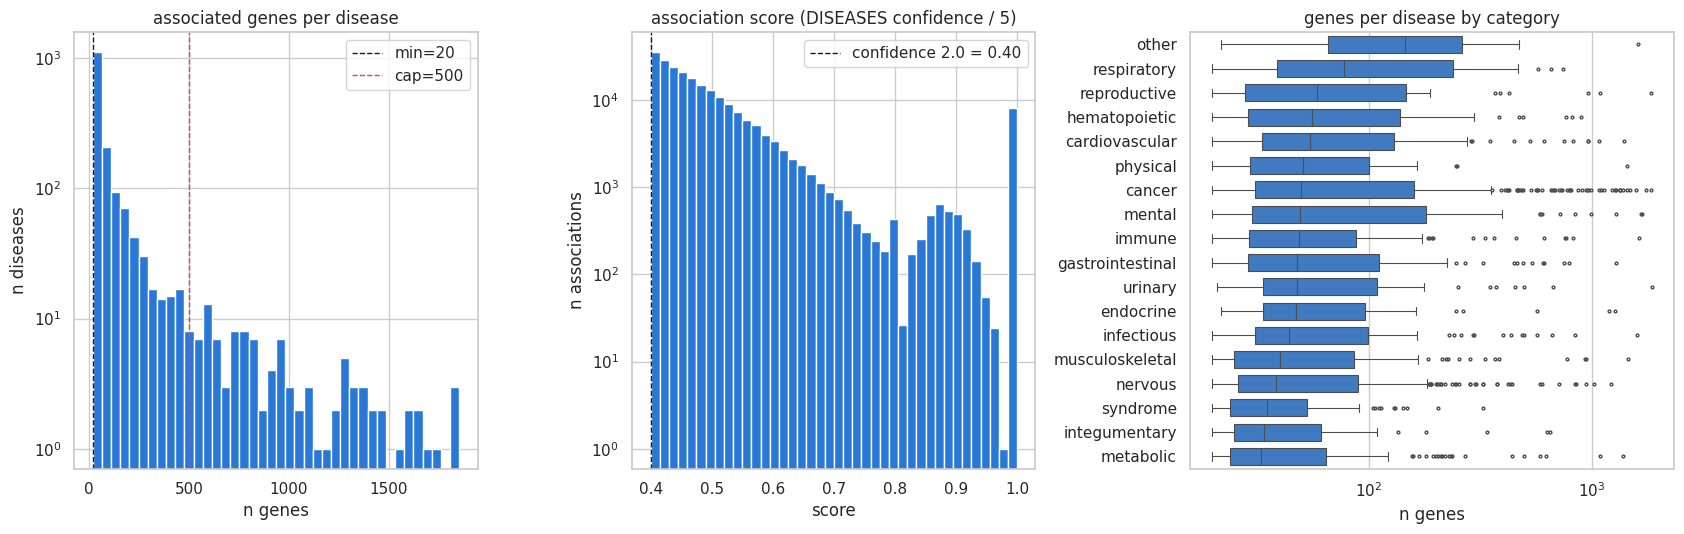

Largest and smallest disease gene sets:

                               disease_label        category  n_genes  median_score
                              kidney disease         urinary     1851        0.4792
          female reproductive system disease    reproductive     1840        0.4699
                      endocrine gland cancer          cancer     1826        0.4640
                                 lung cancer          cancer     1741        0.4658
     developmental disorder of mental health          mental     1676        0.4662
                          cognitive disorder          mental     1660        0.4709
autoimmune disease of musculoskeletal system          immune     1624        0.4944
                 autosomal recessive disease           other     1606        0.4839
               xeroderma pigmentosum group A        syndrome       20        0.4400
            craniolenticulosutural dysplasia        syndrome       20        0.5132
    melanoma in congenital melanocy

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
CATEGORY_PALETTE = category_palette(gdas["category"])

per_disease = (
    gdas.groupby(["cui", "disease_label", "category"])
        .agg(n_genes=("gene_symbol", "nunique"),
             median_score=("score", "median"),
             max_score=("score", "max"))
        .reset_index()
        .sort_values("n_genes", ascending=False)
)

fig, ax = plt.subplots(1, 3, figsize=(17, 5.5), gridspec_kw=dict(width_ratios=[1, 1, 1.2]))
ax[0].hist(per_disease["n_genes"], bins=40, color=SINGLE_HUE)
ax[0].axvline(MIN_GENES_PER_DISEASE, color="k", ls="--", lw=1, label=f"min={MIN_GENES_PER_DISEASE}")
ax[0].axvline(MAX_GENES_PER_DISEASE, color="#d1495b", ls="--", lw=1, label=f"cap={MAX_GENES_PER_DISEASE}")
ax[0].set(title="associated genes per disease", xlabel="n genes", ylabel="n diseases")
ax[0].set_yscale("log"); ax[0].legend()

ax[1].hist(gdas["score"].dropna(), bins=40, color=SINGLE_HUE)
floor = DISEASES_MIN_CONF / DISEASES_CONF_MAX
ax[1].axvline(floor, color="k", ls="--", lw=1, label=f"confidence {DISEASES_MIN_CONF} = {floor:.2f}")
ax[1].set(title="association score (DISEASES confidence / 5)", xlabel="score",
          ylabel="n associations")
ax[1].set_yscale("log"); ax[1].legend()

# 18 categories is more identities than colour can carry, so the category goes on the axis and every
# box shares one hue. Horizontal, because the category names are words.
cat_order = per_disease.groupby("category")["n_genes"].median().sort_values(ascending=False).index
sns.boxplot(data=per_disease, y="category", x="n_genes", order=cat_order, ax=ax[2],
            color=SINGLE_HUE, linewidth=0.8, fliersize=2, width=0.7)
ax[2].set(xscale="log", title="genes per disease by category", xlabel="n genes", ylabel="")
plt.tight_layout(); plt.show()

print("Largest and smallest disease gene sets:\n")
print(pd.concat([per_disease.head(8), per_disease.tail(8)])
      [["disease_label", "category", "n_genes", "median_score"]].to_string(index=False))

In [7]:
# How much of the atlas survives at each stringency? Only cutoffs at or above the floor already
# applied when the table was built can be explored from the cache — going below needs REFRESH_SEEDS.
rows = []
for conf in sorted({DISEASES_MIN_CONF, 2.5, 3.0, 3.5}):
    cutoff = conf / DISEASES_CONF_MAX
    sub = gdas[gdas["score"] >= cutoff]
    counts = sub.groupby("cui")["gene_symbol"].nunique()
    usable = counts[counts >= MIN_GENES_PER_DISEASE]
    rows.append(dict(confidence=conf, score=round(cutoff, 2), associations=len(sub),
                     diseases=counts.size, usable_diseases=usable.size,
                     median_genes=int(counts.median()) if counts.size else 0,
                     max_genes=int(counts.max()) if counts.size else 0))
print(pd.DataFrame(rows).to_string(index=False))
print(f"\nfloor applied when the table was built: confidence >= {DISEASES_MIN_CONF} "
      f"(score {DISEASES_MIN_CONF / DISEASES_CONF_MAX:.2f})")

 confidence  score  associations  diseases  usable_diseases  median_genes  max_genes
        2.0    0.4        225372      1730             1730            44       1851
        2.5    0.5         74085      1728              670            14        766
        3.0    0.6         26366      1561              300             5        521
        3.5    0.7         14083      1185              174             3        502

floor applied when the table was built: confidence >= 2.0 (score 0.40)


## 4 — Gene filtering and identifier mapping

Three things happen here, in order:

1. **Protein-coding only** — required by construction: a node must have a protein sequence for its
   ESM-2 embedding and a STRING entry for its edges. `mygene` maps NCBI gene IDs → Ensembl gene ID +
   symbol + biotype in one query.
2. **Evidence cutoff** — `score >= SEED_MIN_SCORE`, on top of the DISEASES confidence floor
   already applied when the seed table was built.
3. **Size cap** — the top `MAX_GENES_PER_DISEASE` genes by association score, so that graph size does
   not become the dominant axis of variation for the graph-level SAE.

Every step reports what it removed.

In [8]:
import mygene

# mygene is a live service and its 1:many resolution is not reproducible: the same ~11,000 symbols
# queried twice came back with three different Ensembl gene IDs. That silently rewrites the ESM gene
# list, and `load_esm_embeddings` fills anything missing from the embedding file with a *random*
# vector — so re-running this cell could quietly decorrelate a handful of nodes from their protein
# identity, with nothing but section 8's `esm_coverage` to show it.
#
# The mygene answer is therefore cached in MYGENE_FILE and only ever *extended*: whatever a gene
# resolved to the first time is what it keeps. Failures are cached too — a retired symbol like
# `ACPP` or `ATP5MD` that mygene cannot place must stay unplaced, or it would slip into the atlas
# the day the service starts resolving it and move the gene list again.
REFRESH_GENE_MAP = False   # True re-queries mygene for every gene, discarding the cached mapping
GENE_MAP_COLS = ["gene_ncbi_id", "gene_symbol", "gene_ensembl", "symbol", "ensembl_id", "biotype"]

gene_keys = (
    gdas[["gene_ncbi_id", "gene_symbol", "gene_ensembl"]]
    .drop_duplicates(subset=["gene_symbol"])
    .reset_index(drop=True)
)
has_ncbi = gene_keys["gene_ncbi_id"].notna().mean()
use_ncbi = has_ncbi > 0.5          # query by NCBI gene ID when available (unambiguous), else symbol
print(f"{len(gene_keys):,} distinct genes | NCBI ID present for {has_ncbi:.0%}")


def _first_ensembl(row):
    # mygene returns either 'ensembl.gene' (1:1) or 'ensembl' (a list of dicts, 1:many). In the
    # 1:many case take the lowest ENSG rather than whichever came back first: the response order is
    # not stable between calls, and an unstable choice here is an unstable ESM gene list.
    val = row.get("ensembl.gene")
    if isinstance(val, str):
        return val
    ens = row.get("ensembl")
    if isinstance(ens, list) and ens:
        return min((g.get("gene") for g in ens if g.get("gene")), default=None)
    if isinstance(ens, dict):
        return ens.get("gene")
    return None


def query_mygene(keys):
    """gene_symbol → symbol / ensembl_id / biotype for the rows of `keys`, straight from mygene."""
    if not len(keys):
        return pd.DataFrame(columns=GENE_MAP_COLS)
    mg = mygene.MyGeneInfo()
    query_ids = (keys["gene_ncbi_id"] if use_ncbi else keys["gene_symbol"]).dropna().astype(str)
    info = mg.querymany(
        query_ids.tolist(),
        scopes="entrezgene" if use_ncbi else "symbol",
        fields="symbol,ensembl.gene,type_of_gene",
        species="human", as_dataframe=True, verbose=False,
    )
    info = info[~info.index.duplicated(keep="first")]
    info["ensembl_id"] = info.apply(_first_ensembl, axis=1)
    info["biotype"] = info.get("type_of_gene", pd.Series(index=info.index, dtype=object))

    out = keys.copy()
    out["_key"] = (out["gene_ncbi_id"] if use_ncbi else out["gene_symbol"]).astype(str)
    out = out.join(info[["symbol", "ensembl_id", "biotype"]], on="_key")
    out["symbol"] = out["symbol"].fillna(out["gene_symbol"])
    return out.reindex(columns=GENE_MAP_COLS)


def load_cached_mygene():
    # MYGENE_FILE is this cell's own cache and holds every answer, resolved or not. Falling back to
    # GENEMAP_FILE lets an atlas built before this cache existed keep its mapping instead of being
    # re-queried — it only stores the genes that resolved, so the failures are re-asked once.
    for path in (MYGENE_FILE, GENEMAP_FILE):
        if path.exists():
            print(f"(cache) reading the gene mapping from {path.name}")
            return pd.read_csv(path, sep="\t", dtype={"gene_ncbi_id": str}).reindex(
                columns=GENE_MAP_COLS)
    return None


cached = None if REFRESH_GENE_MAP else load_cached_mygene()
if cached is None:
    raw_map = query_mygene(gene_keys)
    print(f"queried mygene for all {len(gene_keys):,} genes")
else:
    fresh = gene_keys[~gene_keys["gene_symbol"].isin(cached["gene_symbol"])]
    print(f"   {gene_keys['gene_symbol'].isin(cached['gene_symbol']).sum():,} of "
          f"{len(gene_keys):,} genes already mapped"
          + (f"; querying mygene for the remaining {len(fresh):,}" if len(fresh)
             else " — nothing left to query"))
    raw_map = pd.concat([cached, query_mygene(fresh)], ignore_index=True)

# Written back including the unresolved rows, so the next run asks mygene nothing at all.
raw_map = raw_map.drop_duplicates(subset=["gene_symbol"]).reset_index(drop=True)
raw_map.to_csv(MYGENE_FILE, sep="\t", index=False)
print(f"gene mapping cached: {len(raw_map):,} genes "
      f"({raw_map['ensembl_id'].notna().sum():,} resolved) → {MYGENE_FILE.name}")

gene_map = raw_map[raw_map["gene_symbol"].isin(gene_keys["gene_symbol"])]
n_before = len(gene_map)
gene_map = gene_map[gene_map["biotype"].astype(str).str.contains("protein", case=False, na=False)]
gene_map = gene_map[gene_map["ensembl_id"].notna()].drop_duplicates(subset=["gene_symbol"]).copy()
print(f"Protein-coding with an Ensembl gene ID: {n_before:,} → {len(gene_map):,} genes")

11,198 distinct genes | NCBI ID present for 0%
(cache) reading the gene mapping from mygene_map_diseases-all.tsv
   11,198 of 11,198 genes already mapped — nothing left to query
gene mapping cached: 11,198 genes (10,997 resolved) → mygene_map_diseases-all.tsv
Protein-coding with an Ensembl gene ID: 11,198 → 10,982 genes


In [9]:
# Apply the evidence cutoff + size cap, then drop diseases that end up too small.
flt = gdas[gdas["score"] >= SEED_MIN_SCORE].copy()
print(f"score >= {SEED_MIN_SCORE}: {len(gdas):,} → {len(flt):,} associations")

flt = flt.merge(gene_map[["gene_symbol", "symbol", "ensembl_id"]], on="gene_symbol", how="inner")
print(f"protein-coding + mappable:   → {len(flt):,} associations")

flt = (flt.sort_values("score", ascending=False)
          .drop_duplicates(subset=["cui", "ensembl_id"])
          .groupby("cui", group_keys=False)
          .head(MAX_GENES_PER_DISEASE))
print(f"top-{MAX_GENES_PER_DISEASE} per disease:    → {len(flt):,} associations")

sizes = flt.groupby("cui")["ensembl_id"].nunique()
too_small = sizes[sizes < MIN_GENES_PER_DISEASE]
flt = flt[~flt["cui"].isin(too_small.index)]
if len(too_small):
    dropped = (per_disease.set_index("cui").loc[too_small.index, "disease_label"]
               + " (" + too_small.astype(str) + ")").tolist()
    print(f"\nDropped {len(too_small)} diseases with < {MIN_GENES_PER_DISEASE} usable genes"
          + (f", e.g.\n   {'; '.join(dropped[:10])}" if len(dropped) > 10
             else ":\n   " + "; ".join(dropped)))

print(f"\nSeed sets ready: {flt['cui'].nunique()} diseases, "
      f"{flt['ensembl_id'].nunique():,} distinct genes, {len(flt):,} associations")
print(flt.groupby("cui")["ensembl_id"].nunique().describe().round(1).to_string())

score >= 0.3: 225,372 → 225,372 associations
protein-coding + mappable:   → 223,035 associations
top-500 per disease:    → 177,105 associations

Dropped 19 diseases with < 20 usable genes, e.g.
   polycystic liver disease (19); episodic ataxia type 2 (19); benign recurrent intrahepatic cholestasis (18); PAPA syndrome (19); semantic dementia (19); asphyxiating thoracic dystrophy 3 (18); short-rib thoracic dysplasia 6 with or without polydactyly (19); hereditary spastic paraplegia 2 (19); McKusick-Kaufman syndrome (19); amelogenesis imperfecta type 3 (16)

Seed sets ready: 1711 diseases, 10,249 distinct genes, 176,750 associations
count    1711.0
mean      103.3
std       132.3
min        20.0
25%        28.0
50%        45.0
75%       107.0
max       500.0


## 5 — The STRING backbone

One global interaction network, downloaded once (~160 MB, cached in `data/disgenet/string/`), from
which every disease graph is cut. We use the **detailed** links file rather than the REST API for two
reasons: it is reproducible (a fixed release), and it keeps the individual evidence channels
(`experimental`, `database`, `coexpression`, `textmining`, …) that the edge-level SAE may want later.

Edges are kept at `combined_score >= 700` (STRING's "high confidence"). The weight stored on the edge
is $w_{ij} = s_{ij}/1000 \in (0, 1]$ — never a binary adjacency, so the edge SAE can distinguish
"these proteins interact" from "these proteins interact with strong experimental support".

In [10]:
STRING_FILES = {
    "links":   f"protein.links.detailed.v{STRING_VERSION}/{SPECIES}.protein.links.detailed.v{STRING_VERSION}.txt.gz",
    "info":    f"protein.info.v{STRING_VERSION}/{SPECIES}.protein.info.v{STRING_VERSION}.txt.gz",
    "aliases": f"protein.aliases.v{STRING_VERSION}/{SPECIES}.protein.aliases.v{STRING_VERSION}.txt.gz",
}
STRING_BASE_URL = "https://stringdb-downloads.org/download"


def fetch_string_file(kind):
    remote = STRING_FILES[kind]
    return download_file(f"{STRING_BASE_URL}/{remote}", STRING_DIR / Path(remote).name)


links_path   = fetch_string_file("links")
info_path    = fetch_string_file("info")
aliases_path = fetch_string_file("aliases")

(cached) 9606.protein.links.detailed.v12.0.txt.gz  140 MB
(cached) 9606.protein.info.v12.0.txt.gz  2 MB
(cached) 9606.protein.aliases.v12.0.txt.gz  20 MB


In [11]:
# ── Identifier bridges: Ensembl gene ID / symbol → STRING protein ID ─────────
aliases = pd.read_csv(aliases_path, sep="\t", names=["string_id", "alias", "source"],
                      skiprows=1, dtype=str)
info = pd.read_csv(info_path, sep="\t", dtype=str).rename(
    columns={"#string_protein_id": "string_id"})

# Primary bridge: STRING's own Ensembl_gene alias (ENSG → ENSP), one row per protein.
ensg = (aliases[aliases["source"] == "Ensembl_gene"]
        .drop_duplicates(subset="alias")
        .set_index("alias")["string_id"])
# Secondary bridge: preferred name (HGNC symbol) for genes whose ENSG is not listed.
sym = info.drop_duplicates(subset="preferred_name").set_index("preferred_name")["string_id"]

print(f"STRING v{STRING_VERSION}: {info['string_id'].nunique():,} human proteins | "
      f"{len(ensg):,} Ensembl-gene aliases | {len(sym):,} preferred names")

gene_map["string_id"] = gene_map["ensembl_id"].map(ensg)
fallback = gene_map["string_id"].isna()
gene_map.loc[fallback, "string_id"] = gene_map.loc[fallback, "symbol"].map(sym)

mapped = gene_map["string_id"].notna()
print(f"\nGene → STRING protein: {mapped.sum():,}/{len(gene_map):,} ({mapped.mean():.1%}) "
      f"[{(~fallback & mapped).sum():,} via Ensembl, {(fallback & mapped).sum():,} via symbol]")
gene_map = gene_map[mapped].copy()

# A STRING protein may be reachable from more than one gene ID; keep one gene per protein.
gene_map = gene_map.drop_duplicates(subset="string_id")
gene_map.to_csv(GENEMAP_FILE, sep="\t", index=False)
gene_map[["gene_symbol", "symbol", "ensembl_id", "string_id"]].head()

STRING v12.0: 19,699 human proteins | 19,699 Ensembl-gene aliases | 19,699 preferred names

Gene → STRING protein: 10,982/10,982 (100.0%) [10,541 via Ensembl, 441 via symbol]


,gene_symbol,symbol,ensembl_id,string_id
0,M6PR,M6PR,ENSG00000003056,9606.ENSP00000000412
1,FKBP4,FKBP4,ENSG00000004478,9606.ENSP00000001008
2,CYP26B1,CYP26B1,ENSG00000003137,9606.ENSP00000001146
3,NDUFAF7,NDUFAF7,ENSG00000003509,9606.ENSP00000002125
4,FUCA2,FUCA2,ENSG00000001036,9606.ENSP00000002165


In [12]:
# Per-disease mapping QC — which diseases lose the most genes on the way to STRING?
seeds = flt.merge(gene_map[["ensembl_id", "string_id", "symbol"]], on="ensembl_id", how="left")
mapping_qc = (
    seeds.groupby(["cui", "disease_label", "category"])
         .agg(n_genes=("ensembl_id", "nunique"),
              n_mapped=("string_id", lambda s: s.notna().sum()))
         .reset_index()
)
mapping_qc["frac_mapped"] = mapping_qc["n_mapped"] / mapping_qc["n_genes"]
print(f"Median mapping rate across diseases: {mapping_qc['frac_mapped'].median():.1%}")
print("\nWorst-mapped diseases:")
print(mapping_qc.nsmallest(5, "frac_mapped")[
    ["disease_label", "n_genes", "n_mapped", "frac_mapped"]].to_string(index=False))

# Drop unmapped genes and collapse duplicate (disease, protein) rows, keeping the best evidence.
seeds = (seeds[seeds["string_id"].notna()]
         .sort_values("score", ascending=False)
         .drop_duplicates(subset=["cui", "string_id"])
         .reset_index(drop=True))
print(f"\nSeed table: {len(seeds):,} (disease, protein) pairs | "
      f"{seeds['string_id'].nunique():,} distinct proteins")

Median mapping rate across diseases: 100.0%

Worst-mapped diseases:
             disease_label  n_genes  n_mapped  frac_mapped
              angiosarcoma       58        58          1.0
          bacterial sepsis       35        35          1.0
        autoimmune uveitis       30        30          1.0
               chikungunya       33        33          1.0
mineral metabolism disease      219       219          1.0

Seed table: 176,750 (disease, protein) pairs | 10,249 distinct proteins


In [13]:
# ── Load the interaction network, restricted to the atlas' protein universe ──
protein_universe = set(seeds["string_id"].unique())
USE_COLS = ["protein1", "protein2", "experimental", "database", "combined_score"]

kept = []
reader = pd.read_csv(links_path, sep=" ", usecols=USE_COLS, chunksize=2_000_000)
for chunk in tqdm(reader, desc="Scanning STRING links"):
    chunk = chunk[chunk["combined_score"] >= STRING_MIN_SCORE]
    chunk = chunk[chunk["protein1"].isin(protein_universe) & chunk["protein2"].isin(protein_universe)]
    kept.append(chunk[chunk["protein1"] < chunk["protein2"]])   # each pair is listed twice; keep one

links = pd.concat(kept, ignore_index=True)
del kept
links["weight"] = links["combined_score"] / 1000.0
links["physical"] = (links[PHYSICAL_CHANNELS] > 0).any(axis=1)

print(f"\n{len(links):,} unique interactions at combined_score >= {STRING_MIN_SCORE} "
      f"among {len(protein_universe):,} proteins")
print(f"  experimental/database supported: {links['physical'].mean():.1%}")
print(f"  weight: median {links['weight'].median():.3f}, mean {links['weight'].mean():.3f}")

Scanning STRING links: 0it [00:00, ?it/s]


130,825 unique interactions at combined_score >= 700 among 10,249 proteins
  experimental/database supported: 77.4%
  weight: median 0.856, mean 0.857


## 6 — ESM-2 node features

Protein identity is supplied by ESM-2, exactly as in the IBD and T2D tutorials: the embeddings are
computed **once** for the whole protein universe and every disease graph then slices the rows it
needs. This is what makes variable node sets defensible — two graphs sharing no genes are still
comparable, because their nodes live in the same protein representation space.

Run once (GPU recommended), from the repository root:

```bash
python3 docs/scripts/get_esm_embeddings.py \
    --gene-list docs/tutorial/data/disgenet/ensembl_ids_diseases-all.txt \
    --out       docs/tutorial/data/disgenet/esm_embeddings_diseases-all.pt \
    --species   human \
    --model     facebook/esm2_t33_650M_UR50D \
    --batch-size 16
```

**The gene list has to match the atlas.** `load_esm_embeddings` gives any gene missing from the file
a *random* vector, silently — so if you rebuild Part 1 with different filters, re-run the script on the
new `ensembl_ids_diseases-all.txt` before reading anything into the node level. Section 8 reports
`esm_coverage` per graph precisely so this cannot go unnoticed; it should be 1.000 everywhere.

**One consensus file, assembled from whatever exists.** In practice the embeddings for one atlas end
up spread over more than one file: the run for this atlas, a top-up run for the genes a previous pass
missed, and `esm_embeddings_diseases.pt` from the 90-disease atlas, which still covers most of this
one. The cell below merges every file in `ESM_SOURCES` — priority order, first file to supply a gene
owns it — into `esm_embeddings_diseases-all_consensus.pt`, keeping only the ~10,000 proteins this
atlas actually needs, and refuses to merge files whose `hidden_dim` disagrees, since that would mean
two different ESM-2 models. Whatever is still uncovered goes to `ensembl_ids_diseases-all_missing.txt`,
which is the gene list for the next top-up run:

```bash
python3 docs/scripts/get_esm_embeddings.py \
    --gene-list docs/tutorial/data/disgenet/ensembl_ids_diseases-all_missing.txt \
    --out       docs/tutorial/data/disgenet/esm_embeddings_diseases-all_topup.pt \
    --species   human \
    --model     facebook/esm2_t33_650M_UR50D \
    --batch-size 16
```

Add that output to `ESM_SOURCES` and re-run the cell; coverage should reach 100% and the missing-gene
file is deleted when it does. So a widened universe costs a run over the *new* genes only, never over
all of them.

**Why the gene list moves at all.** Section 4's gene → Ensembl mapping comes from mygene, a live
service whose 1:many resolution is not reproducible — the same symbol set queried twice returned
three different ENSGs out of ~10,000. Section 4 therefore caches `gene_protein_map_*.tsv` and only
ever *extends* it, so the protein universe is stable across re-runs and an existing embedding file
stays valid. Set `REFRESH_GENE_MAP = True` only if you want the mapping recomputed from scratch, and
expect to top up the embeddings afterwards.

If the file is absent the notebook still builds the atlas, using the association-evidence vector alone as
node features, and says so — Part 2 (GCN with an ESM-reconstruction objective) requires the real
embeddings.

In [14]:
from gea.utils import compress_embeddings_pca, load_esm_embeddings

# Global protein table — this row order defines node indices everywhere downstream.
proteins = (gene_map[gene_map["string_id"].isin(protein_universe)]
            [["string_id", "ensembl_id", "symbol"]]
            .drop_duplicates(subset="string_id")
            .sort_values("string_id")
            .reset_index(drop=True))
p_index = pd.Series(proteins.index.values, index=proteins["string_id"])
print(f"Protein universe: {len(proteins):,} proteins")

ENSEMBL_FILE.write_text("\n".join(proteins["ensembl_id"].tolist()))
print(f"Gene list for the ESM script → {ENSEMBL_FILE}")

def build_esm_consensus(needed, sources=ESM_SOURCES, out=ESM_CONSENSUS_FILE,
                        missing_out=ESM_MISSING_FILE):
    """Merge every ESM-2 file that exists into one covering this atlas, and name what is missing.

    Each file is {ensembl_id: {transcript_id: tensor([hidden_dim])}}. `sources` is a priority order:
    the first file to supply a gene owns it, and a gene held by several keeps the earlier file's
    tensor for a transcript they share while gaining any transcript the later ones add. Only genes
    this atlas needs are carried over, so the consensus never grows past the protein universe.
    """
    available = [Path(p) for p in sources if Path(p).exists()]
    needed_set, merged, source_of, dims = set(needed), {}, {}, set()

    for path in available:
        blob = torch.load(path, weights_only=False)
        added = 0
        for gene, isoforms in blob.items():
            if gene not in needed_set:
                continue
            dims.update(t.shape[0] for t in isoforms.values())
            if gene in merged:
                for tid, tensor in isoforms.items():
                    merged[gene].setdefault(tid, tensor)
            else:
                merged[gene], source_of[gene], added = dict(isoforms), path.name, added + 1
        print(f"   {path.name}: {len(blob):,} genes stored, {added:,} new here "
              f"→ {len(merged):,}/{len(needed):,} covered")
    if len(dims) > 1:
        raise ValueError(f"the ESM files disagree on hidden_dim {sorted(dims)} — they come from "
                         f"different ESM-2 models and must not be merged")

    missing = [g for g in needed if g not in merged]
    if missing:
        missing_out.write_text("\n".join(missing))
        print(f"!! {len(missing):,} of {len(needed):,} genes have no embedding → "
              f"{missing_out.name}\n"
              f"   top them up with get_esm_embeddings.py --gene-list {missing_out.name}, add the "
              f"output to ESM_SOURCES, re-run this cell.\n"
              f"   Until then those nodes carry a random vector and section 8's esm_coverage "
              f"reports it.")
    elif missing_out.exists():
        missing_out.unlink()

    if not merged:
        print("   no ESM-2 embeddings found for any gene in this atlas")
        return None
    torch.save(merged, out)
    print(f"consensus: {len(merged):,}/{len(needed):,} genes ({len(merged) / len(needed):.2%}), "
          f"dim {dims.pop()} → {out.name}")
    print("   contributed by: " + ", ".join(
        f"{name} ({n:,})" for name, n in pd.Series(source_of).value_counts().items()))
    return out


esm_source = (build_esm_consensus(proteins["ensembl_id"].tolist()) if BUILD_ESM_CONSENSUS
              else (ESM_FILE if ESM_FILE.exists() else None))

esm_matrix, esm_available, esm_present = None, False, set()
if esm_source is not None:
    set_seed(SEED)   # load_esm_embeddings draws a random vector for any gene missing from the file
    try:    # metadata-only read: we only need the key set for the coverage QC
        esm_present = set(torch.load(esm_source, weights_only=False, map_location="meta"))
    except Exception:                                   # noqa: BLE001
        esm_present = set(torch.load(esm_source, weights_only=False))
    esm_matrix = load_esm_embeddings(str(esm_source), proteins["ensembl_id"].tolist(),
                                     aggregation="mean")
    esm_matrix = compress_embeddings_pca(esm_matrix, n_components=ESM_PCA_DIM, whiten=True)
    esm_available = True
    print(f"ESM-2 node features: {tuple(esm_matrix.shape)}")
else:
    print(f"!! no ESM-2 embeddings for this atlas — building graphs with association-evidence\n"
          f"   features only. Run the command above, then re-run this cell and section 7.")

Protein universe: 10,249 proteins
Gene list for the ESM script → data/disgenet/ensembl_ids_diseases-all.txt
   esm_embeddings_diseases-all.pt: 10,245 genes stored, 10,243 new here → 10,243/10,249 covered
   esm_embeddings_diseases.pt: 6,638 genes stored, 3 new here → 10,246/10,249 covered
!! 3 of 10,249 genes have no embedding → ensembl_ids_diseases-all_missing.txt
   top them up with get_esm_embeddings.py --gene-list ensembl_ids_diseases-all_missing.txt, add the output to ESM_SOURCES, re-run this cell.
   Until then those nodes carry a random vector and section 8's esm_coverage reports it.
consensus: 10,246/10,249 genes (99.97%), dim 1280 → esm_embeddings_diseases-all_consensus.pt
   contributed by: esm_embeddings_diseases-all.pt (10,243), esm_embeddings_diseases.pt (3)


Loading ESM-2 embeddings: 100%|██████████| 10249/10249 [00:00<00:00, 29786.51it/s]


Found ESM-2 embeddings for 10246/10249 genes.
PCA: 1280→256 dims, 91.1% variance retained.
ESM-2 node features: (10249, 256)


## 7 — Graph construction

For each disease $d$:

$$V_d = \{\text{mapped protein-coding DISEASES genes}\},\qquad
  E_d = \{(u,v) \in E_{\text{STRING}} : u,v \in V_d\}$$

i.e. the **induced subgraph** — no 1-hop expansion in this baseline. Isolated nodes (no
high-confidence partner inside the disease gene set) are dropped by default, since they contribute no
message passing, and the fraction dropped is recorded per disease.

Node features carry two blocks by default. An optional **structural** block (degree, weighted
strength, relative degree, clustering, k-core, PageRank, fraction of experimentally supported edges,
standardised across the atlas) can be switched on in section 0 — it is off here, because those
descriptors are computed on the complete graph and therefore tell the masked-edge objective how many
edges each node really has. With it off, the only thing distinguishing a protein between two
diseases is the company it keeps, and message passing has to do that work.

Each `Data` object follows the layout the GEA models already expect:

| field | content |
|---|---|
| `x` | `[disease-association score ‖ ESM-2 PCA]` — the first plays the role `expression` plays in the LIONESS graphs, the second is protein identity. An optional structural block sits between them (`STRUCTURAL_FEATURES`), off by default: it leaks into the masked-edge objective |
| `n_struct` | width of the structural block, so Part 2 knows where the identity block starts |
| `node_evidence` | association evidence per node: `score, ei, dsi, dpi, log1p(n_pmids)` — DISEASES populates only `score`; the other four are zero placeholders kept for schema stability |
| `edge_index`, `edge_attr` | both directions; weight $= s_{ij}/1000$ |
| `edge_type` | `0` = experimental/database supported, `1` = inferred channels only (the two R-GCN relations) |
| `y`, `y_dis` | disease **category** and disease identity, integer-encoded |
| `gene_symbols`, `ensembl_ids`, `string_ids` | node identity, for enrichment and plotting |

In [15]:
import networkx as nx
from torch_geometric.data import Data

# Edge arrays in global protein-index space — membership tests then become O(1) per edge.
E1 = links["protein1"].map(p_index).to_numpy()
E2 = links["protein2"].map(p_index).to_numpy()
EW = links["weight"].to_numpy(dtype=np.float32)
EP = links["physical"].to_numpy()

EVIDENCE_COLS = ["score", "ei", "dsi", "dpi", "log1p_pmids"]
seeds["log1p_pmids"] = np.log1p(pd.to_numeric(seeds.get("n_pmids"), errors="coerce").fillna(0))
for col in ["ei", "dsi", "dpi"]:
    seeds[col] = pd.to_numeric(seeds[col], errors="coerce").fillna(0.0)

categories = sorted(seeds["category"].unique())
cat_map = {c: i for i, c in enumerate(categories)}
disease_names = sorted(seeds["disease_label"].unique())
dis_map = {d: i for i, d in enumerate(disease_names)}


def structural_features(ia, ib, w, phys, n_nodes):
    # Per-graph topology descriptors, computed on the disease subgraph itself. Everything here is
    # cheap on graphs of a few hundred nodes; betweenness is deliberately left out (O(nm)).
    g = nx.Graph()
    g.add_nodes_from(range(n_nodes))
    g.add_weighted_edges_from(zip(ia.tolist(), ib.tolist(), w.tolist()))

    deg = np.array([g.degree(i) for i in range(n_nodes)], dtype=np.float32)
    strength = np.array([g.degree(i, weight="weight") for i in range(n_nodes)], dtype=np.float32)
    clustering = np.array([v for _, v in sorted(nx.clustering(g, weight="weight").items())],
                          dtype=np.float32)
    core = np.array([v for _, v in sorted(nx.core_number(g).items())], dtype=np.float32)
    pagerank = np.array([v for _, v in sorted(nx.pagerank(g, weight="weight").items())],
                        dtype=np.float32)

    # Fraction of a node's edges that are experimentally or database supported rather than inferred.
    phys_sum = np.zeros(n_nodes, dtype=np.float32)
    np.add.at(phys_sum, ia, phys.astype(np.float32))
    np.add.at(phys_sum, ib, phys.astype(np.float32))
    frac_phys = phys_sum / np.maximum(deg, 1)

    return np.stack([
        np.log1p(deg),
        np.log1p(strength),
        deg / max(n_nodes - 1, 1),
        clustering,
        core,
        np.log1p(pagerank * n_nodes),
        frac_phys,
    ], axis=1).astype(np.float32)


def build_disease_graph(sub):
    # sub: the seed rows of one disease, one row per (disease, protein)
    nodes = np.sort(sub["p_idx"].to_numpy())
    member = np.zeros(len(proteins), dtype=bool)
    member[nodes] = True

    sel = member[E1] & member[E2]
    a, b, w, phys = E1[sel], E2[sel], EW[sel], EP[sel]

    if DROP_ISOLATED_NODES:
        connected = np.unique(np.concatenate([a, b])) if len(a) else np.array([], dtype=int)
        nodes = connected
    if KEEP_LARGEST_CC and len(nodes):
        import scipy.sparse as sp
        from scipy.sparse.csgraph import connected_components
        loc = -np.ones(len(proteins), dtype=np.int64); loc[nodes] = np.arange(len(nodes))
        adj = sp.coo_matrix((np.ones(len(a)), (loc[a], loc[b])), shape=(len(nodes),) * 2)
        n_cc, lab = connected_components(adj, directed=False)
        keep = lab == np.bincount(lab).argmax()
        nodes = nodes[keep]
        member = np.zeros(len(proteins), dtype=bool); member[nodes] = True
        sel2 = member[a] & member[b]
        a, b, w, phys = a[sel2], b[sel2], w[sel2], phys[sel2]

    if len(nodes) < MIN_NODES or len(a) < MIN_EDGES:
        return None, dict(n_nodes=len(nodes), n_edges=len(a), dropped=True)

    local = -np.ones(len(proteins), dtype=np.int64)
    local[nodes] = np.arange(len(nodes))
    ia, ib = local[a], local[b]

    # Node-aligned evidence, in the same order as `nodes`
    ev = (sub.set_index("p_idx").loc[nodes, EVIDENCE_COLS]
             .astype(np.float32).to_numpy())
    evidence = torch.from_numpy(ev)

    struct = (torch.from_numpy(structural_features(ia, ib, w, phys, len(nodes)))
              if STRUCTURAL_FEATURES else torch.zeros(len(nodes), 0))

    blocks = [evidence[:, :1], struct]
    if esm_available:
        blocks.append(esm_matrix[nodes])
    elif not STRUCTURAL_FEATURES:
        blocks = [evidence]                       # nothing else to offer the model
    else:
        blocks.append(evidence[:, 1:])
    x = torch.cat(blocks, dim=1)

    edge_index = torch.tensor(np.stack([np.concatenate([ia, ib]),
                                        np.concatenate([ib, ia])]), dtype=torch.long)
    edge_attr = torch.tensor(np.concatenate([w, w]), dtype=torch.float32)
    edge_type = torch.tensor(np.concatenate([~phys, ~phys]).astype(np.int64), dtype=torch.long)

    row = sub.iloc[0]
    data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr)
    data.edge_type = edge_type
    data.node_evidence = evidence
    data.y = torch.tensor(cat_map[row["category"]], dtype=torch.long)
    data.y_dis = torch.tensor(dis_map[row["disease_label"]], dtype=torch.long)
    data.disease = row["disease_label"]
    data.category = row["category"]
    data.cui = row["cui"]
    data.sample_name = row["disease_label"]          # GEA annotation helpers key on this
    data.gene_symbols = proteins.loc[nodes, "symbol"].tolist()
    data.ensembl_ids = proteins.loc[nodes, "ensembl_id"].tolist()
    data.string_ids = proteins.loc[nodes, "string_id"].tolist()
    data.n_seed_genes = int(len(sub))
    data.n_struct = int(struct.shape[1])

    stats = dict(n_nodes=len(nodes), n_edges=len(a), dropped=False)
    return data, stats

In [16]:
seeds["p_idx"] = seeds["string_id"].map(p_index).astype(int)

graphs, build_log = [], []
for (cui, label, category), sub in tqdm(seeds.groupby(["cui", "disease_label", "category"]),
                                        desc="Building disease graphs"):
    data, stats = build_disease_graph(sub)
    isolated = 1 - stats["n_nodes"] / sub["p_idx"].nunique()
    build_log.append(dict(cui=cui, disease=label, category=category,
                          n_seed_genes=sub["p_idx"].nunique(), frac_isolated=isolated, **stats))
    if data is not None:
        graphs.append(data)

build_log = pd.DataFrame(build_log)
dropped = build_log[build_log["dropped"]]
print(f"\nBuilt {len(graphs)} disease graphs "
      f"({len(dropped)} dropped for < {MIN_NODES} nodes / < {MIN_EDGES} edges)")
if len(dropped):
    print(dropped.nlargest(10, "n_seed_genes")[
        ["disease", "n_seed_genes", "n_nodes", "n_edges"]].to_string(index=False))
    if len(dropped) > 10:
        print(f"   … and {len(dropped) - 10} more")
# Standardise the structural block across the whole atlas, so that "hub" is comparable between a
# 200-node graph and a 1000-node one. Done after the loop because it needs every graph's values.
N_STRUCT = int(graphs[0].n_struct) if graphs else 0
if N_STRUCT:
    block = torch.cat([g.x[:, 1:1 + N_STRUCT] for g in graphs])
    mu, sd = block.mean(0), block.std(0).clamp(min=1e-6)
    for g in graphs:
        g.x[:, 1:1 + N_STRUCT] = (g.x[:, 1:1 + N_STRUCT] - mu) / sd
    print("\nStructural features (raw, before standardisation):")
    print(pd.DataFrame(block.numpy(), columns=STRUCTURAL_COLS)
          .describe().loc[["mean", "50%", "min", "max"]].round(3).to_string())

IDENTITY_START = 1 + N_STRUCT          # x[:, IDENTITY_START:] is the protein-identity block
print(f"\nNode feature dim: {graphs[0].x.shape[1]} = 1 evidence + {N_STRUCT} structural + "
      f"{graphs[0].x.shape[1] - IDENTITY_START} identity "
      f"({'ESM-2 PCA' if esm_available else 'association evidence — no ESM'})")

Building disease graphs:   0%|          | 0/1711 [00:00<?, ?it/s]


Built 1674 disease graphs (37 dropped for < 15 nodes / < 20 edges)
                                 disease  n_seed_genes  n_nodes  n_edges
       syndromic intellectual disability            31       18       18
     periventricular nodular heterotopia            29       20       16
                         speech disorder            28       22       19
                     Barrett's esophagus            28       11       14
      epithelial-stromal TGFBI dystrophy            27       10       20
           corneal endothelial dystrophy            27       13       14
               Weill-Marchesani syndrome            26       13       26
estrogen receptor-negative breast cancer            26       12        9
        spondyloepimetaphyseal dysplasia            26       16       15
                  carpal tunnel syndrome            25       14       15
   … and 27 more

Node feature dim: 257 = 1 evidence + 0 structural + 256 identity (ESM-2 PCA)


## 8 — Graph QC

The question this section answers is *are these graphs comparable at all?* Anything that is dominated
by one huge hairball, or that shatters into singletons, will confuse the graph-level SAE far more than
any modelling choice made later.

In [17]:
import networkx as nx


def to_networkx(data):
    g = nx.Graph()
    g.add_nodes_from(range(data.num_nodes))
    ei = data.edge_index.numpy()
    w = data.edge_attr.numpy()
    half = ei.shape[1] // 2                              # both directions are stored; use one
    g.add_weighted_edges_from(zip(ei[0, :half], ei[1, :half], w[:half]))
    return g


rows = []
for data in tqdm(graphs, desc="Graph statistics"):
    g = to_networkx(data)
    deg = np.array([d for _, d in g.degree()])
    comps = list(nx.connected_components(g))
    lcc = max(comps, key=len)
    communities = nx.community.louvain_communities(g, weight="weight", seed=0)
    esm_cov = (np.mean([e in esm_present for e in data.ensembl_ids]) if esm_present else np.nan)
    rows.append(dict(
        disease=data.disease, category=data.category, cui=data.cui,
        n_seed_genes=data.n_seed_genes, n_nodes=g.number_of_nodes(), n_edges=g.number_of_edges(),
        density=nx.density(g), deg_mean=deg.mean(), deg_median=np.median(deg), deg_max=deg.max(),
        n_components=len(comps), lcc_frac=len(lcc) / g.number_of_nodes(),
        clustering=nx.average_clustering(g, weight="weight"),
        assortativity=nx.degree_assortativity_coefficient(g),
        modularity=nx.community.modularity(g, communities, weight="weight"),
        frac_physical=float((data.edge_type == 0).float().mean()),
        mean_weight=float(data.edge_attr.mean()), esm_coverage=esm_cov,
    ))

stats = pd.DataFrame(rows).sort_values("n_nodes", ascending=False).reset_index(drop=True)
stats.to_csv(STATS_FILE, index=False)
print(stats.describe().loc[["mean", "50%", "min", "max"],
      ["n_nodes", "n_edges", "density", "deg_mean", "n_components", "lcc_frac",
       "clustering", "modularity"]].round(3).to_string())

Graph statistics:   0%|          | 0/1674 [00:00<?, ?it/s]

      n_nodes    n_edges  density  deg_mean  n_components  lcc_frac  clustering  modularity
mean   97.674   1070.253    0.222    12.422         1.946     0.934       0.517       0.355
50%    41.000    183.000    0.195     9.297         2.000     0.996       0.510       0.360
min    15.000     20.000    0.015     2.000         1.000     0.208       0.122       0.009
max   499.000  10707.000    0.784    43.000        14.000     1.000       0.894       0.846


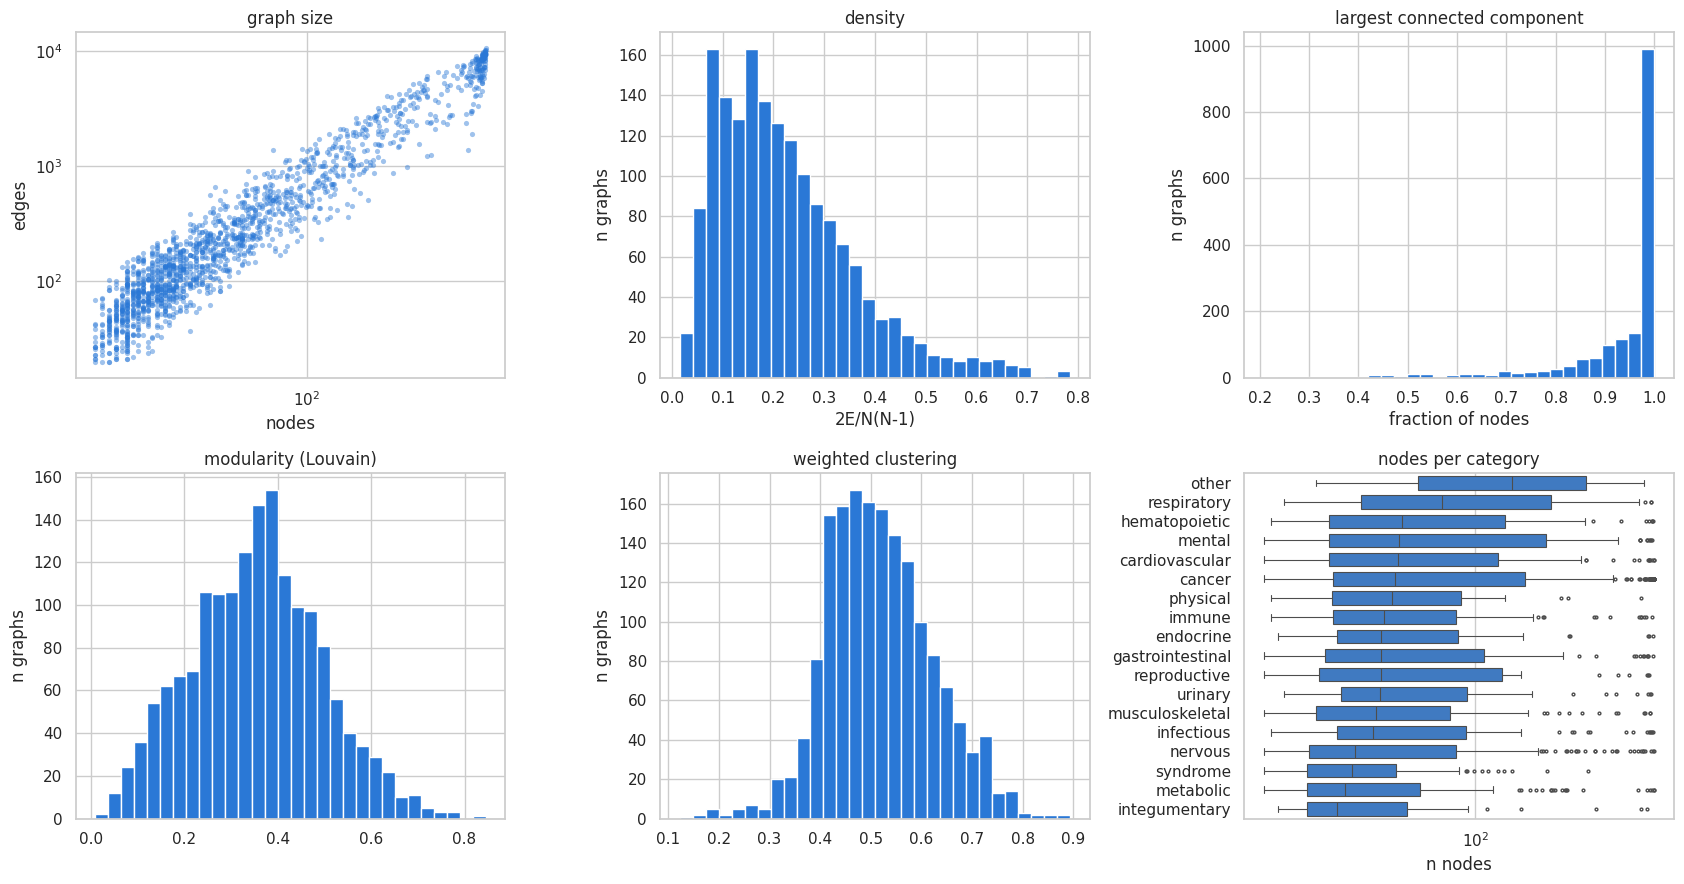

816 of 1,674 graphs have < 40 nodes (49%) — expected on an all-of-DISEASES universe, not a defect: the atlas is mostly small, specific diseases

197 graphs fragmented (largest component < 50% of nodes) or near-complete (density > 0.4):
                                                          disease   category  n_nodes  n_edges  density  lcc_frac
hyperphosphatasia with impaired intellectual development syndrome     mental       20      149 0.784211       1.0
        multiple congenital anomalies-hypotonia-seizures syndrome  metabolic       19      133 0.777778       1.0
                                                    typhoid fever infectious       17      104 0.764706       1.0
                                    Nicolaides-Baraitser syndrome   syndrome       21      157 0.747619       1.0
                                         infantile Refsum disease  metabolic       22      163 0.705628       1.0
                               mitochondrial complex I deficiency  metabolic    

In [18]:
fig, ax = plt.subplots(2, 3, figsize=(17, 9))
ax = ax.ravel()
# Size, not identity: ~1,750 points cannot carry 18 colours, so one hue and enough transparency to
# show where the atlas piles up.
ax[0].scatter(stats["n_nodes"], stats["n_edges"], s=14, color=SINGLE_HUE, alpha=0.45, linewidths=0)
ax[0].set(xscale="log", yscale="log", xlabel="nodes", ylabel="edges", title="graph size")
ax[1].hist(stats["density"], bins=30, color=SINGLE_HUE); ax[1].set(title="density", xlabel="2E/N(N-1)")
ax[2].hist(stats["lcc_frac"], bins=30, color=SINGLE_HUE)
ax[2].set(title="largest connected component", xlabel="fraction of nodes")
ax[3].hist(stats["modularity"], bins=30, color=SINGLE_HUE); ax[3].set(title="modularity (Louvain)")
ax[4].hist(stats["clustering"], bins=30, color=SINGLE_HUE); ax[4].set(title="weighted clustering")
node_order = stats.groupby("category")["n_nodes"].median().sort_values(ascending=False).index
sns.boxplot(data=stats, y="category", x="n_nodes", order=node_order, ax=ax[5],
            color=SINGLE_HUE, linewidth=0.8, fliersize=2, width=0.7)
ax[5].set(xscale="log", title="nodes per category", xlabel="n nodes", ylabel="")
for a in ax[:5]:
    a.set_ylabel(a.get_ylabel() or "n graphs")
plt.tight_layout(); plt.show()

# Three pathologies, reported separately, because at this atlas size "small" is the norm rather than
# an anomaly: the median disease in DISEASES has ~45 associated genes, so a 40-node threshold flags
# half the atlas and says nothing. Fragmented and near-complete graphs are still worth naming.
small = stats["n_nodes"] < 40
print(f"{small.sum():,} of {len(stats):,} graphs have < 40 nodes ({small.mean():.0%}) — expected on "
      f"an all-of-DISEASES universe, not a defect: the atlas is mostly small, specific diseases")
flags = stats[(stats["lcc_frac"] < 0.5) | (stats["density"] > 0.4)]
print(f"\n{len(flags)} graphs fragmented (largest component < 50% of nodes) or near-complete "
      f"(density > 0.4)" + (":" if len(flags) else " — none"))
if len(flags):
    print(flags.nlargest(12, "density")[
        ["disease", "category", "n_nodes", "n_edges", "density", "lcc_frac"]].to_string(index=False))
    if len(flags) > 12:
        print(f"   … and {len(flags) - 12} more")
print("\nLargest / smallest graphs:")
print(pd.concat([stats.head(5), stats.tail(5)])
      [["disease", "category", "n_nodes", "n_edges", "density", "modularity"]].to_string(index=False))

## 9 — A look at individual disease networks

Sanity check, not analysis: do the graphs look like disease modules — a connected core of well-known
genes plus periphery — or like noise? Only the largest connected component is drawn; node size is
degree, colour is the association score, and the ten highest-degree genes are labelled.

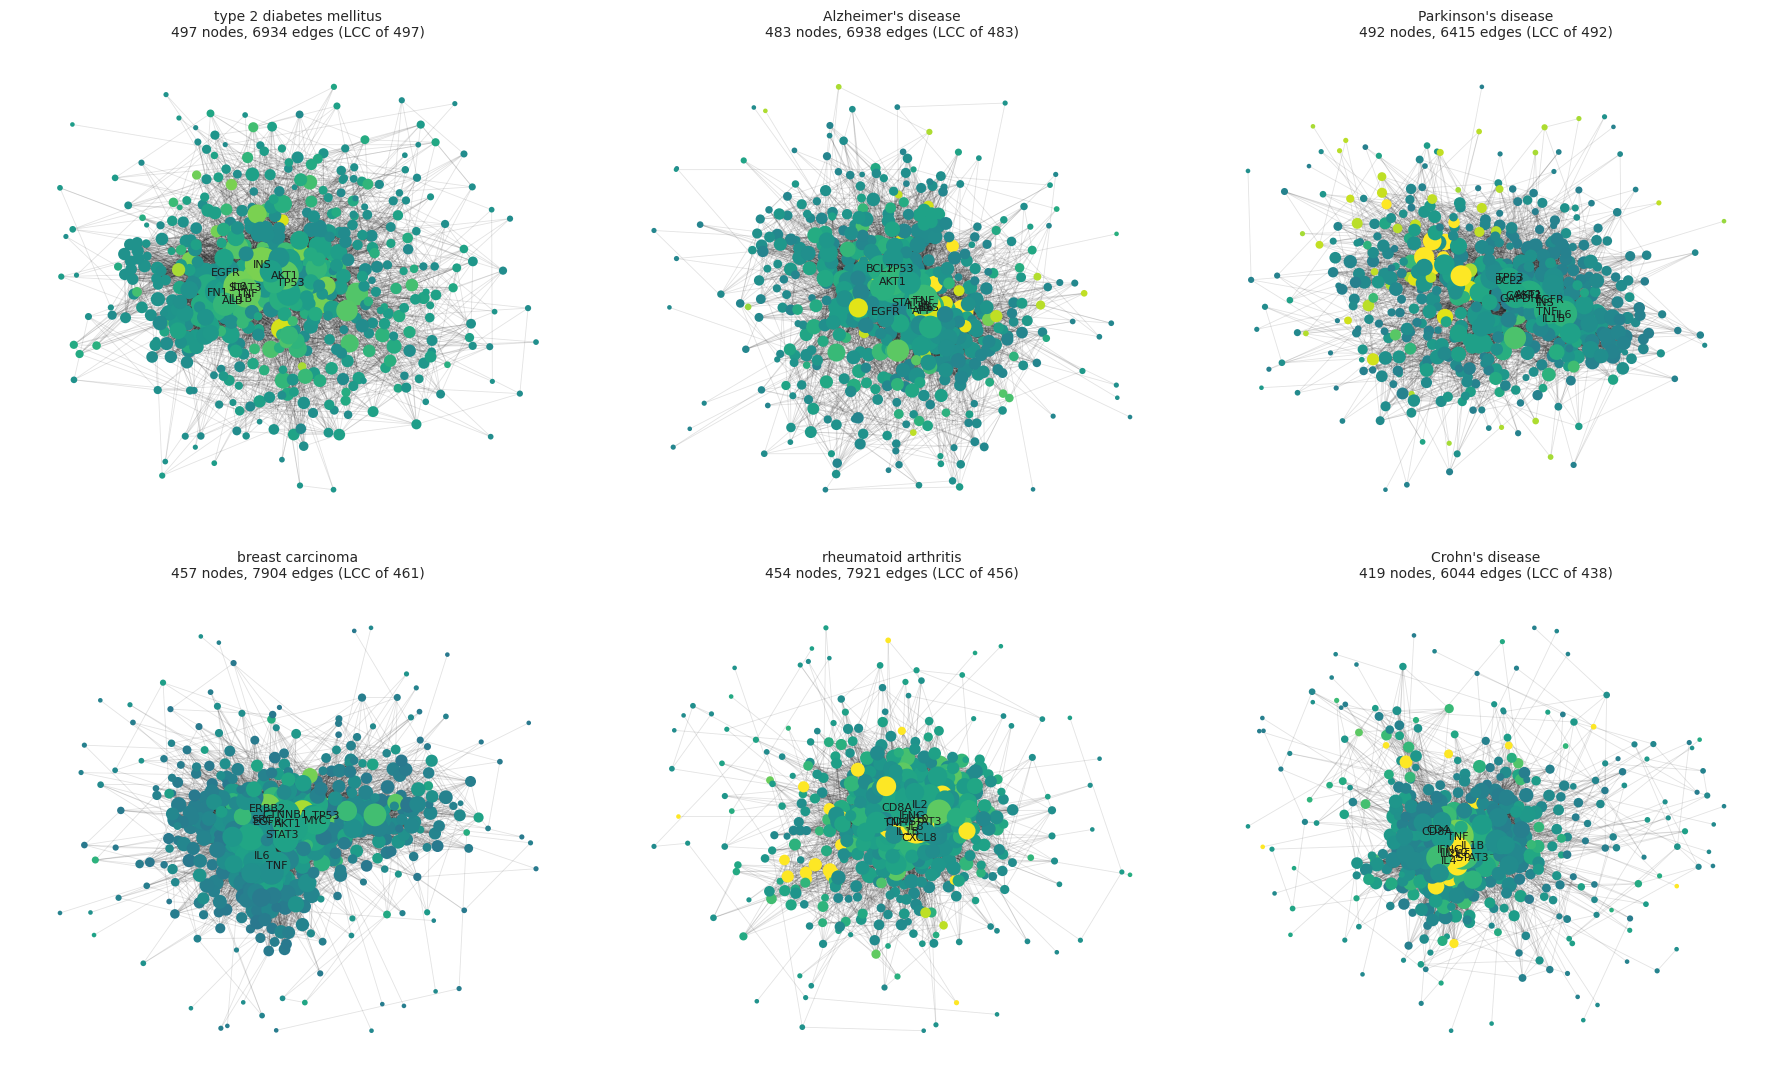

In [19]:
# Names as the Disease Ontology spells them (it lower-cases all but proper nouns). Any that the
# universe gates dropped fall back to the largest graphs, so the panel is never short.
SHOWCASE = ["type 2 diabetes mellitus", "Alzheimer's disease", "Parkinson's disease",
            "breast carcinoma", "rheumatoid arthritis", "Crohn's disease"]
by_name = {g.disease.lower(): g for g in graphs}
showcase = [by_name[d.lower()] for d in SHOWCASE if d.lower() in by_name][:6]
absent = [d for d in SHOWCASE if d.lower() not in by_name]
if absent:
    print(f"not in this atlas: {'; '.join(absent)} — filling with the largest graphs instead")
    chosen = {id(g) for g in showcase}
    for g in sorted(graphs, key=lambda g: -g.num_nodes):
        if len(showcase) == 6:
            break
        if id(g) not in chosen:
            showcase.append(g)

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
for axis, data in zip(axes.ravel(), showcase):
    g = to_networkx(data)
    lcc = g.subgraph(max(nx.connected_components(g), key=len))
    pos = nx.spring_layout(lcc, weight="weight", seed=42, k=0.35)
    deg = dict(lcc.degree())
    score = data.node_evidence[:, 0].numpy()
    nx.draw_networkx_edges(lcc, pos, ax=axis, alpha=0.12, width=0.6)
    nx.draw_networkx_nodes(lcc, pos, ax=axis, node_size=[8 + 3 * deg[n] for n in lcc],
                           node_color=[score[n] for n in lcc], cmap="viridis", vmin=0, vmax=1,
                           linewidths=0)
    hubs = sorted(lcc, key=lambda n: deg[n], reverse=True)[:10]
    nx.draw_networkx_labels(lcc, pos, ax=axis, font_size=8,
                            labels={n: data.gene_symbols[n] for n in hubs})
    axis.set_title(f"{data.disease}\n{lcc.number_of_nodes()} nodes, {lcc.number_of_edges()} edges "
                   f"(LCC of {g.number_of_nodes()})", fontsize=10)
    axis.axis("off")
for axis in axes.ravel()[len(showcase):]:
    axis.axis("off")
plt.tight_layout(); plt.show()

Pairwise gene-set overlap across 1,674 diseases: median 0.000, 90th pct 0.081, max 0.963

3 disease pairs with Jaccard >= 0.95, i.e. effectively the same gene set:
   0.963  liver cancer  ↔  hepatocellular carcinoma
   0.960  Charcot-Marie-Tooth disease type 1  ↔  Charcot-Marie-Tooth disease type 1A
   0.950  hyperphosphatasia with impaired intellectual development syndrome  ↔  multiple congenital anomalies-hypotonia-seizures syndrome


/home/s243564/miniforge3/envs/gea/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/s243564/miniforge3/envs/gea/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


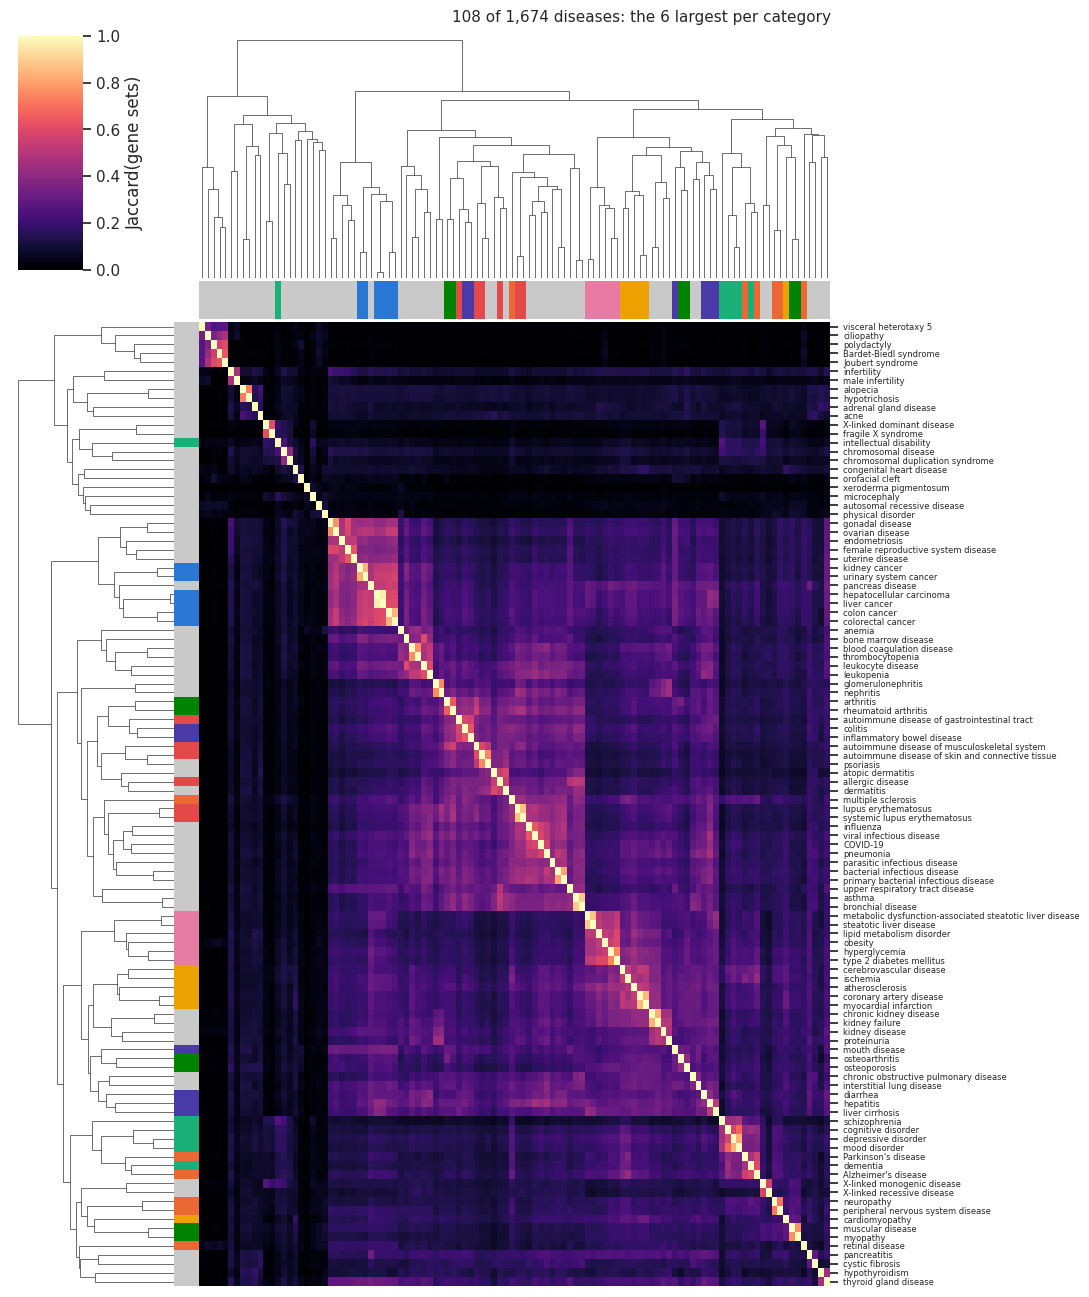

In [20]:
# Gene-overlap baseline (Jaccard) — the first of the disease-similarity baselines the plan calls for,
# and the one to keep in mind when a graph-level SAE feature later groups a set of diseases together.
# Vectorised: a disease × protein membership matrix turns ~1.5M set intersections into one product.
from scipy.sparse import csr_matrix

names = [g.disease for g in graphs]
protein_col = {p: i for i, p in enumerate(sorted({p for g in graphs for p in g.string_ids}))}
rows = np.concatenate([np.full(len(g.string_ids), i) for i, g in enumerate(graphs)])
cols = np.fromiter((protein_col[p] for g in graphs for p in g.string_ids), dtype=np.int64)
M = csr_matrix((np.ones(len(rows), dtype=np.float32), (rows, cols)),
               shape=(len(graphs), len(protein_col)))
intersection = (M @ M.T).toarray()
sizes = np.asarray(M.sum(1)).ravel()
J = intersection / (sizes[:, None] + sizes[None, :] - intersection)

iu = np.triu_indices(len(graphs), k=1)
print(f"Pairwise gene-set overlap across {len(graphs):,} diseases: median {np.median(J[iu]):.3f}, "
      f"90th pct {np.quantile(J[iu], 0.9):.3f}, max {J[iu].max():.3f}")

# The atlas is redundant by construction: DO carries near-synonymous concepts as separate terms
# ("colon cancer" beside "colorectal cancer"), and the universe gates only remove a parent that is a
# near-union of its *children* — two siblings, or a parent with one child, survive as a pair. A
# graph-level SAE feature that splits such a pair is reading noise, so count them here.
duplicate = np.argwhere(np.triu(J, k=1) >= 0.95)
print(f"\n{len(duplicate)} disease pairs with Jaccard >= 0.95, i.e. effectively the same gene set"
      + (":" if len(duplicate) else ""))
for i, j in duplicate[np.argsort(-J[tuple(duplicate.T)])][:10]:
    print(f"   {J[i, j]:.3f}  {names[i]}  ↔  {names[j]}")
if len(duplicate) > 10:
    print(f"   … and {len(duplicate) - 10} more")

# The full matrix has no readable labelling at this size, so the clustermap is drawn on a stratified
# sample — the N_PER_CATEGORY largest diseases of every category, which keeps each category present
# and each row legible. The numbers above are over the whole atlas, not the sample.
N_PER_CATEGORY = 6
sample = (pd.DataFrame({"i": np.arange(len(graphs)), "name": names, "n": sizes,
                        "category": [g.category for g in graphs]})
          .sort_values("n", ascending=False)
          .groupby("category", group_keys=False).head(N_PER_CATEGORY)
          .sort_values(["category", "name"]))
sub = sample["i"].to_numpy()
cat_colors = [CATEGORY_PALETTE[c] for c in sample["category"]]
cg = sns.clustermap(pd.DataFrame(J[np.ix_(sub, sub)],
                                 index=sample["name"].tolist(), columns=sample["name"].tolist()),
                    row_colors=cat_colors, col_colors=cat_colors, cmap="magma",
                    row_cluster=True, col_cluster=True, figsize=(13, 13),
                    xticklabels=False, yticklabels=1, cbar_kws=dict(label="Jaccard(gene sets)"))
cg.ax_heatmap.set_yticklabels(cg.ax_heatmap.get_yticklabels(), fontsize=6)
cg.figure.suptitle(f"{len(sub)} of {len(graphs):,} diseases: the {N_PER_CATEGORY} largest "
                   f"per category", y=1.0, fontsize=11)
plt.show()

## 10 — Export

The atlas is saved in the same format as `t2d_graphs.pt` / `ibd_graphs.pt`, so Part 2 can load it with
`torch.load(...)` and hand it straight to a loader.

In [21]:
torch.save(graphs, GRAPHS_FILE)
LABELS_FILE.write_text(json.dumps(
    dict(category_to_idx=cat_map, disease_to_idx=dis_map,
         n_struct=N_STRUCT, structural_cols=STRUCTURAL_COLS if N_STRUCT else [],
         identity_start=IDENTITY_START,
         esm_available=bool(esm_available), esm_pca_dim=ESM_PCA_DIM if esm_available else None,
         seed_source="DISEASES", diseases_channel=DISEASES_CHANNEL,
         diseases_min_conf=DISEASES_MIN_CONF, seed_min_score=SEED_MIN_SCORE,
         string_version=STRING_VERSION, string_min_score=STRING_MIN_SCORE,
         max_genes_per_disease=MAX_GENES_PER_DISEASE, drop_isolated=DROP_ISOLATED_NODES,
         keep_largest_cc=KEEP_LARGEST_CC), indent=2))

print(f"{len(graphs)} graphs → {GRAPHS_FILE}")
print(f"per-graph statistics → {STATS_FILE}")
print(f"label maps + build parameters → {LABELS_FILE}\n")
print(f"nodes  : {stats['n_nodes'].min()}–{stats['n_nodes'].max()} (median {stats['n_nodes'].median():.0f})")
print(f"edges  : {stats['n_edges'].min()}–{stats['n_edges'].max()} (median {stats['n_edges'].median():.0f})")
print(f"feature dim: {graphs[0].x.shape[1]}")
print("\ngraphs per category:")
print(stats["category"].value_counts().to_string())

1674 graphs → data/disgenet/disease_graphs_diseases-all.pt
per-graph statistics → data/disgenet/disease_graph_stats_diseases-all.csv
label maps + build parameters → data/disgenet/disease_graph_labels_diseases-all.json

nodes  : 15–499 (median 41)
edges  : 20–10707 (median 183)
feature dim: 257

graphs per category:
category
cancer              344
nervous             243
metabolic           133
musculoskeletal     109
syndrome            105
cardiovascular       94
immune               89
gastrointestinal     81
infectious           81
mental               72
hematopoietic        57
urinary              56
integumentary        52
endocrine            48
respiratory          37
reproductive         31
physical             28
other                14


### Where Part 1 ends

The atlas is now the frozen part of the experiment: from here on, anything surprising is the model's
doing, not the dataset's. **Part 2 continues below** (section 11) with the self-supervised GCN, and
Part 3 will add the three SAEs on top of its node, edge and graph representations.

Ablations named in the plan and already parameterised by section 0: 1-hop network expansion,
shuffled ESM features, degree-preserving edge rewiring, disease holdout, and transfer to the mouse
T2D LIONESS graphs.

---

# Part 2 — a self-supervised GCN over the disease atlas

The atlas is frozen; this half turns each disease graph into representations the three GEA SAEs can
later decompose. Following the design settled in the planning discussion, the encoder is deliberately
plain — a **weighted GCN**, not a Graph Transformer, not GINE, no learned pooling — because anything
the encoder compresses aggressively is something the SAE can no longer recover.

$$x_i = [\,\text{evidence}_i \,\Vert\, \text{structure}_i \,\Vert\, \text{ESM}_i\,]
\;\xrightarrow{\;\text{GCN}(A_{ij}=s_{ij}^{\text{STRING}})\;}\; h_i$$

and the three levels all come from those same contextualised node states:

| level | representation | objective |
|---|---|---|
| node | $h_i$ | reconstruct the protein's own ESM-2 vector — keeps molecular identity in $h_i$ |
| edge | $h_{ij} = \tfrac{1}{2}(h_i + h_j)$ | regress the STRING confidence $s_{ij}$ of **held-out** edges |
| graph | $h_G = \frac{1}{\lvert V_G\rvert}\sum_i h_i$ | contrastive: two lightly perturbed views of the same disease graph attract, different diseases repel |

$$\mathcal{L} = \lambda_N \mathcal{L}_N + \lambda_E \mathcal{L}_E + \lambda_G \mathcal{L}_G$$

**No disease-label supervision.** Training the encoder to classify disease would bake the label into
the representation, and the graph-level SAE would then rediscover the labels rather than biology.
Disease categories are used *only* as a held-out evaluation probe in section 15.

**Three departures from the literal plan, each because the naive version is trivially solvable:**

1. **Edges are masked.** Every training step hides a fraction of each graph's edges from message
   passing and predicts their confidence from the remaining network. Reconstructing edges the encoder
   can see is a lookup, not a task. Structural node features are disabled for the same reason
   (section 0): computed on the complete graph, they hand the head part of its answer.
2. **The encoder is residual** and the node term is a cosine rather than a squared error — see the
   comments in section 13. Both exist for the same reason: without them the node objective is not
   just hard but unsatisfiable, and it contributes no gradient worth speaking of.
3. **Negative pairs are included.** After the `combined_score ≥ 700` filter, observed confidences live
   in a narrow band (~0.7–1.0), so a constant predictor already scores well. Sampling non-adjacent
   pairs within the same graph as zero-confidence targets turns the objective into "*is* there an
   interaction, and how strong" and makes the metric in section 15 meaningful. Set
   `EDGE_NEG_RATIO = 0` to fall back to the literal formulation.

## 11 — Resume point, configuration and split

Everything below runs from `disease_graphs_*.pt`, so Part 2 can be re-run without rebuilding the
atlas.

> **On the size of the atlas.** ~1,750 graphs, so no level is obviously data-starved any more: the
> node and edge objectives see $10^5$–$10^6$ nodes and edges, and the *contrastive* objective — the
> weak link on the 90-disease atlas this notebook started from, with a few dozen negatives per
> batch — now has a real population of diseases to push apart. Two consequences to keep in mind. The
> graph-level numbers in section 15 are no longer a 6-way probe over 90 graphs but an 18-way probe
> over ~1,750, so they are not comparable with the stored values quoted there. And the atlas is
> **redundant by construction**: DO is a hierarchy, so sibling subtypes of one disease share most of
> their genes — section 9's Jaccard baseline is what to check before crediting a graph-level SAE
> feature with having found biology rather than an ontology neighbourhood.
>
> If you want still more graphs: lower `DISEASES_MIN_CONF` or `MIN_GENES_PER_DISEASE` (with
> `REFRESH_SEEDS = True`), relax the universe gates in section 0, or take the plan's disease × tissue
> route, which multiplies the atlas rather than adding to it.

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from pathlib import Path
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, global_mean_pool
from tqdm.auto import tqdm

from gea.gea import set_seed

# ── Resume: reload the atlas if it is not already in memory ──────────────────
try:
    graphs
except NameError:
    graphs = torch.load(GRAPHS_FILE, weights_only=False)
    print(f"(resumed) loaded {len(graphs)} graphs from {GRAPHS_FILE}")

# ── Encoder ─────────────────────────────────────────────────────────────────
INPUT_PROJ_DIM = 256          # identity block → 256; evidence + structure stay unprojected
GCN_HIDDEN     = [256, 256]   # message-passing widths; 2 layers = 2-hop receptive field
GCN_LATENT     = 128          # dim of h_i, h_ij and h_G — what the SAEs will see
GCN_DROPOUT    = 0.2
CONTRAST_DIM   = 64           # SimCLR-style projection head, discarded after training

# ── Objectives ──────────────────────────────────────────────────────────────
LAMBDA_NODE, LAMBDA_EDGE, LAMBDA_GRAPH = 1.0, 1.0, 0.5
EDGE_MASK_FRAC = 0.15         # fraction of undirected edges hidden from message passing each step
EDGE_NEG_RATIO = 1.0          # non-adjacent pairs sampled per masked edge (0 = literal formulation)
TEMPERATURE    = 0.2          # NT-Xent temperature

# ── Augmentations for the contrastive views (conservative on purpose) ───────
AUG_EDGE_DROP     = 0.15
AUG_NODE_DROP     = 0.00      # off by default — measured to make things worse, see section 12
AUG_WEIGHT_JITTER = 0.05      # std of Gaussian noise on STRING confidences
AUG_FEATURE_MASK  = 0.10      # fraction of node-feature dimensions zeroed

# ── Optimisation ────────────────────────────────────────────────────────────
EPOCHS, LR, WEIGHT_DECAY, BATCH_SIZE = 1000, 1e-3, 1e-4, 8
PATIENCE  = 40                # early stopping on validation loss
VAL_FRAC  = 0.2                # SEED comes from section 0 and covers this notebook end to end
GCN_CKPT  = DATA_DIR / f"disease_gcn_{ATLAS_TAG}.pt"

set_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
try:                                   # defined in section 3 when Part 1 ran in this kernel
    CATEGORY_PALETTE
except NameError:
    CATEGORY_PALETTE = category_palette([g.category for g in graphs])

# Feature layout, read off the graphs: x = [evidence (1) | structural (N_STRUCT) | identity (rest)]
IN_CHANNELS = graphs[0].x.shape[1]
N_STRUCT = int(getattr(graphs[0], "n_struct", 0) or 0)
IDENTITY_START = 1 + N_STRUCT
RECON_DIM = IN_CHANNELS - IDENTITY_START         # only the identity block is the node target
if RECON_DIM < 1:
    raise ValueError("node features carry no identity block to reconstruct")
print(f"{len(graphs)} graphs | node features {IN_CHANNELS} "
      f"(1 evidence + {N_STRUCT} structural + {RECON_DIM} identity) | device: {device}")
if N_STRUCT == 0:
    print("   (no structural block — the expected setting: those features leak into the masked-edge\n"
          "    objective, see section 0. The cost is that a protein's features are identical in every\n"
          "    disease, so per-graph signal has to come from message passing alone.)")
# The node objective reconstructs the identity block x[:, IDENTITY_START:]. Without ESM-2 that block
# is the association-evidence vector, which under DISEASES is identically zero — the objective would
# be vacuous rather than merely weak. Catch that here rather than in a silent NaN later.
_identity_std = float(torch.cat([g.x[:, IDENTITY_START:] for g in graphs]).std())
if _identity_std < 1e-6:
    raise ValueError(
        "the identity block x[:, IDENTITY_START:] is constant — there is nothing for the node objective to "
        "reconstruct. Compute ESM-2 embeddings (section 6) and rebuild the atlas before training."
    )
if RECON_DIM < 32:
    print("!! These graphs carry no ESM-2 embeddings — the node objective reconstructs the "
          "association-evidence\n   vector instead, which is far weaker. Run get_esm_embeddings.py "
          "(section 6) and rebuild the\n   atlas before reading anything into the node-level results.")

In [22]:
from sklearn.model_selection import train_test_split

# Split by graph, stratified by disease category. The split is saved with the checkpoint because
# Part 3 must extract SAE embeddings with the same partition.
y_cat = np.array([int(g.y) for g in graphs])
idx = np.arange(len(graphs))
counts = pd.Series(y_cat).value_counts()
stratify = y_cat if counts.min() >= 2 else None          # stratify only if every class can be split
train_idx, val_idx = train_test_split(idx, test_size=VAL_FRAC, random_state=SEED, stratify=stratify)

train_graphs = [graphs[i] for i in train_idx]
val_graphs   = [graphs[i] for i in val_idx]
train_loader = DataLoader(train_graphs, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_graphs,   batch_size=BATCH_SIZE, shuffle=False)
all_loader   = DataLoader(graphs,       batch_size=BATCH_SIZE, shuffle=False)   # for Part 3 / probes

print(f"train {len(train_graphs)} | val {len(val_graphs)} graphs")
print(pd.DataFrame({"category": [graphs[i].category for i in idx],
                    "split": np.where(np.isin(idx, train_idx), "train", "val")})
      .pivot_table(index="category", columns="split", aggfunc=len, fill_value=0).to_string())

train 72 | val 18 graphs
split           train  val
category                  
cancer             17    4
cardiovascular     10    2
immune             11    3
metabolic           6    2
neuro              11    3
other              17    4


## 12 — Graph surgery: undirected pairs, masking and augmentation

Every helper below works on a **batch**, and all of them go through one canonical pair key
$(\min(u,v), \max(u,v))$ so that the two stored directions of an edge are always dropped, masked or
kept together — perturbing one direction only would leave the GCN a back channel to the "removed"
edge.

In [ ]:
def pair_keys(edge_index, num_nodes):
    # Canonical id of the undirected pair behind each directed edge, plus the unique pair list.
    lo = torch.minimum(edge_index[0], edge_index[1])
    hi = torch.maximum(edge_index[0], edge_index[1])
    keys = lo * num_nodes + hi
    uniq, inverse = torch.unique(keys, return_inverse=True)
    return keys, uniq, inverse


def mask_edges(batch, frac=EDGE_MASK_FRAC):
    # Hide a fraction of undirected edges from message passing and return them as prediction targets.
    keys, uniq, inverse = pair_keys(batch.edge_index, batch.num_nodes)
    n_pairs = uniq.numel()
    n_hide = int(round(frac * n_pairs))
    if n_hide == 0:
        return batch.edge_index, batch.edge_attr, batch.edge_index[:, :0], batch.edge_attr[:0]

    dev = batch.edge_index.device
    hidden = torch.zeros(n_pairs, dtype=torch.bool, device=dev)
    hidden[torch.randperm(n_pairs, device=dev)[:n_hide]] = True
    drop = hidden[inverse]                                   # both directions of each hidden pair

    # One representative direction per hidden pair becomes a positive example.
    hidden_dir = torch.nonzero(drop, as_tuple=False).squeeze(1)
    order = torch.argsort(inverse[hidden_dir], stable=True)
    sorted_inv = inverse[hidden_dir][order]
    first = torch.ones_like(sorted_inv, dtype=torch.bool)
    first[1:] = sorted_inv[1:] != sorted_inv[:-1]
    rep = hidden_dir[order[first]]

    return (batch.edge_index[:, ~drop], batch.edge_attr[~drop],
            batch.edge_index[:, rep], batch.edge_attr[rep])


def sample_negative_pairs(batch, n, exclude_keys):
    # Random within-graph pairs that are not edges — the zero-confidence targets.
    if n <= 0:
        return batch.edge_index[:, :0]
    dev = batch.edge_index.device
    ptr = batch.ptr
    src = torch.randint(0, batch.num_nodes, (n,), device=dev)
    g = batch.batch[src]
    lo, hi = ptr[g], ptr[g + 1]
    dst = lo + (torch.rand(n, device=dev) * (hi - lo).float()).long()
    keep = src != dst
    src, dst = src[keep], dst[keep]
    key = torch.minimum(src, dst) * batch.num_nodes + torch.maximum(src, dst)
    keep = ~torch.isin(key, exclude_keys)
    return torch.stack([src[keep], dst[keep]])


def augment(batch, edge_drop=AUG_EDGE_DROP, node_drop=AUG_NODE_DROP, jitter=AUG_WEIGHT_JITTER,
            feat_mask=AUG_FEATURE_MASK):
    # One contrastive view: drop whole undirected edges, jitter confidences, mask feature dimensions,
    # and optionally hide nodes.
    #
    # Node dropping looks like the obvious cure for the composition dominance that section 15
    # measures — if every view holds the same proteins, recognising the gene set already solves the
    # contrastive task. It was tried (60-graph atlas, drop 0.15) and it made matters *worse*: the
    # correlation of h_G with pure ESM composition rose 0.74 → 0.82, edge AUC fell 0.89 → 0.88, and
    # the category probe moved 0.70 → 0.72, i.e. within noise. That follows from the readout: a mean
    # over a random subset of nodes is an unbiased estimate of the mean over all of them, so dropping
    # nodes teaches the encoder to estimate composition more robustly rather than to look past it.
    # Kept as a knob, but the readout — not the augmentation — is the thing to change (section 15).
    dev = batch.edge_index.device
    keep_node = torch.rand(batch.num_nodes, device=dev) >= node_drop
    keys, uniq, inverse = pair_keys(batch.edge_index, batch.num_nodes)
    keep = (torch.rand(uniq.numel(), device=dev) >= edge_drop)[inverse]
    keep = keep & keep_node[batch.edge_index[0]] & keep_node[batch.edge_index[1]]

    edge_index = batch.edge_index[:, keep]
    edge_weight = batch.edge_attr[keep]
    if jitter > 0:
        edge_weight = (edge_weight + torch.randn_like(edge_weight) * jitt er).clamp(1e-3, 1.0)

    x = batch.x * keep_node.unsqueeze(1)
    if feat_mask > 0:
        dim_mask = (torch.rand(x.shape[1], device=x.device) >= feat_mask).float()
        x = x * dim_mask
    return x, edge_index, edge_weight, keep_node


def encode_view(model, batch, view):
    # Graph embedding of one augmented view, pooling only over the nodes the view kept.
    x, edge_index, edge_weight, keep_node = view
    z_node, _ = model.encode(batch, x=x, edge_index=edge_index, edge_weight=edge_weight)
    return global_mean_pool(z_node[keep_node], batch.batch[keep_node], size=batch.num_graphs)

## 13 — The model

`encode()` returns `(z_node, z_graph)` and the edge head consumes `[h_i ‖ h_j]` but averages the two
halves internally, so the edge representation really is $(h_i+h_j)/2$ *and* the model still satisfies
the calling convention of `gea.gea.extract_embeddings`, which is what Part 3 will use to export the
three levels for the SAEs.

In [24]:
class EdgeScoreHead(nn.Module):
    # Input is the concatenated pair [h_i ‖ h_j] (the convention gea.extract_embeddings uses);
    # the mean is taken here so the edge embedding is exactly (h_i + h_j) / 2.
    def __init__(self, latent_dim, hidden=128):
        super().__init__()
        self.mlp = nn.Sequential(nn.Linear(latent_dim, hidden), nn.ReLU(), nn.Linear(hidden, 1))

    @staticmethod
    def embed(h_src, h_dst):
        return 0.5 * (h_src + h_dst)

    def forward(self, pair_features):
        d = pair_features.shape[1] // 2
        h = self.embed(pair_features[:, :d], pair_features[:, d:])
        return torch.sigmoid(self.mlp(h)).squeeze(-1)       # STRING confidence lives in (0, 1]


class DiseaseGCN(nn.Module):
    def __init__(self, in_channels, recon_dim, identity_start=None, proj_dim=INPUT_PROJ_DIM,
                 hidden=GCN_HIDDEN, latent=GCN_LATENT, dropout=GCN_DROPOUT,
                 contrast_dim=CONTRAST_DIM):
        super().__init__()
        # Evidence and structural features pass through untouched — they are a handful of dimensions
        # and would otherwise be swamped by the 256 ESM dims — while only the identity block is
        # projected. Same idea as GNNModel.input_proj in the LIONESS pipeline, one block wider.
        self.identity_start = IDENTITY_START if identity_start is None else identity_start
        self.proj_active = proj_dim is not None and in_channels != proj_dim
        gnn_in = proj_dim if self.proj_active else in_channels
        self.input_proj = (nn.Sequential(
            nn.Linear(in_channels - self.identity_start, proj_dim - self.identity_start), nn.ReLU())
            if self.proj_active else nn.Identity())

        dims = [gnn_in] + list(hidden) + [latent]
        self.convs = nn.ModuleList([GCNConv(dims[i], dims[i + 1]) for i in range(len(dims) - 1)])
        # Residual path. Symmetric-normalised averaging over ~25 neighbours washes a node's own
        # features out within two layers, which would make the node objective unsatisfiable no matter
        # how long it trains; the skip keeps identity available while the convolutions add context.
        self.skips = nn.ModuleList([nn.Linear(dims[i], dims[i + 1], bias=False)
                                    for i in range(len(dims) - 1)])
        self.dropout = nn.Dropout(dropout)

        self.node_decoder = nn.Sequential(nn.Linear(latent, 256), nn.ReLU(), nn.Linear(256, recon_dim))
        self.edge_predictor = EdgeScoreHead(latent)
        self.contrast_head = nn.Sequential(nn.Linear(latent, latent), nn.ReLU(),
                                           nn.Linear(latent, contrast_dim))

    def _project(self, x):
        if not self.proj_active:
            return x
        k = self.identity_start
        return torch.cat([x[:, :k], self.input_proj(x[:, k:])], dim=1)

    def encode(self, data, x=None, edge_index=None, edge_weight=None):
        # Signature is compatible with gea.gea.extract_embeddings, which calls encode(batch).
        x = self._project(data.x if x is None else x)
        edge_index = data.edge_index if edge_index is None else edge_index
        edge_weight = data.edge_attr if edge_weight is None else edge_weight
        for i, (conv, skip) in enumerate(zip(self.convs, self.skips)):
            h = conv(x, edge_index, edge_weight) + skip(x)
            x = self.dropout(F.relu(h)) if i < len(self.convs) - 1 else h
        return x, global_mean_pool(x, data.batch)

    def score_pairs(self, z_node, pair_index):
        return self.edge_predictor(torch.cat([z_node[pair_index[0]], z_node[pair_index[1]]], dim=1))


def node_reconstruction_loss(pred, target):
    # The plan writes this term as an MSE. On L2-normalised ESM vectors an MSE is numerically tiny
    # (~1e-3) and is simply swamped by the edge and contrastive terms, so the direction-only form is
    # used instead: it is the same objective up to scale, and it is what section 15 measures.
    return (1 - F.cosine_similarity(pred, target, dim=1)).mean()


def nt_xent(z1, z2, temperature=TEMPERATURE):
    # SimCLR loss: the other view of the same graph is the positive, every other graph in the batch
    # is a negative. With a small atlas the negative pool is small — see the note in section 11.
    z = F.normalize(torch.cat([z1, z2]), dim=1)
    n = z1.shape[0]
    sim = z @ z.t() / temperature
    sim.fill_diagonal_(float("-inf"))
    target = torch.cat([torch.arange(n, 2 * n), torch.arange(0, n)]).to(z.device)
    return F.cross_entropy(sim, target)

## 14 — Training

One step: encode the graph with `EDGE_MASK_FRAC` of its edges hidden → reconstruct node identity,
score the hidden edges plus sampled non-edges, and pull two augmented views of every graph together.
Validation runs the same computation without gradients, and the best validation checkpoint is kept.

In [25]:
def run_epoch(model, loader, optimizer=None):
    train = optimizer is not None
    model.train(train)
    totals = dict(loss=0.0, node=0.0, edge=0.0, graph=0.0, n=0)

    for batch in loader:
        batch = batch.to(device)
        with torch.set_grad_enabled(train):
            # ── node + edge objectives, on the edge-masked graph ──────────────
            msg_index, msg_weight, pos_index, pos_score = mask_edges(batch)
            z_node, _ = model.encode(batch, edge_index=msg_index, edge_weight=msg_weight)

            loss_node = node_reconstruction_loss(model.node_decoder(z_node), batch.x[:, IDENTITY_START:])

            all_keys, _, _ = pair_keys(batch.edge_index, batch.num_nodes)
            n_neg = int(round(EDGE_NEG_RATIO * pos_index.shape[1]))
            neg_index = sample_negative_pairs(batch, n_neg, all_keys.unique())
            pair_index = torch.cat([pos_index, neg_index], dim=1)
            target = torch.cat([pos_score, torch.zeros(neg_index.shape[1], device=device)])
            loss_edge = (F.mse_loss(model.score_pairs(z_node, pair_index), target)
                         if pair_index.shape[1] else torch.zeros((), device=device))

            # ── graph objective: two conservative views ───────────────────────
            v1 = encode_view(model, batch, augment(batch))
            v2 = encode_view(model, batch, augment(batch))
            loss_graph = (nt_xent(model.contrast_head(v1), model.contrast_head(v2))
                          if batch.num_graphs > 1 else torch.zeros((), device=device))

            loss = LAMBDA_NODE * loss_node + LAMBDA_EDGE * loss_edge + LAMBDA_GRAPH * loss_graph

        if train:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        b = batch.num_graphs
        totals["loss"] += loss.item() * b
        totals["node"] += loss_node.item() * b
        totals["edge"] += loss_edge.detach().item() * b
        totals["graph"] += loss_graph.detach().item() * b
        totals["n"] += b

    n = max(totals.pop("n"), 1)
    return {k: v / n for k, v in totals.items()}

In [26]:
RETRAIN_GCN = False    # True trains even when a checkpoint exists; False reuses it (Part 3 needs
                      # the trained encoder, and retraining it every time costs minutes for nothing)

set_seed(SEED)
model = DiseaseGCN(IN_CHANNELS, RECON_DIM).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
n_params = sum(p.numel() for p in model.parameters())
print(f"DiseaseGCN: {n_params:,} parameters | latent {GCN_LATENT} | layers {len(model.convs)}")

GRAPHS_FP = graphs_fingerprint(graphs)
ckpt = (torch.load(GCN_CKPT, map_location=device, weights_only=False)
        if GCN_CKPT.exists() else None)
if ckpt is not None and ckpt.get("graphs_fp") != GRAPHS_FP:
    print(f"checkpoint was trained on a different atlas ({ckpt.get('graphs_fp')} vs {GRAPHS_FP}) "
          f"— retraining.")
    ckpt = None

if ckpt is not None and not RETRAIN_GCN:
    model.load_state_dict(ckpt["state_dict"])
    history = pd.DataFrame(ckpt["history"])
    best = dict(val=float(history["val_loss"].min()), epoch=int(ckpt["best_epoch"]))
    print(f"(cached) {GCN_CKPT.name} — best epoch {best['epoch']}, val loss {best['val']:.4f}. "
          f"Set RETRAIN_GCN = True to train from scratch.")

else:
    history, best = [], dict(val=float("inf"), epoch=-1, state=None)
    bar = tqdm(range(EPOCHS), desc="Training DiseaseGCN")
    for epoch in bar:
        tr = run_epoch(model, train_loader, optimizer)
        va = run_epoch(model, val_loader)
        history.append({"epoch": epoch, **{f"train_{k}": v for k, v in tr.items()},
                        **{f"val_{k}": v for k, v in va.items()}})
        if va["loss"] < best["val"] - 1e-5:
            best = dict(val=va["loss"], epoch=epoch,
                        state={k: v.detach().cpu().clone() for k, v in model.state_dict().items()})
        bar.set_postfix(train=f"{tr['loss']:.4f}", val=f"{va['loss']:.4f}", best=f"{best['val']:.4f}")
        if epoch - best["epoch"] >= PATIENCE:
            print(f"\nearly stop at epoch {epoch} (no val improvement for {PATIENCE} epochs)")
            break

    model.load_state_dict(best["state"])
    history = pd.DataFrame(history)
    print(f"best epoch {best['epoch']} | val loss {best['val']:.4f}")

    torch.save({"state_dict": model.state_dict(),
                "graphs_fp": GRAPHS_FP,
                "config": dict(in_channels=IN_CHANNELS, recon_dim=RECON_DIM, proj_dim=INPUT_PROJ_DIM,
                               hidden=GCN_HIDDEN, latent=GCN_LATENT, dropout=GCN_DROPOUT,
                               lambdas=(LAMBDA_NODE, LAMBDA_EDGE, LAMBDA_GRAPH),
                               edge_mask_frac=EDGE_MASK_FRAC, edge_neg_ratio=EDGE_NEG_RATIO, seed=SEED),
                "split": {"train": train_idx.tolist(), "val": val_idx.tolist()},
                "history": history.to_dict("list"), "best_epoch": best["epoch"]}, GCN_CKPT)
    print(f"checkpoint → {GCN_CKPT}")

DiseaseGCN: 534,080 parameters | latent 128 | layers 3
(cached) disease_gcn_diseases.pt — best epoch 352, val loss 0.5442. Set RETRAIN_GCN = True to train from scratch.


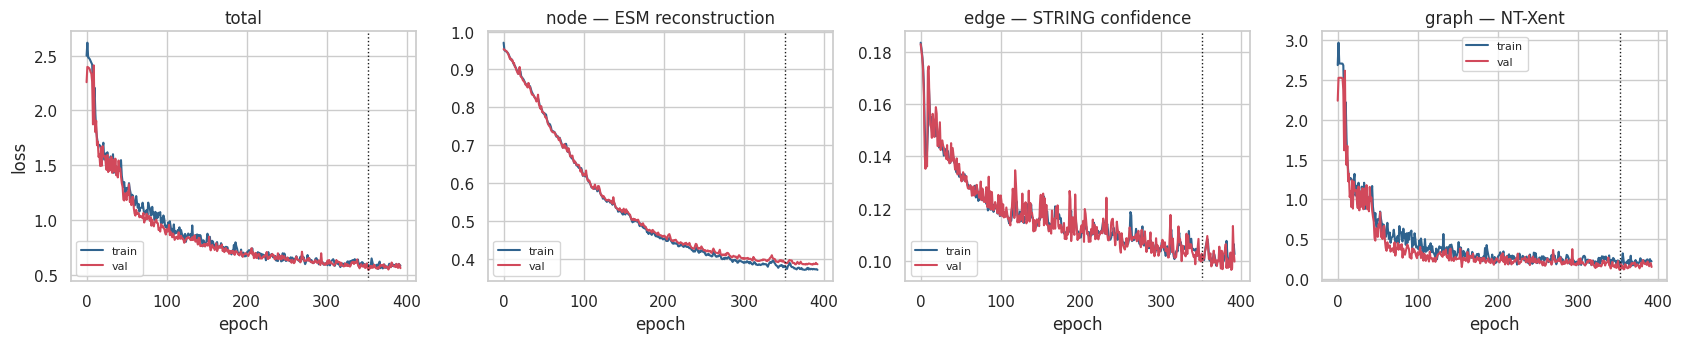

In [27]:
fig, ax = plt.subplots(1, 4, figsize=(17, 3.6))
for a, (col, title) in zip(ax, [("loss", "total"), ("node", "node — ESM reconstruction"),
                                ("edge", "edge — STRING confidence"), ("graph", "graph — NT-Xent")]):
    a.plot(history["epoch"], history[f"train_{col}"], label="train", color="#30638e")
    a.plot(history["epoch"], history[f"val_{col}"], label="val", color="#d1495b")
    a.axvline(best["epoch"], color="k", ls=":", lw=1)
    a.set(title=title, xlabel="epoch")
    a.legend(fontsize=8)
ax[0].set_ylabel("loss")
plt.tight_layout(); plt.show()

## 15 — Does the encoder actually learn anything?

Four questions, each with a baseline that a useless encoder would already match:

1. **Node** — is $h_i$ still the protein it started as? Cosine similarity between the reconstruction
   and the true identity vector, against the "predict the dataset mean protein" baseline.
2. **Edge** — held-out edges only: correlation with the true confidence, and how well real edges
   separate from sampled non-edges (AUC). A constant predictor gives AUC 0.5.
3. **Graph** — do two perturbed views of the same disease land next to each other? Top-1 retrieval
   among all graphs.
4. **Graph, harder** — does $h_G$ carry disease biology *beyond gene composition and graph size*?
   A linear probe for disease category on $h_G$, compared with probes on the mean ESM composition
   $\mu_G$ and on plain topology descriptors, plus the correlation of the $h_G$ similarity matrix with
   gene-overlap, composition and topology similarity. This is the ESM-vs-topology decomposition the
   plan asks for, run *before* any SAE so that the SAE's later claims have a reference point.

**Where the last stored run landed** — the hand-curated 90-disease atlas (`ATLAS_TAG = "diseases"`),
264-dim node features, **structural block on**. Two things have changed since, so read the table as a
record rather than as a target: those structural features were switched off as a leak into the edge
objective (section 0), which makes the edge and topology rows optimistic, and the universe is now all
of DISEASES, which turns the category probe from a 6-way problem over 90 graphs into an 18-way one
over ~1,750 and moves every baseline in the right-hand column with it:

| level | value | baseline |
|---|---|---|
| node — reconstruction cosine | 0.633 | 0.052 (predict the mean protein) |
| edge — held-out edges vs non-edges | **AUC 0.917** | 0.5 |
| edge — confidence of real edges | $r = 0.215$ | — |
| edge — RMSE over scored pairs | 0.291 | 0.429 (constant predictor) |
| graph — two views retrieve the same disease | 100.0% | 1.1% (chance) |
| graph — disease-category probe on $h_G$ | 0.78 ± 0.06 | 0.82 (ESM composition), 0.23 (majority) |

The **edge level is where the encoder is unambiguously doing network inference**: those edges were
invisible to it, and it still tells them from sampled non-edges more than nine times out of ten. The
graph level has closed most of the gap to the composition baseline (0.78 against 0.82, from 0.71
against 0.81 before the identity block was complete) but still tracks *what is in the graph* more
than *how it is wired* — $\rho = 0.755$ against ESM composition versus $0.546$ against topology.

Note the node cosine **fell** when the ESM file was completed, 0.858 → 0.633, and that is the
expected direction: with no genes left on random fallback vectors, whitened PCA retains 91.8% of the
identity variance instead of 87.9%, so there is more real structure for the decoder to reproduce and
less noise it was never going to fit. Against the mean-protein baseline of 0.052 it is still an
order of magnitude better than doing nothing.

In [27]:
@torch.no_grad()
def collect(loader):
    # Node/edge/graph outputs of the frozen encoder, plus the raw composition baseline.
    model.eval()
    out = dict(cos=[], edge_pred=[], edge_true=[], edge_is_real=[], h_graph=[], mu_esm=[],
               y=[], names=[], target=[])
    for batch in loader:
        batch = batch.to(device)
        msg_index, msg_weight, pos_index, pos_score = mask_edges(batch)
        z_node, _ = model.encode(batch, edge_index=msg_index, edge_weight=msg_weight)

        target = batch.x[:, IDENTITY_START:]
        out["target"].append(target.cpu())
        out["cos"].append(F.cosine_similarity(model.node_decoder(z_node), target, dim=1).cpu())

        all_keys, _, _ = pair_keys(batch.edge_index, batch.num_nodes)
        neg_index = sample_negative_pairs(batch, pos_index.shape[1], all_keys.unique())
        pair_index = torch.cat([pos_index, neg_index], dim=1)
        out["edge_pred"].append(model.score_pairs(z_node, pair_index).cpu())
        out["edge_true"].append(torch.cat([pos_score,
                                           torch.zeros(neg_index.shape[1], device=device)]).cpu())
        out["edge_is_real"].append(torch.cat([torch.ones(pos_index.shape[1]),
                                              torch.zeros(neg_index.shape[1])]))

        _, h_graph = model.encode(batch)
        out["h_graph"].append(h_graph.cpu())
        out["mu_esm"].append(global_mean_pool(batch.x[:, IDENTITY_START:], batch.batch).cpu())
        out["y"].append(batch.y.cpu())
        out["names"].extend(batch.disease)

    res = {k: (torch.cat(v) if k != "names" else v) for k, v in out.items()}
    # Baseline: what cosine you get by predicting the dataset-mean protein for every node.
    mean_target = res["target"].mean(0, keepdim=True)
    res["baseline_cos"] = F.cosine_similarity(mean_target.expand_as(res["target"]),
                                              res["target"], dim=1)
    return res


set_seed(SEED)   # collect() draws its own edge masks and negative pairs — fix them too
val_res = collect(val_loader)
all_res = collect(all_loader)

print("── node level (validation graphs) ──")
print(f"cosine(reconstruction, true identity): mean {val_res['cos'].mean():.3f} "
      f"| median {val_res['cos'].median():.3f}")
print(f"baseline — predict the mean protein  : mean {val_res['baseline_cos'].mean():.3f}")

── node level (validation graphs) ──
cosine(reconstruction, true identity): mean 0.618 | median 0.660
baseline — predict the mean protein  : mean 0.052


── edge level (held-out edges of validation graphs) ──
pairs scored: 21,095 (10,996 real edges, 10,099 non-edges)
real vs non-edge separation   : AUC 0.887  (0.5 = uninformative)
confidence of real edges      : pearson r 0.157 | spearman 0.198
RMSE over all scored pairs    : 0.314 | constant-predictor RMSE 0.429


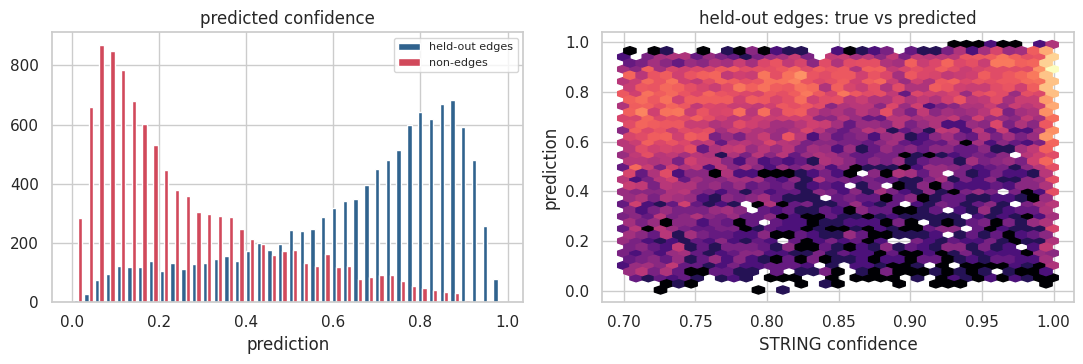

In [28]:
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import roc_auc_score

pred, true, real = val_res["edge_pred"].numpy(), val_res["edge_true"].numpy(), val_res["edge_is_real"].numpy()
pos = real == 1
print("── edge level (held-out edges of validation graphs) ──")
print(f"pairs scored: {len(pred):,} ({int(pos.sum()):,} real edges, {int((~pos).sum()):,} non-edges)")
print(f"real vs non-edge separation   : AUC {roc_auc_score(real, pred):.3f}  (0.5 = uninformative)")
print(f"confidence of real edges      : pearson r {pearsonr(pred[pos], true[pos])[0]:.3f} "
      f"| spearman {spearmanr(pred[pos], true[pos])[0]:.3f}")
print(f"RMSE over all scored pairs    : {np.sqrt(((pred - true) ** 2).mean()):.3f} "
      f"| constant-predictor RMSE {np.sqrt(((true.mean() - true) ** 2).mean()):.3f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].hist([pred[pos], pred[~pos]], bins=40, label=["held-out edges", "non-edges"],
           color=["#30638e", "#d1495b"], stacked=False)
ax[0].set(title="predicted confidence", xlabel="prediction"); ax[0].legend(fontsize=8)
ax[1].hexbin(true[pos], pred[pos], gridsize=35, cmap="magma", bins="log")
ax[1].set(title="held-out edges: true vs predicted", xlabel="STRING confidence", ylabel="prediction")
plt.tight_layout(); plt.show()

In [29]:
# ── graph level: are two views of the same disease each other's nearest neighbour? ──
@torch.no_grad()
def view_retrieval(loader, repeats=5):
    model.eval()
    hits = total = 0
    for _ in range(repeats):
        v1, v2 = [], []
        for batch in loader:
            batch = batch.to(device)
            v1.append(encode_view(model, batch, augment(batch)).cpu())
            v2.append(encode_view(model, batch, augment(batch)).cpu())
        a = F.normalize(torch.cat(v1), dim=1)
        b = F.normalize(torch.cat(v2), dim=1)
        hits += int((a @ b.t()).argmax(dim=1).eq(torch.arange(a.shape[0])).sum())
        total += a.shape[0]
    return hits / total


set_seed(SEED)   # each repeat draws fresh augmentations
acc = view_retrieval(all_loader)
print("── graph level ──")
print(f"two augmented views retrieve the same disease: {acc:.1%} top-1 "
      f"(chance {1 / len(graphs):.1%}, {len(graphs)} candidates)")

── graph level ──
two augmented views retrieve the same disease: 99.8% top-1 (chance 1.1%, 90 candidates)


In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# Topology-only descriptors: what a model that ignored biology entirely could still know.
topo = np.array([[g.num_nodes, g.edge_index.shape[1] / 2,
                  (g.edge_index.shape[1] / 2) / max(g.num_nodes * (g.num_nodes - 1) / 2, 1),
                  float(g.edge_attr.mean()), float((g.edge_type == 0).float().mean())]
                 for g in graphs])

H = all_res["h_graph"].numpy()          # learned graph embedding
MU = all_res["mu_esm"].numpy()          # mean node identity — pure molecular composition
y = all_res["y"].numpy()

counts = pd.Series(y).value_counts()
n_splits = int(min(5, counts.min()))
if n_splits < 2:
    print("too few graphs per category for a cross-validated probe — skipping")
else:
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    probe = lambda X: cross_val_score(
        make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000, C=1.0)),
        X, y, cv=cv, scoring="accuracy")
    rows = []
    for name, X in [("h_G (learned)", H), ("mean ESM composition", MU), ("topology only", topo),
                    ("h_G + topology", np.hstack([H, topo]))]:
        s = probe(X)
        rows.append(dict(features=name, dim=X.shape[1], accuracy=f"{s.mean():.2f} ± {s.std():.2f}"))
    rows.append(dict(features="majority class", dim=0,
                     accuracy=f"{counts.max() / counts.sum():.2f}"))
    print(f"── disease-category probe ({n_splits}-fold CV, {len(graphs)} graphs, "
          f"{counts.size} categories) ──")
    print(pd.DataFrame(rows).to_string(index=False))
    print("\nThe probe is a diagnostic, not an objective: the encoder never saw these labels.")

── disease-category probe (5-fold CV, 90 graphs, 6 categories) ──
            features  dim    accuracy
       h_G (learned)  128 0.77 ± 0.05
mean ESM composition  256 0.82 ± 0.10
       topology only    5 0.56 ± 0.10
      h_G + topology  133 0.80 ± 0.08
      majority class    0        0.23

The probe is a diagnostic, not an objective: the encoder never saw these labels.


In [31]:
# ── what does h_G track: gene composition, molecular composition, or network organisation? ──
def upper(m):
    return m[np.triu_indices_from(m, k=1)]


def cos_sim(X):
    Xn = X / np.linalg.norm(X, axis=1, keepdims=True).clip(1e-9)
    return Xn @ Xn.T


sets = [set(g.string_ids) for g in graphs]
J = np.array([[len(a & b) / len(a | b) for b in sets] for a in sets])
topo_z = (topo - topo.mean(0)) / topo.std(0).clip(1e-9)
topo_sim = -np.linalg.norm(topo_z[:, None, :] - topo_z[None, :, :], axis=-1)   # negative distance

sim_h = cos_sim(H)
rows = []
for name, M in [("gene overlap (Jaccard)", J), ("ESM composition", cos_sim(MU)),
                ("topology similarity", topo_sim)]:
    r, p = spearmanr(upper(sim_h), upper(M))
    rows.append(dict(reference=name, spearman_rho=round(r, 3), p_value=f"{p:.1e}"))
print("── similarity of h_G vs independent references ──")
print(pd.DataFrame(rows).to_string(index=False))
print("\nA graph feature that is interesting later should not be fully explained by the first two "
      "rows;\nthis table is the reference point Part 3 will be read against.")

── similarity of h_G vs independent references ──
             reference  spearman_rho  p_value
gene overlap (Jaccard)         0.669  0.0e+00
       ESM composition         0.709  0.0e+00
   topology similarity         0.399 3.5e-153

A graph feature that is interesting later should not be fully explained by the first two rows;
this table is the reference point Part 3 will be read against.


In [ ]:
import matplotlib.patheffects as pe

try:
    from umap import UMAP
except Exception:
    import umap.umap_ as umap
    UMAP = umap.UMAP

# The UMAP is always fitted on every graph — only the drawing changes below, so the layout is the
# same map whichever categories you play down. "grey" keeps them as context in both panels; "hide"
# removes them from the figure altogether.
# The palette hands a hue to the eight largest categories only (section 0), so everything it painted
# grey is muted here as well: 18 categories cannot be told apart by colour on one scatter.
MUTED_CATEGORIES = {c for c, colour in CATEGORY_PALETTE.items() if colour == CATEGORY_GREY}
MUTED_STYLE = "grey"          # "grey" | "hide"
MUTED_LABEL = (", ".join(sorted(MUTED_CATEGORIES)) if len(MUTED_CATEGORIES) <= 3
               else f"{len(MUTED_CATEGORIES)} smaller categories")

cats_all = np.array([g.category for g in graphs])
muted = np.isin(cats_all, list(MUTED_CATEGORIES))
focus = np.where(~muted)[0]
shown = focus if MUTED_STYLE == "hide" else np.arange(len(graphs))
print(f"{len(focus)}/{len(graphs)} graphs in focus; {muted.sum()} "
      f"({MUTED_LABEL or 'none'}) {'hidden' if MUTED_STYLE == 'hide' else 'drawn as grey context'}")

coords = UMAP(n_components=2, random_state=SEED).fit_transform(
    StandardScaler().fit_transform(H))

fig, ax = plt.subplots(1, 2, figsize=(20, 6))

# Keep the left panel clean: no grid, no large box around the axes
ax[0].grid(False)
ax[0].set_axisbelow(True)
ax[0].set_facecolor("white")
for spine in ax[0].spines.values():
    spine.set_visible(False)

if MUTED_STYLE == "grey" and muted.any():
    ax[0].scatter(coords[muted, 0], coords[muted, 1], s=8, color=CATEGORY_GREY, alpha=0.6,
                  linewidths=0, zorder=1, label=MUTED_LABEL)
for cat in sorted(set(cats_all[focus])):
    m = np.where(cats_all == cat)[0]
    ax[0].scatter(coords[m, 0], coords[m, 1], s=18, label=cat, color=CATEGORY_PALETTE[cat],
                  alpha=0.85, linewidths=0, zorder=2)
ax[0].legend(fontsize=11, title="category"); ax[0].set(title="h_G (UMAP)", xlabel="UMAP1", ylabel="UMAP2")

# Label a well-spread subset: farthest-point sampling picks points that are far from each other, so
# labels do not pile into the dense middle, and adjustText then repels whatever still collides.
N_LABELS = 25


def spread_indices(xy, k):
    k = min(k, len(xy))
    chosen = [int(np.argmax(np.linalg.norm(xy - xy.mean(0), axis=1)))]
    d = np.linalg.norm(xy - xy[chosen[0]], axis=1)
    for _ in range(k - 1):
        nxt = int(np.argmax(d))
        chosen.append(nxt)
        d = np.minimum(d, np.linalg.norm(xy - xy[nxt], axis=1))
    return chosen


label_idx = [focus[j] for j in spread_indices(coords[focus], N_LABELS)]
texts = [ax[0].text(coords[i, 0], coords[i, 1], all_res["names"][i], fontsize=9, zorder=4,
                    path_effects=[pe.withStroke(linewidth=2, foreground="white")])
         for i in label_idx]
try:
    from adjustText import adjust_text
    adjust_text(texts, x=coords[:, 0], y=coords[:, 1], ax=ax[0],
                expand=(1.3, 1.6), force_text=(0.4, 0.7),
                arrowprops=dict(arrowstyle="-", color="0.55", lw=0.5))
except ImportError:
    print("adjustText not installed — labels are spread but not repelled")

order = shown[np.argsort([f"{graphs[i].category}|{graphs[i].disease}" for i in shown])]
im = ax[1].imshow(sim_h[np.ix_(order, order)], cmap="magma")
ax[1].set(title="cosine similarity of h_G (ordered by category)", xticks=[], yticks=[])
plt.colorbar(im, ax=ax[1], fraction=0.046)

plt.tight_layout()
plt.show()

### How to read section 15

* **Edge AUC is the cleanest signal, and it is the one that improved.** It is the one number that
  can only come from network structure: the encoder sees the graph with those edges removed — *as long
  as nothing else on the node tells it about them*. The 0.917 above was measured with structural node
  features on, which leak exactly that (section 0); the honest reference is the **0.867** measured
  without them, and that is what the next run should be compared against. The correlation *among real
  edges* stays modest (r ≈ 0.2) as long as the atlas is built at
  `combined_score ≥ 700`, because the surviving confidences occupy a narrow band; that is a property
  of the dataset, not a failure of the model. Lower `STRING_MIN_SCORE` in Part 1 if you want that
  number to mean something.
* **If `mean ESM composition` matches or beats `h_G` in the probe** — as it still just does here,
  0.82 against 0.78 — the encoder is not yet adding much beyond "which proteins are in this graph",
  the exact confound the planning discussion worried about. Levers, roughly in order of effect: the
  readout (last bullet), more graphs, a larger `LAMBDA_GRAPH`, deeper message passing (`GCN_HIDDEN`).
  Note the numbers quoted here come from the 90-disease atlas, where the probe was a 6-way problem
  over 90 graphs and ±0.05 between runs meant nothing. On the all-of-DISEASES atlas it is an 18-way
  problem over ~1,750 graphs: better powered, but also harder, and the majority baseline is far
  lower. Either way this is why the baseline is computed *before* any SAE rather than after.
* **The node cosine is modest by construction** when the identity block is whitened PCA — Part 1 uses
  `whiten=True`, which strips exactly the correlations that make reconstruction easy. What matters is
  the gap to the mean-protein baseline (0.633 against 0.052 here), not the absolute value; rebuild
  with `whiten=False` or raise `GCN_LATENT` if you want an easier target.
* **Retrieval near 100% with a weak probe** means the contrastive objective is solving its task by
  latching onto something stable but uninformative (graph size, for instance). Check it against the
  `topology only` probe row before concluding the graph level is working.
* **The readout is the real lever on what is left.** Structural node features looked like a cheaper
  answer — with them, edge AUC rose 0.867 → 0.899, topology correlation 0.456 → 0.546 and identity
  dominance fell 0.944 → 0.929 — but they are computed on the complete graph, so part of that edge
  gain was the objective reading its own target and part of that topology correlation was supplied
  rather than learned. They are off now, and corr($h_G$, composition) stayed ~0.76 either way. $h_G$ is a *mean* over node states, so
  it is a composition statistic by construction, and no augmentation fixes that — node dropping was
  measured and made it worse (see section 12). If the composition row keeps winning, change the
  readout rather than the noise: concatenate max- and attention-pooling to the mean, or pool over
  edge states $h_{ij}$ as well, so that how the proteins are wired can enter $h_G$ at all.

### Where this leaves Part 3

The encoder is frozen and checkpointed, and the numbers above are the reference the SAE results have
to beat. What comes next:

1. `gea.gea.extract_embeddings(model, all_loader, device, level=...)` for the node, edge and graph
   levels — the model's `encode` / `edge_predictor` signatures were chosen to fit it. Note that it
   also reads `model.classifier` for its `prediction` field, which a purely self-supervised encoder
   does not have; either attach the section-15 probe as a classifier head or export with a small
   custom writer.
2. Train the three SAEs unchanged (`gea.gea.ShallowSAE` / `train_sae`), so any difference against the
   LIONESS results is attributable to the dataset rather than the architecture.
3. Interpret: gene-set enrichment for node features, interaction programmes for edge features, and —
   the point of the whole exercise — ranked disease lists for graph features, checked against the
   composition/topology baselines computed here.

---

# Part 3 — decomposing the representations with three SAEs

The encoder is frozen. This part asks what its representations are *made of*, by fitting a sparse
autoencoder at each level and reading the features off against biology:

| SAE | input | a feature is interpretable if… |
|---|---|---|
| node | $h_i$, one row per (disease, protein) | the genes it fires on match a gene set (GO / KEGG / Reactome) |
| edge | $h_{ij}=\tfrac12(h_i+h_j)$, one row per (disease, protein pair) | the interactions it fires on sit **inside** one pathway |
| graph | $h_G$, one row per disease | the diseases it fires on share a mechanism, and not merely their gene lists |

The architecture is `gea.gea.ShallowSAE` exactly as in the IBD and T2D tutorials — ReLU encoder, tied
bias, L1 penalty, unit-norm decoder rows — so any difference against those results comes from the
dataset rather than from the model.

**What section 15 already established, and what the SAEs have to beat.** The edge level is where the
encoder demonstrably does network inference (AUC 0.917 on held-out edges). The graph level still
tracks composition almost as much as wiring ($\rho = 0.755$ against mean ESM, $0.546$ against
topology, probe 0.78 vs 0.82 for composition alone). So a graph-level feature that merely groups
diseases sharing genes is *not* a finding — the interesting ones are those whose disease groups
survive the composition controls computed at the end of this part.

**One honest caveat up front:** the graph SAE sees 90 rows. That is enough to look at, not enough to
be confident about; treat every graph-level statement here as a hypothesis for a bigger atlas.

## 16 — Export the three embedding levels

The atlas has a different node set in every graph, so gene identity has to travel with each row —
`gea.gea.extract_embeddings` assumes one shared gene order across graphs and would mislabel every
row here. The exporter below writes the same `.npz` schema (`embeddings`, `annotations`, `entities`,
`prediction`, `target` plus the identity columns `graph_id` / `gene` / `gene_a` / `gene_b` /
`disease`), so `gea.dataloader.EmbeddingDataset`, `load_embedding_metadata` and the whole
`gea_gene_nets.annotation_funcs` toolbox read these files unchanged.

Two conventions worth stating: the `disease` column holds the **disease name** (not the category —
group by `category` through `graph_meta` below when you want the coarse grouping), and edges are
written once per undirected pair, since the edge embedding is symmetric.

In [34]:
import numpy as np
import torch
from gea.dataloader import EmbeddingDataset, load_embedding_metadata

EMB_DIR = DATA_DIR / f"embeddings_{ATLAS_TAG}"
EMB_DIR.mkdir(parents=True, exist_ok=True)
NPZ = {lvl: EMB_DIR / f"gea_{lvl}.npz" for lvl in ("node", "edge", "graph")}

# Category / disease lookup for every graph, so any grouping can be joined on graph_id later.
graph_meta = pd.DataFrame({
    "graph_id": [g.disease for g in graphs],
    "category": [g.category for g in graphs],
    "cui": [g.cui for g in graphs],
    "n_nodes": [g.num_nodes for g in graphs],
})
CATEGORY_NAMES = sorted({g.category for g in graphs})


@torch.no_grad()
def export_atlas_embeddings(model, graphs, level, out_path, dtype=np.float32):
    # One row per node / undirected edge / graph, with identity carried per row rather than
    # positionally — the node sets differ between diseases.
    model.eval()
    emb, entities, annotations, prediction, target = [], [], [], [], []
    cols = {"graph_id": [], "disease": [], "gene": [], "gene_a": [], "gene_b": []}

    for gi, g in enumerate(tqdm(graphs, desc=f"exporting {level}-level")):
        batch = next(iter(DataLoader([g], batch_size=1))).to(device)
        z_node, z_graph = model.encode(batch)
        name, y = g.disease, int(g.y)

        if level == "graph":
            emb.append(z_graph.cpu().numpy())
            entities.append(name)
            annotations.append({"n_nodes": float(g.num_nodes),
                                "n_edges": float(g.edge_index.shape[1] / 2),
                                "graph_idx": float(gi)})
            prediction.append(np.nan); target.append(float(y))
            cols["graph_id"].append(name); cols["disease"].append(name)

        elif level == "node":
            emb.append(z_node.cpu().numpy())
            deg = torch.bincount(batch.edge_index[0], minlength=g.num_nodes).cpu().numpy()
            for j, gene in enumerate(g.gene_symbols):
                entities.append(f"{name}::{gene}")
                annotations.append({"evidence": float(g.node_evidence[j, 0]),
                                    "degree": float(deg[j]), "node_idx": float(j),
                                    "graph_idx": float(gi)})
                prediction.append(np.nan); target.append(float(y))
                cols["graph_id"].append(name); cols["disease"].append(name); cols["gene"].append(gene)

        else:  # edge — one row per undirected pair
            ei = batch.edge_index
            keep = ei[0] < ei[1]
            src, dst = ei[0][keep], ei[1][keep]
            pair = model.edge_predictor.embed(z_node[src], z_node[dst])
            score = model.score_pairs(z_node, torch.stack([src, dst])).cpu().numpy()
            w = batch.edge_attr[keep].cpu().numpy()
            emb.append(pair.cpu().numpy())
            for k, (a, b) in enumerate(zip(src.tolist(), dst.tolist())):
                ga, gb = g.gene_symbols[a], g.gene_symbols[b]
                entities.append(f"{name}::{ga}--{gb}")
                annotations.append({"weight": float(w[k]), "src_idx": float(a), "dst_idx": float(b),
                                    "graph_idx": float(gi)})
                prediction.append(float(score[k])); target.append(float(w[k]))
                cols["graph_id"].append(name); cols["disease"].append(name)
                cols["gene_a"].append(ga); cols["gene_b"].append(gb)

    out = {"embeddings": np.concatenate(emb).astype(dtype),
           "annotations": np.array(annotations, dtype=object),
           "entities": np.array(entities, dtype=object),
           "prediction": np.array(prediction, dtype=np.float32),
           "target": np.array(target, dtype=np.float32)}
    out.update({k: np.array(v, dtype=object) for k, v in cols.items() if v})
    out["fingerprint"] = np.array(fingerprint(model, graphs_fingerprint(graphs), level))
    np.savez(out_path, **out)
    n, d = out["embeddings"].shape
    print(f"  {level:>5}: {n:>8,} rows × {d} dims → {out_path.name} "
          f"({out_path.stat().st_size / 1e6:.0f} MB)")
    return out_path

In [35]:
# An export belongs to exactly one (encoder, atlas) pair. A row count cannot detect a retrained
# encoder — that is how a stale file once fed sections 18 and 21 two different sets of activations
# for the same feature indices.
NPZ_FP = {}
for level, path in NPZ.items():
    want = fingerprint(model, graphs_fingerprint(graphs), level)
    have = None
    if path.exists():
        f = np.load(path, allow_pickle=True)
        have = str(f["fingerprint"]) if "fingerprint" in f.files else None
    if have == want:
        print(f"  {level:>5}: cached → {path.name}  [{want}]")
    else:
        if path.exists():
            print(f"  {level:>5}: built by a different encoder/atlas ({have} ≠ {want}) — re-exporting")
        export_atlas_embeddings(model, graphs, level, path,
                                dtype=np.float16 if level == "edge" else np.float32)
    NPZ_FP[level] = want

node_meta = load_embedding_metadata(NPZ["node"])
print(f"\nnode rows: {len(node_meta):,} | distinct genes: {node_meta['gene'].nunique():,} "
      f"| graphs: {node_meta['graph_id'].nunique()}")
node_meta.head()

   node: built by a different encoder/atlas (None ≠ 313415679861) — re-exporting


exporting node-level:   0%|          | 0/90 [00:00<?, ?it/s]

   node:   27,033 rows × 128 dims → gea_node.npz (16 MB)
   edge: built by a different encoder/atlas (None ≠ 3e2dab22e45f) — re-exporting


exporting edge-level:   0%|          | 0/90 [00:00<?, ?it/s]

   edge:  375,979 rows × 128 dims → gea_edge.npz (135 MB)
  graph: built by a different encoder/atlas (None ≠ 783454e7a0fa) — re-exporting


exporting graph-level:   0%|          | 0/90 [00:00<?, ?it/s]

  graph:       90 rows × 128 dims → gea_graph.npz (0 MB)

node rows: 27,033 | distinct genes: 4,806 | graphs: 90


,graph_id,gene,disease,evidence,degree,node_idx,graph_idx,entity,prediction,target
0,Alzheimer's disease,CX3CL1,Alzheimer's disease,0.5216,27.0,0.0,0.0,Alzheimer's disease::CX3CL1,NaN,4.0
1,Alzheimer's disease,CD4,Alzheimer's disease,0.5416,82.0,1.0,0.0,Alzheimer's disease::CD4,NaN,4.0
2,Alzheimer's disease,PPP5C,Alzheimer's disease,0.8456,5.0,2.0,0.0,Alzheimer's disease::PPP5C,NaN,4.0
3,Alzheimer's disease,GABARAPL2,Alzheimer's disease,0.4616,21.0,3.0,0.0,Alzheimer's disease::GABARAPL2,NaN,4.0
4,Alzheimer's disease,GRN,Alzheimer's disease,0.5702,11.0,4.0,0.0,Alzheimer's disease::GRN,NaN,4.0


## 17 — Train the three SAEs

`ShallowSAE` unchanged, one per level. The dictionary sizes are the only real choice here, and they
are set by how many rows each level has. On the 90-disease atlas the graph level was the degenerate
case — 90 rows against a 512-atom dictionary, so most atoms were dead by arithmetic. The
all-of-DISEASES universe gives it ~1,750 rows, which is no longer absurd against 512, but is still
the thinnest of the three levels: read section 18's dead-feature fraction before trusting any graph
feature.

The L1 weight is the other knob. Section 18 reports what it bought: a feature that never fires is
wasted capacity, and a feature that fires on everything explains nothing.

In [ ]:
from torch.utils.data import DataLoader as TorchLoader
from gea.gea import ShallowSAE, train_sae

# A sparse autoencoder is a dictionary learner, so the dictionary must be **overcomplete** (4x the
# embedding dimension here) for a feature to be a sparse direction rather than a compressed
# coordinate — including at the graph level, where an undercomplete SAE would just be a bottleneck
# autoencoder wearing an L1 penalty. The dead-atom fraction is the diagnostic (section 18), and the
# cure is more graphs, not a smaller dictionary — which is what the all-of-DISEASES universe supplies.
SAE_DIMS   = {"node": 512, "edge": 512, "graph": 512}
# The graph epoch count was set when the graph level was one full-batch step per epoch (90 graphs,
# batch 90). It is now ~7 steps per epoch, so 5000 epochs is ~7x the updates it used to be — lower it
# if section 18 shows the graph SAE has long since converged.
SAE_EPOCHS = {"node": 200, "edge": 30, "graph": 5000}
SAE_BATCH  = {"node": 2048, "edge": 4096, "graph": min(256, len(graphs))}
SAE_SPARSITY = {"node": 1e-2, "edge": 1e-2, "graph": 1e-2}
SAE_LR = 1e-3
SAE_CKPT = {lvl: DATA_DIR / f"sae_{lvl}_{ATLAS_TAG}.pt" for lvl in NPZ}

RETRAIN = {"node": True, "edge": True, "graph": True}

saes, datasets = {}, {}
for level, path in NPZ.items():
    datasets[level] = EmbeddingDataset(path)
    in_dim = datasets[level].embeddings.shape[1]
    set_seed(SEED)
    sae = ShallowSAE(in_dim, SAE_DIMS[level], sparsity_weight=SAE_SPARSITY[level])
    want = fingerprint(NPZ_FP[level], SAE_DIMS[level], SAE_SPARSITY[level],
                       SAE_EPOCHS[level], SAE_BATCH[level], SEED)
    blob = (torch.load(SAE_CKPT[level], map_location="cpu", weights_only=False)
            if SAE_CKPT[level].exists() else None)
    if isinstance(blob, dict) and blob.get("fp") == want and not RETRAIN[level]:
        sae.load_state_dict(blob["state_dict"])
        print(f"{level:>5}: loaded {SAE_CKPT[level].name}")
    else:
        loader = TorchLoader(datasets[level], batch_size=SAE_BATCH[level], shuffle=True)
        print(f"{level:>5}: {len(datasets[level]):,} rows × {in_dim} → {SAE_DIMS[level]} features")
        train_sae(sae, loader, device, epochs=SAE_EPOCHS[level], lr=SAE_LR, w_l2 = 0)
        torch.save({"state_dict": sae.state_dict(), "fp": want}, SAE_CKPT[level])
    saes[level] = sae.to(device).eval()

## 18 — Are the SAEs themselves any good?

Before reading meaning into a feature, check the dictionary is healthy: reconstruction close to the
input, activations genuinely sparse (a low $L_0$), and most features alive. `sae_health` reports all
three, and its plot shows the activation-frequency distribution — the shape to avoid is a spike at
zero (dead dictionary) or at one (a feature that fires on everything and therefore says nothing).


── node-level SAE ──
reconstruction R²      : 0.927
L0 per node            : 5.8 of 512 features (1.1% of the dictionary fires per node)
never fires            : 190/512
fires in >= 1.0% of rows : 53/512
max activation         : median 0.001, max 33.0

── edge-level SAE ──
reconstruction R²      : 0.892
L0 per node            : 5.2 of 512 features (1.0% of the dictionary fires per node)
never fires            : 22/512
fires in >= 1.0% of rows : 39/512
max activation         : median 0.015, max 32.4

── graph-level SAE ──
reconstruction R²      : 0.860
L0 per node            : 2.1 of 512 features (0.4% of the dictionary fires per node)
never fires            : 495/512
fires in >= 1.0% of rows : 17/512
max activation         : median 0.000, max 12.3


(<Figure size 1300x360 with 3 Axes>,
 array([<Axes: title={'left': '322 of 512 features ever fire'}, xlabel='fraction of nodes where the feature fires', ylabel='features'>,
        <Axes: title={'left': 'mean L0 6 / 512  ·  R² 0.927'}, xlabel='features firing per node (L0)', ylabel='nodes'>,
        <Axes: title={'left': 'dynamic range of the dictionary'}, xlabel='peak activation per feature', ylabel='features'>],
       dtype=object))

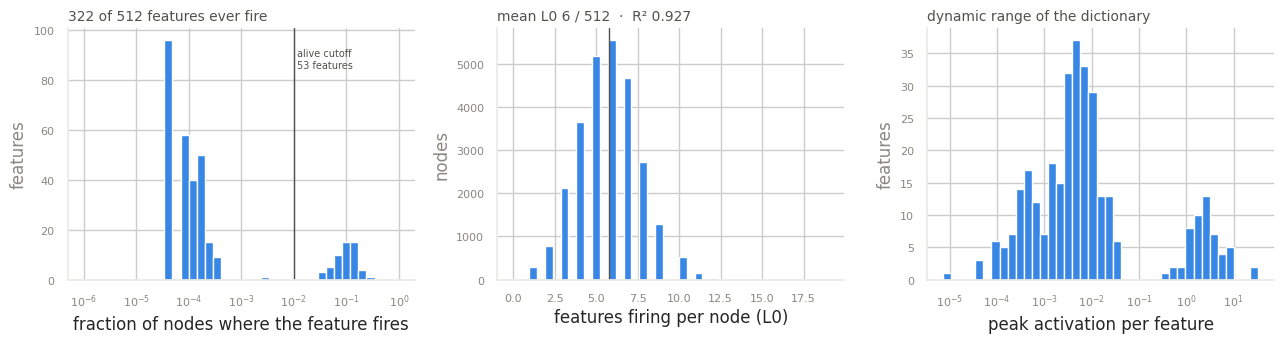

In [47]:
from gea_gene_nets.annotation_funcs import sae_health, plot_sae_health

health = {}
for level in ("node", "edge", "graph"):
    print(f"\n── {level}-level SAE ──")
    health[level] = sae_health(saes[level], NPZ[level], device=device, batch_size=8192)
plot_sae_health(health["node"])

## 19 — Node level: which genes is a feature about?

The concept dictionary comes from Enrichr (KEGG, Reactome, GO Biological Process by default), masked
against the atlas' own gene universe. `annotate_node_features` then scores every (feature, term) pair
**per graph**: it binarises activations at several relative thresholds, keeps the best threshold per
pair, and reports F1 together with the ceiling F1 that the sizes alone allow. Working per graph is
the point — a feature's F1 for a term is a per-disease measurement, and its spread across diseases is
what tells a general concept from one disease's quirk.

In [48]:
from gea_gene_nets.annotation_funcs import (fetch_gene_sets, geneSetAnnotation, gene_set_matrix,
                                            annotate_node_features, consensus_feature_terms,
                                            assign_feature_terms)

GENE_SET_LIBRARIES = ["KEGG_2021_Human", "Reactome_2022", "GO_Biological_Process_2023"]
TERM_MIN_GENES, TERM_MAX_GENES = 8, 300

gene_universe = sorted({g for gr in graphs for g in gr.gene_symbols})
gene_sets = fetch_gene_sets(libraries=GENE_SET_LIBRARIES, organism="Human")
term_masks = geneSetAnnotation(gene_universe, gene_sets,
                               min_genes=TERM_MIN_GENES, max_genes=TERM_MAX_GENES)
term_table = gene_set_matrix(term_masks, gene_universe)
print(f"\nconcept dictionary: {term_table.shape[1]:,} terms over {term_table.shape[0]:,} genes "
      f"| median term size {int(term_table.sum(axis=0).median())}")

KEGG_2021_Human: 320 terms
Reactome_2022: 1816 terms
GO_Biological_Process_2023: 5406 terms
Total: 7542 terms
4145/7542 terms with 8–300 of the 4806 genes (median 18 genes/term)

concept dictionary: 4,145 terms over 4,806 genes | median term size 18


In [49]:
node_records = annotate_node_features(
    saes["node"], NPZ["node"], term_table,
    device=device, group_cols=("disease",), top_k=5, min_f1=0.05,
)
node_consensus = consensus_feature_terms(node_records, min_support=0.10, min_mean_f1=0.10)
node_assigned = assign_feature_terms(node_consensus, min_score=0.0, min_support=0.10)

print(f"\n{node_records['feature'].nunique()} features scored | "
      f"{len(node_assigned)} carry an annotation above threshold")
print("\nBest-annotated node features:")
print(node_assigned.head(12).to_string(index=False))

Alive: 53/512 node features (firing in >= 1.0% of rows)
16,811 (graph, feature, term) records — 53 features, 2713 terms, 90 graphs

53 features scored | 51 carry an annotation above threshold

Best-annotated node features:
 feature                                                                     term    score  mean_f1    sd_f1  support  mean_f1_of_ceiling  mean_precision  mean_recall  mean_fold_enrichment  n_term_genes   margin  n_candidate_terms
      72 GO_Biological_Process_2023 | Cellular Response To Chemokine (GO:1990869) 0.605161 0.878459 0.098053 0.688889            0.985872        0.954689     0.833662             40.536909           9.5 0.016894                  8
     466                                KEGG_2021_Human | Cell adhesion molecules 0.433824 0.610065 0.110057 0.711111            0.728183        0.585475     0.675703             14.161789          18.5 0.264192                  9
     476                                KEGG_2021_Human | Cell adhesion molecules 0.

(<seaborn.matrix.ClusterGrid at 0x7f07d5c4ac90>,
 term     GO_Biological_Process_2023 | Apoptotic Mitochondrial Changes (GO:0008637)  \
 feature                                                                              
 13                                                0.246271                           
 37                                                0.000000                           
 40                                                0.000000                           
 72                                                0.000000                           
 85                                                0.000000                           
 146                                               0.000000                           
 148                                               0.000000                           
 150                                               0.000000                           
 257                                               0.000000                      

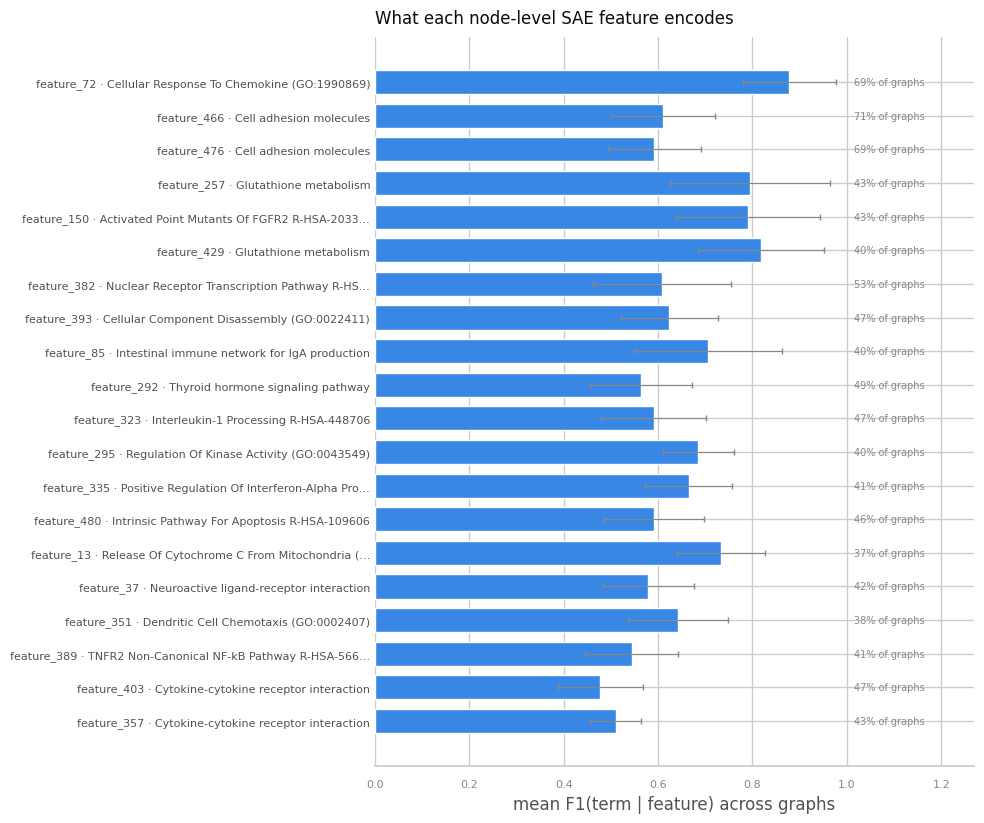

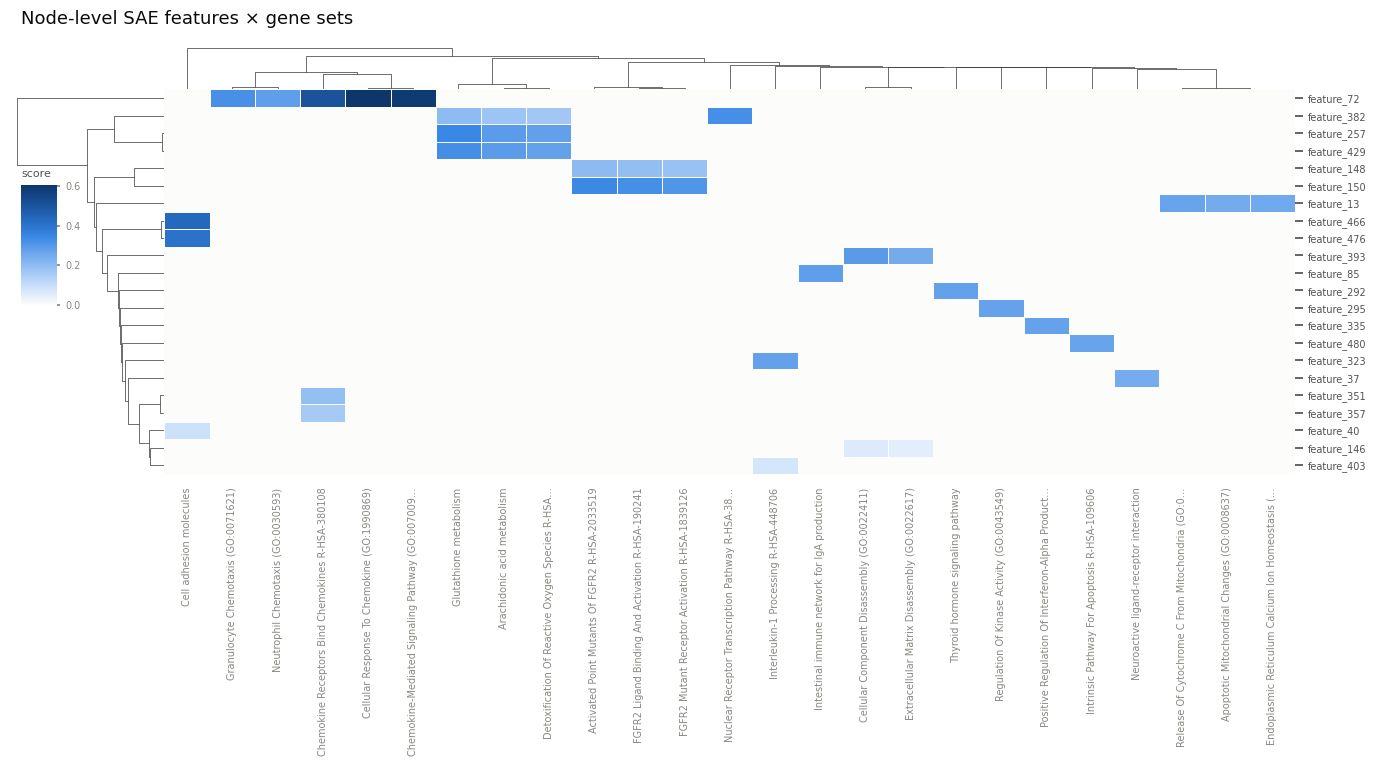

In [50]:
from gea_gene_nets.annotation_funcs import plot_feature_annotation_bars, plot_feature_term_heatmap

plot_feature_annotation_bars(node_assigned, top_n=20)
plot_feature_term_heatmap(node_consensus, value="score", n_features=30, n_terms=25)

## 20 — Edge level: which interactions is a feature about?

An edge is annotated with a term when **both** endpoints belong to it — the "this pair is wired
inside pathway X" reading that `annotate_edge_geneNets` encodes. That helper materialises one
dictionary of terms per edge, which for ~380 k edges is far more memory than the analysis needs, so
the same masks are built as a boolean matrix and scored with the same F1 rule used at the node level.

The baseline to keep in mind: a term's within-pathway edges are a small fraction of all edges, so a
feature that fires indiscriminately cannot score well — but a feature firing on very few edges can
score high by accident, which is why `min_active` is enforced.

In [51]:
from gea_gene_nets.annotation_funcs import feature_maxima

EDGE_THRESHOLDS = (0.15, 0.3, 0.5)
EDGE_MIN_ACTIVE = 25
EDGE_TOP_K = 3

edge_meta = load_embedding_metadata(NPZ["edge"])
terms_bool = term_table.to_numpy()
pos = {g: i for i, g in enumerate(term_table.index)}
both = (terms_bool[[pos[a] for a in edge_meta["gene_a"]]] &
        terms_bool[[pos[b] for b in edge_meta["gene_b"]]])        # [n_edges, n_terms]
keep_terms = both.sum(0) >= EDGE_MIN_ACTIVE
both, term_names = both[:, keep_terms], np.asarray(term_table.columns)[keep_terms]
print(f"{both.shape[0]:,} edges × {both.shape[1]:,} terms with ≥ {EDGE_MIN_ACTIVE} within-pathway edges")

maxima, fire_frac = feature_maxima(saes["edge"], datasets["edge"].embeddings,
                                   device=device, batch_size=8192)
maxima, fire_frac = maxima.cpu(), fire_frac.cpu()   # feature_maxima returns them on `device`
with torch.no_grad():
    acts = torch.cat([saes["edge"](b.to(device))[0].cpu()
                      for b in torch.split(datasets["edge"].embeddings, 8192)]).numpy()

rows = []
n_term = both.sum(0)
for f in np.where(fire_frac.numpy() >= 0.01)[0]:
    col = acts[:, f]
    for t in EDGE_THRESHOLDS:
        hit = col > t * maxima[f].item()
        n_act = int(hit.sum())
        if n_act < EDGE_MIN_ACTIVE:
            continue
        tp = both[hit].sum(0)
        f1 = 2 * tp / (n_act + n_term + 1e-12)
        j = int(np.argmax(f1))
        rows.append(dict(feature=int(f), term=term_names[j], f1=float(f1[j]),
                         precision=float(tp[j] / n_act), recall=float(tp[j] / n_term[j]),
                         threshold=t, n_active=n_act))

edge_annotated = (pd.DataFrame(rows).sort_values("f1", ascending=False)
                  .drop_duplicates("feature").head(200).reset_index(drop=True))
print(f"\n{edge_annotated['feature'].nunique()} edge features annotated; best ones:")
print(edge_annotated.head(12).to_string(index=False))

375,979 edges × 3,175 terms with ≥ 25 within-pathway edges

39 edge features annotated; best ones:
 feature                                                                                            term       f1  precision   recall  threshold  n_active
     389     GO_Biological_Process_2023 | Lymphocyte Activation Involved In Immune Response (GO:0002285) 0.816291   0.722393 0.938247       0.50       652
     363                                Reactome_2022 | Chemokine Receptors Bind Chemokines R-HSA-380108 0.660859   0.708801 0.618991       0.50      5886
     210                                                        KEGG_2021_Human | Glutathione metabolism 0.617521   0.515611 0.769640       0.50      1121
     292                                        KEGG_2021_Human | Cytokine-cytokine receptor interaction 0.599130   0.499703 0.747952       0.15     58839
     393             Reactome_2022 | Plasma Lipoprotein Assembly, Remodeling, And Clearance R-HSA-174824 0.567810   0.508296 0

## 21 — Graph level: which diseases does a feature stand for?

This is the level the whole dataset exists for. For every graph feature we have one activation per
disease, so a feature *is* a ranked list of diseases — and the question is whether that list is a
mechanism or a restatement of gene overlap.

Three things are computed here, in increasing order of how much they can tell you:

1. the activation map itself, clustered, with the disease category as a colour strip;
2. the diseases each live feature ranks highest;
3. **the control** — how much of the feature-space similarity between diseases is already explained
   by gene overlap, ESM composition and topology, the three references from section 15.

consistency check: 495/512 features never fire here — this must match the dead count section 18 reports for the same export
Alive: 12/512 features (500 dead, active in <5.0% of graphs)
12/512 graph features fire in ≥ 5% of diseases
Alive: 12/12 features (0 dead or constant, dropped)


(<seaborn.matrix.ClusterGrid at 0x7f08595801a0>,
 ['feature_1',
  'feature_58',
  'feature_134',
  'feature_148',
  'feature_150',
  'feature_183',
  'feature_330',
  'feature_373',
  'feature_429',
  'feature_442',
  'feature_466',
  'feature_504'])

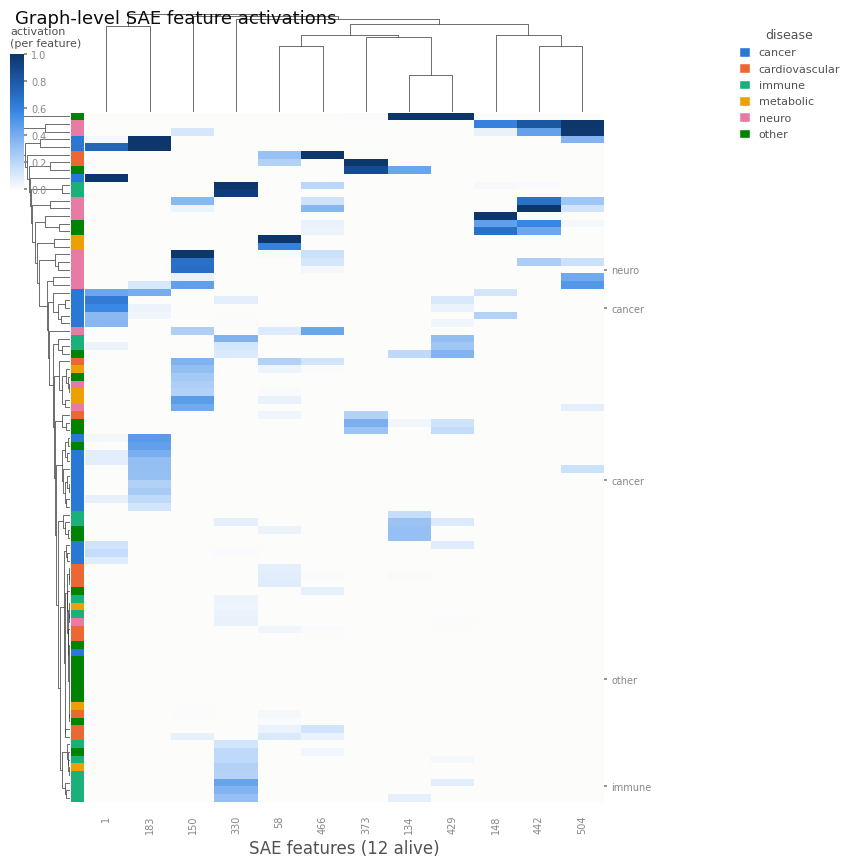

In [52]:
from gea.analysis import filter_dead_features, plot_sae_feature_clustermap

# Activations come from the *same* export section 18 scores, not from a second forward pass.
# Recomputing them live is what let a stale export disagree with sae_health — 477 features never
# firing there, 499 "alive" here, for the same dictionary.
with torch.no_grad():
    z_graph_sae, _ = saes["graph"](datasets["graph"].embeddings.to(device))
graph_acts = pd.DataFrame(z_graph_sae.cpu().numpy(),
                          columns=[f"feature_{i}" for i in range(SAE_DIMS["graph"])])
graph_acts["sample_name"] = [g.disease for g in graphs]
graph_acts["label"] = [g.category for g in graphs]
graph_acts["disease"] = graph_acts["label"]                       # category strip for the clustermap

never = int(((graph_acts.filter(like="feature_") > 0).mean() == 0).sum())
print(f"consistency check: {never}/{SAE_DIMS['graph']} features never fire here — this must match "
      f"the dead count section 18 reports for the same export")
live, feat_cols = filter_dead_features(graph_acts, min_activation_frac=0.05)
print(f"{len(feat_cols)}/{SAE_DIMS['graph']} graph features fire in ≥ 5% of diseases")

plot_sae_feature_clustermap(live, annotate=("disease",), min_activation_frac=0.05,
                            title="Graph-level SAE feature activations")

In [53]:
TOP_FEATURES, TOP_DISEASES = 8, 6

acts_mat = live[feat_cols].to_numpy()
names_by_row = graph_acts["sample_name"].tolist() if "sample_name" in graph_acts else \
               [g.disease for g in graphs]
cat_by_row = [g.category for g in graphs]

order = np.argsort(-(acts_mat > 0).sum(0))[:TOP_FEATURES]
for f in order:
    col = acts_mat[:, f]
    top = np.argsort(-col)[:TOP_DISEASES]
    frac = (col > 0).mean()
    cats = pd.Series([cat_by_row[i] for i in top]).value_counts()
    print(f"\n{feat_cols[f]}  (fires in {frac:.0%} of diseases, dominant category: "
          f"{cats.index[0]} {cats.iloc[0]}/{TOP_DISEASES})")
    for i in top:
        bar = "█" * int(round(20 * col[i] / (col.max() + 1e-12)))
        print(f"    {names_by_row[i][:44]:46s} {bar} {col[i]:.2f}")


feature_58  (fires in 24% of diseases, dominant category: cardiovascular 4/6)
    Familial hypercholesterolemia                  ████████████████████ 12.25
    Metabolic syndrome X                           ████████████ 7.34
    Long QT syndrome                               ██████ 3.72
    Abdominal aortic aneurysm                      █████ 2.79
    Hypertrophic cardiomyopathy                    █████ 2.78
    Dilated cardiomyopathy                         ██ 1.27

feature_330  (fires in 24% of diseases, dominant category: immune 6/6)
    Graves disease                                 ████████████████████ 5.43
    Sjogren's syndrome                             ███████████████████ 5.21
    Vitiligo                                       █████████ 2.40
    Ankylosing spondylitis                         ████████ 2.04
    Celiac disease                                 ███████ 2.02
    Systemic scleroderma                           ██████ 1.68

feature_466  (fires in 21% of diseases, domi

### The same map one level down: node embeddings

`h_G` is a mean over `h_i`, so the graph map of section 15 is a summary of this one. Four
annotations, each tied to a number established earlier: Four annotations, each tied to a number established earlier:

* **(a) concept** — the node-SAE feature each node fires on hardest, labelled with the gene set that
  feature was annotated with in section 19. If $h_i$ organises by biology at all, it shows here.
* **(b) disease category** — section 15 measured only ~11% of the variance in $h_i$ as *which graph
  the node sits in*, so this panel is expected to look like confetti. If it separates, that finding
  was wrong.
* **(c) degree** — whether hubs occupy their own region of the space.
* **(d) one protein, many diseases** — the copies of a single protein across every disease graph that
  contains it. Tight clusters are the 97% identity dominance made visible: the same protein lands in
  the same place no matter which disease it is embedded in.

UMAP over 20,000 of 27,033 node rows (4,198 distinct proteins)


/home/s243564/miniforge3/envs/gea/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


       IL6: appears in  68 graphs | mean distance from its own centroid 0.07
      IL10: appears in  63 graphs | mean distance from its own centroid 0.16
     TGFB1: appears in  62 graphs | mean distance from its own centroid 0.12
       ALB: appears in  61 graphs | mean distance from its own centroid 0.14
       CD4: appears in  59 graphs | mean distance from its own centroid 6.30
      IL1B: appears in  59 graphs | mean distance from its own centroid 0.13


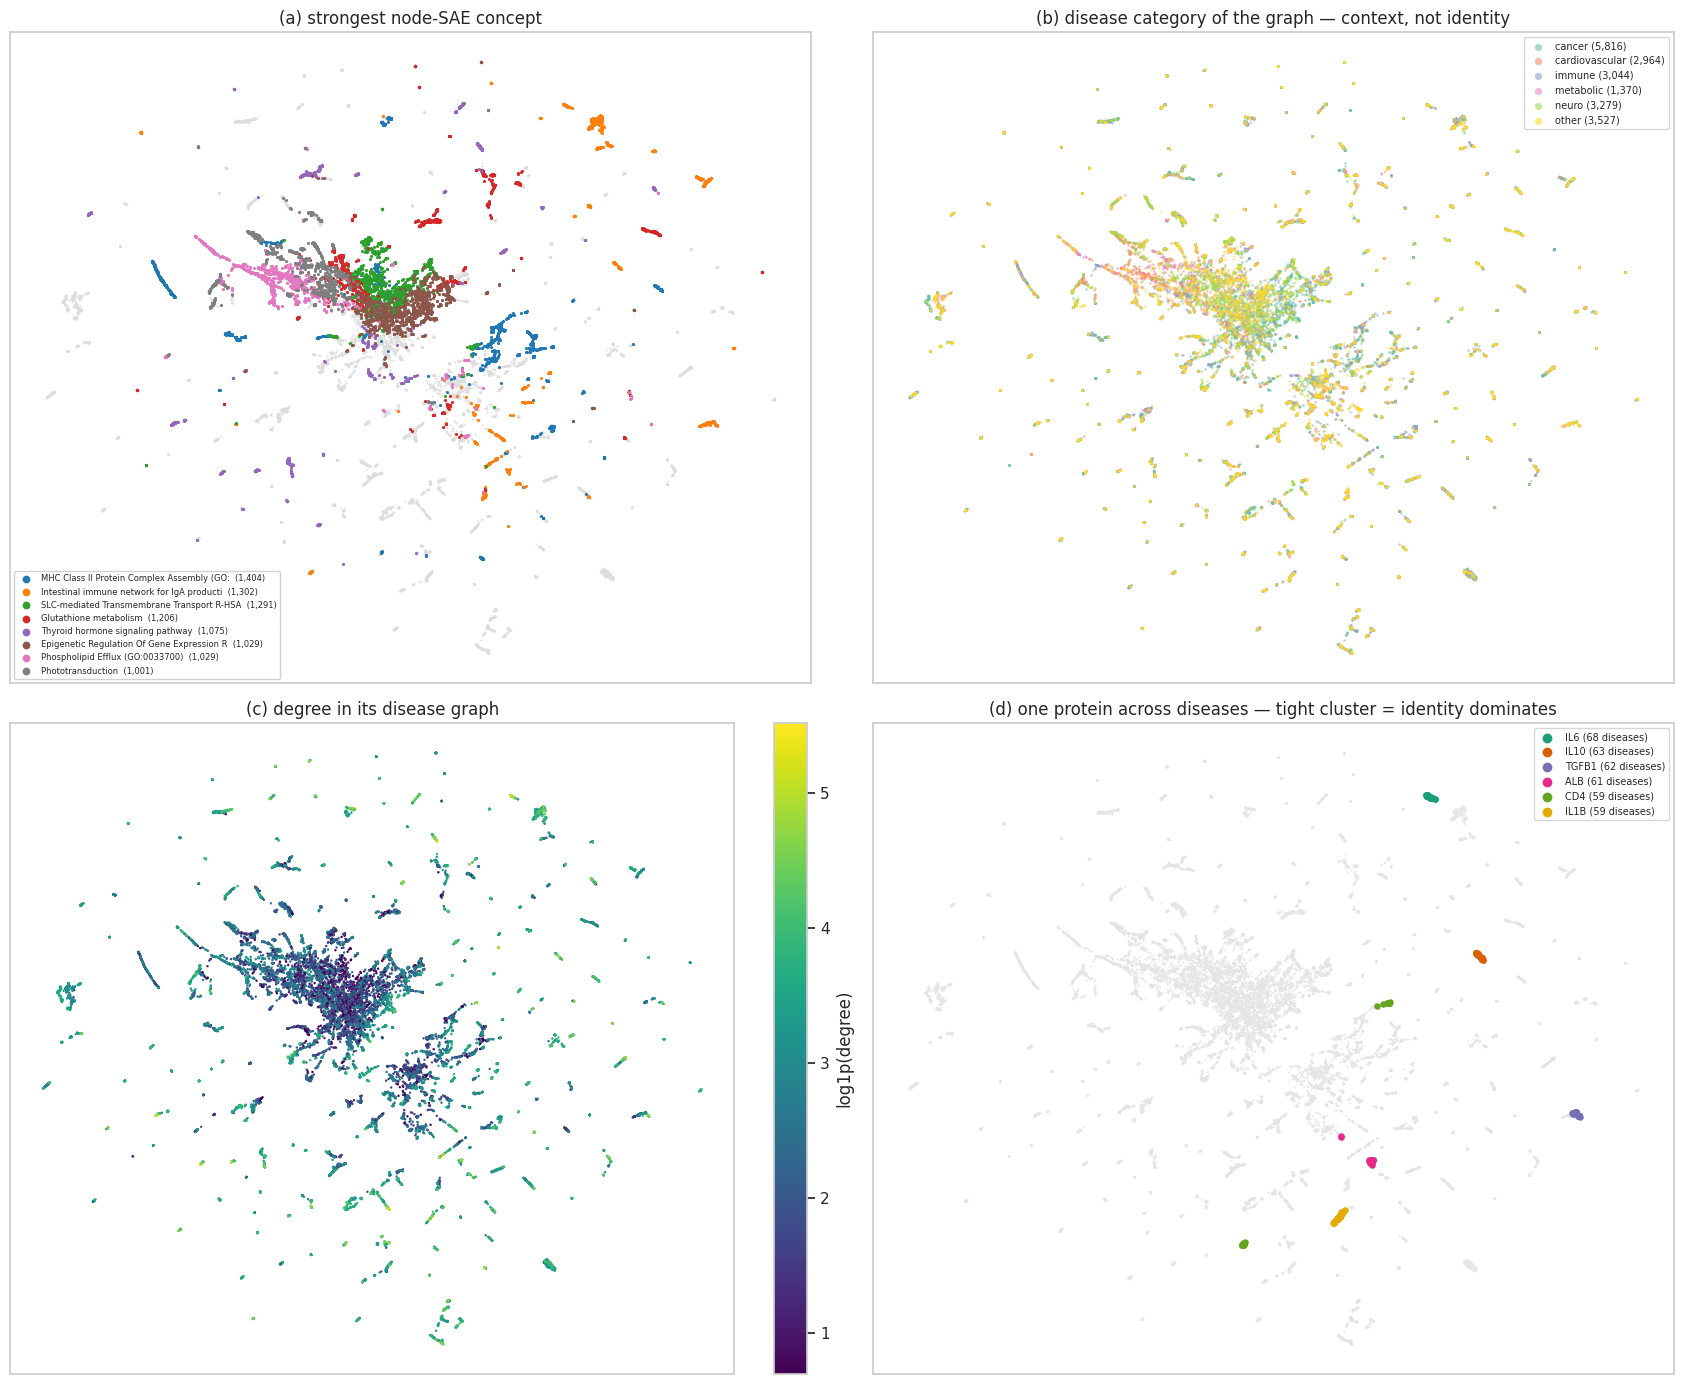

In [96]:
# Node-level embedding map. Four annotations, each answering a question the numbers already raised:
#   (a) the SAE concept a node fires on   — does h_i organise by gene set at all?
#   (b) the disease its graph describes   — section 15 measured only ~11% of h_i variance as graph
#                                            context, so this panel should look unstructured
#   (c) degree                            — do hubs occupy their own region?
#   (d) one protein, many diseases        — makes the 97% identity dominance visible
MAX_NODES = 20_000
N_CONCEPTS, N_PROTEINS = 8, 6

sub = np.random.default_rng(SEED).choice(len(node_meta), min(MAX_NODES, len(node_meta)), replace=False)
sub.sort()
meta_s = node_meta.iloc[sub].reset_index(drop=True)
X_node = datasets["node"].embeddings[sub]

with torch.no_grad():
    acts_node = saes["node"](X_node.to(device))[0].cpu().numpy()
peak = acts_node.max(1)
top_feat = acts_node.argmax(1)

feat_term = node_assigned.set_index("feature")["term"].to_dict()
concept = np.array([feat_term.get(int(f), "unannotated feature") if p > 0 else "silent"
                    for f, p in zip(top_feat, peak)])
keep_terms = [t for t, _ in pd.Series(concept).value_counts().items()
              if t not in ("silent", "unannotated feature")][:N_CONCEPTS]
concept_plot = np.where(np.isin(concept, keep_terms), concept, "other / silent")

cat_of_graph = graph_meta.set_index("graph_id")["category"].to_dict()
node_cat = meta_s["graph_id"].map(cat_of_graph).to_numpy()

print(f"UMAP over {len(sub):,} of {len(node_meta):,} node rows "
      f"({meta_s['gene'].nunique():,} distinct proteins)")
node_coords = UMAP(n_components=2, random_state=SEED, n_neighbors=25, min_dist=0.1).fit_transform(
    StandardScaler().fit_transform(X_node.numpy()))

fig, axes = plt.subplots(2, 2, figsize=(17, 14))

# (a) concept
ax0 = axes[0, 0]
pal = dict(zip(keep_terms, sns.color_palette("tab10", len(keep_terms))))
rest = concept_plot == "other / silent"
ax0.scatter(node_coords[rest, 0], node_coords[rest, 1], s=2, color="#dddddd", linewidths=0, zorder=1)
for term in keep_terms:
    m = concept_plot == term
    ax0.scatter(node_coords[m, 0], node_coords[m, 1], s=5, color=pal[term], linewidths=0, zorder=2,
                label=f"{term.split(' | ')[-1][:42]}  ({m.sum():,})")
ax0.legend(fontsize=6, markerscale=2.5, loc="best", framealpha=0.9)
ax0.set(title="(a) strongest node-SAE concept", xticks=[], yticks=[])

# (b) disease category of the graph the node belongs to
ax1 = axes[0, 1]
for cat in sorted(set(node_cat)):
    m = node_cat == cat
    ax1.scatter(node_coords[m, 0], node_coords[m, 1], s=3, linewidths=0,
                color=CATEGORY_PALETTE[cat], alpha=0.6, label=f"{cat} ({m.sum():,})")
ax1.legend(fontsize=7, markerscale=3)
ax1.set(title="(b) disease category of the graph — context, not identity", xticks=[], yticks=[])

# (c) degree
ax2 = axes[1, 0]
deg = np.log1p(meta_s["degree"].to_numpy())
sc = ax2.scatter(node_coords[:, 0], node_coords[:, 1], s=3, c=deg, cmap="viridis", linewidths=0)
plt.colorbar(sc, ax=ax2, fraction=0.046, label="log1p(degree)")
ax2.set(title="(c) degree in its disease graph", xticks=[], yticks=[])

# (d) the same protein, seen in many diseases
ax3 = axes[1, 1]
recurrent = meta_s["gene"].value_counts().head(N_PROTEINS).index.tolist()
ax3.scatter(node_coords[:, 0], node_coords[:, 1], s=2, color="#e5e5e5", linewidths=0, zorder=1)
for g, colour in zip(recurrent, sns.color_palette("Dark2", N_PROTEINS)):
    m = (meta_s["gene"] == g).to_numpy()
    ax3.scatter(node_coords[m, 0], node_coords[m, 1], s=22, color=colour, linewidths=0, zorder=3,
                label=f"{g} ({m.sum()} diseases)")
    spread = np.linalg.norm(node_coords[m] - node_coords[m].mean(0), axis=1).mean()
    print(f"  {g:>8}: appears in {m.sum():>3} graphs | mean distance from its own centroid {spread:.2f}")
ax3.legend(fontsize=7, markerscale=1.5)
ax3.set(title="(d) one protein across diseases — tight cluster = identity dominates", xticks=[], yticks=[])

plt.tight_layout(); plt.show()

In [44]:
from scipy.stats import spearmanr

# The control: is feature-space similarity anything more than gene overlap / composition / topology?
def cos_sim(X):
    Xn = X / np.linalg.norm(X, axis=1, keepdims=True).clip(1e-9)
    return Xn @ Xn.T

def upper(m):
    return m[np.triu_indices_from(m, k=1)]

sim_feat = cos_sim(acts_mat)
refs = {"gene overlap (Jaccard)": J, "ESM composition": cos_sim(MU),
        "topology similarity": topo_sim, "h_G itself": sim_h}
rows = [dict(reference=k, spearman_rho=round(spearmanr(upper(sim_feat), upper(v))[0], 3))
        for k, v in refs.items()]
print("── similarity of SAE graph-feature activations vs independent references ──")
print(pd.DataFrame(rows).to_string(index=False))
print("\nA feature space that only reproduces the first two rows has re-described the gene lists.")

# Residual test: regress the composition similarity out and see what survives.
x, y = upper(cos_sim(MU)), upper(sim_feat)
resid = y - np.polyval(np.polyfit(x, y, 1), x)
rho_topo_resid = spearmanr(resid, upper(topo_sim))[0]
print(f"\nafter regressing out ESM-composition similarity, the residual feature similarity still "
      f"correlates {rho_topo_resid:.3f} with topology")

── similarity of SAE graph-feature activations vs independent references ──
             reference  spearman_rho
gene overlap (Jaccard)         0.254
       ESM composition         0.330
   topology similarity         0.103
            h_G itself         0.562

A feature space that only reproduces the first two rows has re-described the gene lists.

after regressing out ESM-composition similarity, the residual feature similarity still correlates -0.203 with topology


In [45]:
# A first look at the hierarchy: for the strongest graph feature, which node features fire in the
# diseases it selects, and what are those node features about?
f = int(order[0])
sel = np.argsort(-acts_mat[:, f])[:TOP_DISEASES]
sel_names = {names_by_row[i] for i in sel}

node_acts_by_feature = (node_records[node_records["graph_id"].isin(sel_names)]
                        .groupby(["feature", "term"])
                        .agg(mean_f1=("f1", "mean"), graphs=("graph_id", "nunique"))
                        .reset_index()
                        .sort_values(["graphs", "mean_f1"], ascending=False))
print(f"Node-level concepts recurring in the diseases that {feat_cols[f]} selects "
      f"({', '.join(sorted(sel_names))[:110]}…):\n")
print(node_acts_by_feature.head(12).to_string(index=False))

Node-level concepts recurring in the diseases that feature_58 selects (Abdominal aortic aneurysm, Dilated cardiomyopathy, Familial hypercholesterolemia, Hypertrophic cardiomyopathy,…):

 feature                                                                                     term  mean_f1  graphs
      85                           KEGG_2021_Human | Intestinal immune network for IgA production 0.885714       3
     501                              Reactome_2022 | Plasma Lipoprotein Remodeling R-HSA-8963899 0.882448       3
     501      Reactome_2022 | Plasma Lipoprotein Assembly, Remodeling, And Clearance R-HSA-174824 0.863890       3
     293      Reactome_2022 | Plasma Lipoprotein Assembly, Remodeling, And Clearance R-HSA-174824 0.854639       3
     293                                Reactome_2022 | Transport Of Small Molecules R-HSA-382551 0.825926       3
     442       GO_Biological_Process_2023 | Inorganic Cation Transmembrane Transport (GO:0098662) 0.801190       3
     442 

## 22 — Held-out annotation: which concepts survive a validation/test split?

Every F1 reported so far is in-sample: the SAE saw all the rows it is then annotated on. This section
does it properly, in the layout the molecular GEA figure uses — each feature's concept **chosen on a
validation set** and its F1 **re-measured on a test set** it never influenced.

The split is by **graph**, not by row: nodes of the same disease are anything but independent, and
the same protein recurs across graphs, so a random row split would leak both ways. It reuses the
encoder's own partition, which makes the test set doubly held out:

| split | graphs | seen by the GCN | seen by the SAE |
|---|---|---|---|
| train | 80% of the GCN's training graphs | yes | yes |
| validation | 20% of the GCN's training graphs | yes | no |
| **test** | the GCN's validation graphs | **no** | **no** |

Only mean F1 is reported, per the figure being reproduced; the per-graph spread is in
`node_records_split` if you want error bars later.

In [57]:
from torch.utils.data import Dataset as TorchDataset

SPLIT_VAL_FRAC = 0.2
SPLIT_SAE_CKPT = {lvl: DATA_DIR / f"sae_{lvl}_split_{ATLAS_TAG}.pt" for lvl in ("node", "edge")}

_ck = torch.load(GCN_CKPT, map_location="cpu", weights_only=False)
gnn_train, gnn_val = np.array(_ck["split"]["train"]), np.array(_ck["split"]["val"])
_perm = np.random.default_rng(SEED).permutation(gnn_train)
_n_val = max(1, int(round(SPLIT_VAL_FRAC * len(_perm))))
split_of_graph = {}
for j in _perm[_n_val:]:
    split_of_graph[graphs[j].disease] = "train"
for j in _perm[:_n_val]:
    split_of_graph[graphs[j].disease] = "val"
for j in gnn_val:
    split_of_graph[graphs[j].disease] = "test"

edge_meta = edge_meta if "edge_meta" in dir() else load_embedding_metadata(NPZ["edge"])
row_split = {"node": node_meta["graph_id"].map(split_of_graph).to_numpy(),
             "edge": edge_meta["graph_id"].map(split_of_graph).to_numpy()}
print(pd.Series(list(split_of_graph.values())).value_counts().rename("graphs").to_string())
for lvl in ("node", "edge"):
    print(f"{lvl:>5} rows — " + ", ".join(f"{s}: {(row_split[lvl] == s).sum():,}"
                                          for s in ("train", "val", "test")))

train    58
test     18
val      14
 node rows — train: 16,679, val: 5,028, test: 5,326
 edge rows — train: 230,566, val: 72,105, test: 73,308


In [58]:
class RowsDataset(TorchDataset):
    # train_sae reads batch["embedding"], so wrap the selected rows in that layout.
    def __init__(self, emb): self.emb = emb
    def __len__(self): return len(self.emb)
    def __getitem__(self, i): return {"embedding": self.emb[i]}


split_saes = {}
for level in ("node", "edge"):
    rows = np.where(row_split[level] == "train")[0]
    X_train = datasets[level].embeddings[rows]
    want = fingerprint(NPZ_FP[level], SAE_DIMS[level], SAE_SPARSITY[level], SAE_EPOCHS[level],
                       SAE_BATCH[level], SEED, "train-split", len(rows))
    blob = (torch.load(SPLIT_SAE_CKPT[level], map_location="cpu", weights_only=False)
            if SPLIT_SAE_CKPT[level].exists() else None)
    set_seed(SEED)
    sae = ShallowSAE(X_train.shape[1], SAE_DIMS[level], sparsity_weight=SAE_SPARSITY[level])
    if isinstance(blob, dict) and blob.get("fp") == want:
        sae.load_state_dict(blob["state_dict"])
        print(f"{level:>5}: cached → {SPLIT_SAE_CKPT[level].name}  [{want}]")
    else:
        print(f"{level:>5}: training on {len(rows):,} train-split rows "
              f"({X_train.shape[1]} → {SAE_DIMS[level]})")
        loader = TorchLoader(RowsDataset(X_train), batch_size=SAE_BATCH[level], shuffle=True)
        train_sae(sae, loader, device, epochs=SAE_EPOCHS[level], lr=SAE_LR, w_l2=0)
        torch.save({"state_dict": sae.state_dict(), "fp": want}, SPLIT_SAE_CKPT[level])
    split_saes[level] = sae.to(device).eval()

 node: training on 16,679 train-split rows (128 → 512)


Training SAE model: 100%|██████████| 1800/1800 [00:18<00:00, 97.00it/s, epoch=199/201, total_loss=0.0602] 


 edge: training on 230,566 train-split rows (128 → 512)


Training SAE model: 100%|██████████| 1710/1710 [00:40<00:00, 41.95it/s, epoch=29/31, total_loss=0.0506]


In [59]:
# ── node level: score every (graph, feature, term), then read validation and test separately ──
node_records_split = annotate_node_features(
    split_saes["node"], NPZ["node"], term_table,
    device=device, group_cols=("disease",), top_k=5, min_f1=0.0,
)
node_records_split["split"] = node_records_split["graph_id"].map(split_of_graph)

val_consensus = consensus_feature_terms(node_records_split[node_records_split["split"] == "val"],
                                        min_support=0.10, min_mean_f1=0.10)
val_assigned = assign_feature_terms(val_consensus, min_score=0.0, min_support=0.10)

test_mean = (node_records_split[node_records_split["split"] == "test"]
             .groupby(["feature", "term"])["f1"].mean())
node_table = val_assigned.assign(
    level="node",
    f1_val=val_assigned["mean_f1"],
    f1_test=[test_mean.get((f, t), np.nan) for f, t in zip(val_assigned["feature"], val_assigned["term"])],
)[["level", "feature", "term", "f1_val", "f1_test", "support"]]
print(f"{len(node_table)} node features annotated on validation; "
      f"{node_table['f1_test'].notna().sum()} of them also fire in the test graphs")

Alive: 54/512 node features (firing in >= 1.0% of rows)


/home/s243564/gea/src/gea_gene_nets/annotation_funcs.py:674: RuntimeWarning: invalid value encountered in divide
  f1_ceiling = 2 * np.minimum(n_active, n_term_genes) / (n_active + n_term_genes)
/home/s243564/gea/src/gea_gene_nets/annotation_funcs.py:674: RuntimeWarning: invalid value encountered in divide
  f1_ceiling = 2 * np.minimum(n_active, n_term_genes) / (n_active + n_term_genes)
/home/s243564/gea/src/gea_gene_nets/annotation_funcs.py:674: RuntimeWarning: invalid value encountered in divide
  f1_ceiling = 2 * np.minimum(n_active, n_term_genes) / (n_active + n_term_genes)
/home/s243564/gea/src/gea_gene_nets/annotation_funcs.py:674: RuntimeWarning: invalid value encountered in divide
  f1_ceiling = 2 * np.minimum(n_active, n_term_genes) / (n_active + n_term_genes)
/home/s243564/gea/src/gea_gene_nets/annotation_funcs.py:674: RuntimeWarning: invalid value encountered in divide
  f1_ceiling = 2 * np.minimum(n_active, n_term_genes) / (n_active + n_term_genes)
/home/s243564/gea/src/gea

24,300 (graph, feature, term) records — 54 features, 2601 terms, 90 graphs
54 node features annotated on validation; 50 of them also fire in the test graphs


In [60]:
# ── edge level: same idea, vectorised (an edge belongs to a term when both endpoints do) ──
EDGE_MAX_TERMS = 400
EDGE_MIN_ACTIVE_SPLIT = 15

pos_idx = {g: i for i, g in enumerate(term_table.index)}
both_all = (term_table.to_numpy()[[pos_idx[a] for a in edge_meta["gene_a"]]] &
            term_table.to_numpy()[[pos_idx[b] for b in edge_meta["gene_b"]]])
order_terms = np.argsort(-both_all.sum(0))[:EDGE_MAX_TERMS]
both_all, edge_terms = both_all[:, order_terms], np.asarray(term_table.columns)[order_terms]

@torch.no_grad()
def edge_activations(sae, rows, chunk=65536):
    out = []
    for s in range(0, len(rows), chunk):
        x = datasets["edge"].embeddings[rows[s:s + chunk]].to(device)
        out.append(sae(x)[0].cpu())
    return torch.cat(out).numpy()


def edge_f1(acts, mask, thresholds=(0.15, 0.3, 0.5), maxima=None):
    # best (term, threshold) per feature, by F1, over the rows given
    n_term = mask.sum(0)
    best = {}
    for t in thresholds:
        hit = acts > t * maxima
        n_act = hit.sum(0)
        tp = hit.T.astype(np.float32) @ mask.astype(np.float32)
        f1 = 2 * tp / (n_act[:, None] + n_term[None, :] + 1e-12)
        for f in range(acts.shape[1]):
            if n_act[f] < EDGE_MIN_ACTIVE_SPLIT:
                continue
            j = int(np.argmax(f1[f]))
            if f not in best or f1[f, j] > best[f][1]:
                best[f] = (edge_terms[j], float(f1[f, j]), t, int(n_act[f]))
    return best


rows_val = np.where(row_split["edge"] == "val")[0]
rows_test = np.where(row_split["edge"] == "test")[0]
acts_val, acts_test = edge_activations(split_saes["edge"], rows_val), edge_activations(split_saes["edge"], rows_test)
maxima_edge = np.maximum(acts_val.max(0), 1e-9)

best_val = edge_f1(acts_val, both_all[rows_val], maxima=maxima_edge)
n_term_test = both_all[rows_test].sum(0)
term_pos = {t: i for i, t in enumerate(edge_terms)}

rows_out = []
for f, (term, f1v, thr, n_act) in best_val.items():
    hit = acts_test[:, f] > thr * maxima_edge[f]
    tp = float((hit[:, None] & both_all[rows_test][:, [term_pos[term]]]).sum())
    denom = hit.sum() + n_term_test[term_pos[term]]
    rows_out.append(dict(level="edge", feature=f, term=term, f1_val=f1v,
                         f1_test=(2 * tp / denom if denom else np.nan), support=np.nan))
edge_table = pd.DataFrame(rows_out)
print(f"{len(edge_table)} edge features annotated on validation")

247 edge features annotated on validation


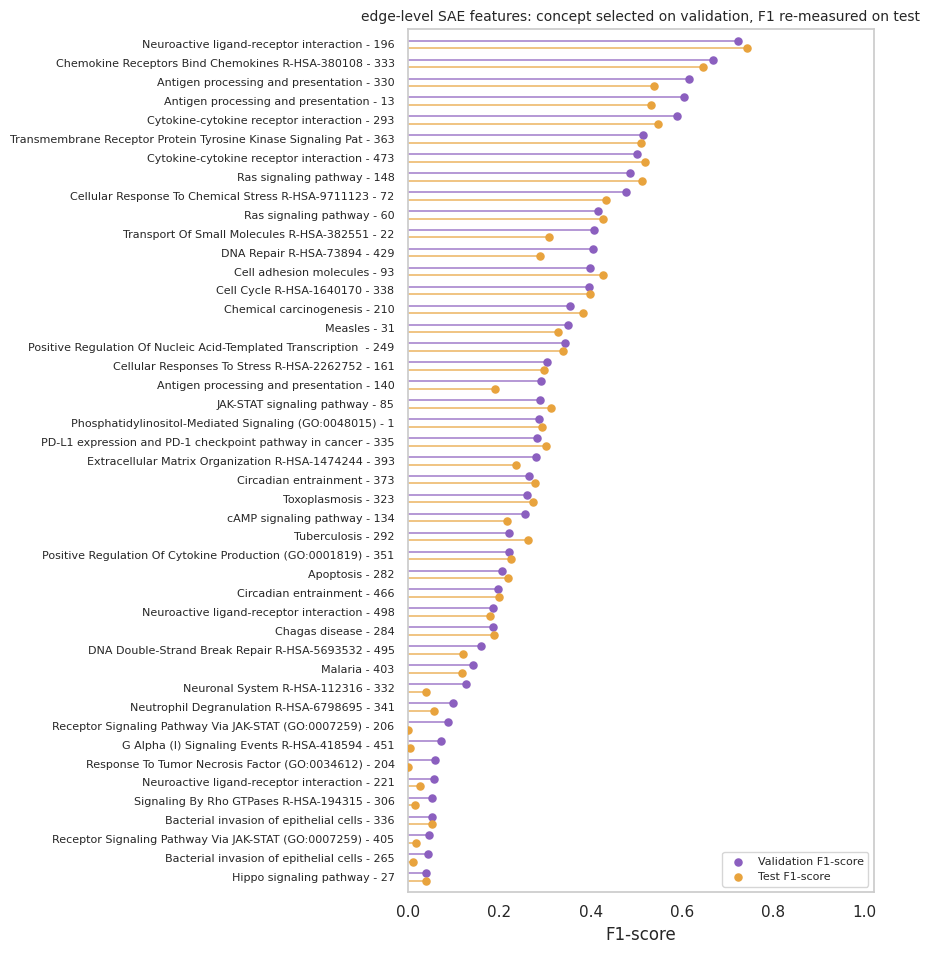

median validation → test change: -0.009 (0 of 45 features lose more than 0.2)


In [79]:
# ── the figure: concept + feature, two stems per feature (validation above test) ──
TOP_N = 45
LEVEL = "edge"          # "node" | "edge"
ROW_OFFSET = 0.2       # vertical separation of the two stems within one row

tbl = (node_table if LEVEL == "node" else edge_table).dropna(subset=["f1_val"]).copy()
tbl = tbl.sort_values("f1_val", ascending=False).head(TOP_N).iloc[::-1]
labels = [f"{str(t).split(' | ')[-1][:60]} - {int(f)}" for t, f in zip(tbl["term"], tbl["feature"])]
y = np.arange(len(tbl), dtype=float)
val, test = tbl["f1_val"].to_numpy(), tbl["f1_test"].to_numpy()
scored = ~np.isnan(test)

fig, ax = plt.subplots(figsize=(9, 0.34 * len(tbl) - 5.6))
ax.hlines(y + ROW_OFFSET, 0, val, color="#8b5fbf", lw=1.2, alpha=0.75, zorder=1)
ax.hlines(y[scored] - ROW_OFFSET, 0, test[scored], color="#e8a33d", lw=1.2, alpha=0.75, zorder=1)
ax.scatter(val, y + ROW_OFFSET, s=26, color="#8b5fbf", zorder=3, label="Validation F1-score")
ax.scatter(test[scored], y[scored] - ROW_OFFSET, s=26, color="#e8a33d", zorder=3,
           label="Test F1-score")
# if (~scored).any():
#     ax.scatter(np.zeros((~scored).sum()), y[~scored] - ROW_OFFSET, s=18, marker="x",
#                color="#b0b0b0", zorder=3, label="never fires in the test graphs")

ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=8)
ax.set_ylim(-0.8, len(tbl) - 0.2)
ax.set_xlabel("F1-score")
ax.set_xlim(0, 1.02)
ax.legend(loc="lower right", fontsize=8, frameon=True)

# Remove the background grid lines
ax.grid(False)
ax.set_axisbelow(False)

ax.set_title(f"{LEVEL}-level SAE features: concept selected on validation, F1 re-measured on test",
             fontsize=10)
plt.tight_layout()
plt.show()

delta = (tbl["f1_test"] - tbl["f1_val"]).dropna()
print(f"median validation → test change: {delta.median():+.3f} "
      f"({(delta < -0.2).sum()} of {len(delta)} features lose more than 0.2)")

## 23 — Where a feature fires: subgraph views

The molecular version of GEA can draw a whole molecule and colour the atoms a feature fires on. A
disease graph has 200–1000 nodes and thousands of edges, so the equivalent picture has to be
*local*: take the handful of nodes (or edges) carrying the activation, pull in one hop of context so
the wiring is visible, and draw only that.

Each panel is one **validated** feature from section 22 — concept chosen on validation graphs — shown
in the disease where it fires hardest. Node colour is the feature's activation scaled by its global
maximum, so the 0–1 scale means the same thing in every panel, and grey nodes are the context hop:
present in the network, silent for this feature.

The same helper draws edge-level features, where the activation lives on the interaction rather than
the protein — that is the picture that has no molecular analogue, and the one that says "this feature
is about *this wiring*, not about these genes".

In [85]:
import matplotlib.patheffects as pe
import networkx as nx

PANEL_FEATURES = 6          # panels in the grid
SEED_NODES     = 12         # highest-activating nodes kept per panel
CONTEXT_HOPS   = 1          # hops of surrounding network drawn in grey
MAX_PANEL_NODES = 38        # hard cap so a hub does not drag in the whole graph
ACT_CMAP = "coolwarm"

# Row ranges per graph — the export was written graph by graph, in `graphs` order.
def row_blocks(meta):
    blocks, start = {}, 0
    for gid, n in meta.groupby("graph_id", sort=False).size().items():
        blocks[gid] = (start, start + n)
        start += n
    return blocks


node_blocks = row_blocks(node_meta)
edge_blocks = row_blocks(edge_meta)
graph_by_name = {g.disease: g for g in graphs}


@torch.no_grad()
def feature_column(level, feature, sae, chunk=65536):
    # One feature's activation over every row of that level, without materialising 512 columns.
    emb = datasets[level].embeddings
    out = []
    for s in range(0, len(emb), chunk):
        out.append(sae(emb[s:s + chunk].to(device))[0][:, feature].cpu())
    return torch.cat(out).numpy()

In [86]:
MAX_LABELS = 12          # gene names drawn per panel — more than this and they collide regardless


def place_labels(ax, pos, labels):
    # Repel the gene names off each other and off the nodes; without this the hubs of a dense
    # subgraph end up with three names stacked on the same point.
    xs = np.array([p[0] for p in pos.values()]); ys = np.array([p[1] for p in pos.values()])
    texts = [ax.text(*pos[n], name, fontsize=6.5, zorder=5,
                     path_effects=[pe.withStroke(linewidth=2, foreground="white")])
             for n, name in labels.items()]
    try:
        from adjustText import adjust_text
        adjust_text(texts, x=xs, y=ys, ax=ax, expand=(1.25, 1.5), force_text=(0.4, 0.7),
                    arrowprops=dict(arrowstyle="-", color="0.6", lw=0.4))
    except ImportError:
        pass


def rank_graphs(acts, blocks, exclude=()):
    # Graphs ordered by how hard the feature fires in them, strongest few rows first. Panels claim
    # a disease exclusively, so a feature that peaks in an already-shown graph falls to its next one.
    score = {gid: float(np.sort(acts[slice(*rng)])[-5:].mean()) for gid, rng in blocks.items()}
    order = sorted(score, key=lambda g: -score[g])
    pick = next((g for g in order if g not in exclude), order[0])
    return pick, score[pick], score[order[0]]


def node_panel(ax, feature, sae, exclude=(), cmap=ACT_CMAP):
    acts = feature_column("node", feature, sae)
    scale = max(acts.max(), 1e-9)

    best, got, top = rank_graphs(acts, node_blocks, exclude)
    if got < 0.75 * top:
        print(f"  feature {feature}: peaks in an already-shown disease; using {best} instead "
              f"({got / max(top, 1e-9):.0%} of its peak activation)")
    lo, hi = node_blocks[best]
    a = acts[lo:hi] / scale
    g = graph_by_name[best]

    seeds = list(np.argsort(-a)[:SEED_NODES])
    G = nx.Graph()
    ei = g.edge_index.numpy()
    G.add_nodes_from(range(g.num_nodes))
    G.add_weighted_edges_from(zip(ei[0], ei[1], g.edge_attr.numpy()))
    keep = set(seeds)
    for _ in range(CONTEXT_HOPS):
        for n in list(keep):
            keep |= set(G.neighbors(n))
            if len(keep) > MAX_PANEL_NODES:
                break
    keep = set(sorted(keep, key=lambda n: -a[n])[:MAX_PANEL_NODES])
    H = G.subgraph(keep)
    H = H.subgraph(max(nx.connected_components(H), key=len))

    pos = nx.spring_layout(H, weight="weight", seed=SEED, k=0.6)
    nx.draw_networkx_edges(H, pos, ax=ax, alpha=0.25, width=0.8, edge_color="0.4")
    nodes = list(H)
    nx.draw_networkx_nodes(H, pos, ax=ax, nodelist=nodes, node_size=[70 + 520 * a[n] for n in nodes],
                           node_color=[a[n] for n in nodes], cmap=cmap, vmin=0, vmax=1,
                           linewidths=0.4, edgecolors="0.35")
    ranked = sorted(nodes, key=lambda n: -a[n])[:MAX_LABELS]
    place_labels(ax, pos, {n: g.gene_symbols[n] for n in ranked})
    ax.set_axis_off()
    return best, H.number_of_nodes(), float(a[seeds].mean())


def edge_panel(ax, feature, sae, exclude=(), cmap=ACT_CMAP):
    acts = feature_column("edge", feature, sae)
    scale = max(acts.max(), 1e-9)
    best, got, top = rank_graphs(acts, edge_blocks, exclude)
    if got < 0.75 * top:
        print(f"  feature {feature}: peaks in an already-shown disease; using {best} instead "
              f"({got / max(top, 1e-9):.0%} of its peak activation)")
    lo, hi = edge_blocks[best]
    a = acts[lo:hi] / scale
    rows = edge_meta.iloc[lo:hi]
    g = graph_by_name[best]

    top = np.argsort(-a)[:SEED_NODES * 2]
    H = nx.Graph()
    for k in top:
        H.add_edge(rows["gene_a"].iat[int(k)], rows["gene_b"].iat[int(k)], act=float(a[k]))
    if H.number_of_nodes() > MAX_PANEL_NODES:
        H = H.subgraph(sorted(H, key=lambda n: -max(d["act"] for _, _, d in H.edges(n, data=True)))
                       [:MAX_PANEL_NODES])
    pos = nx.spring_layout(H, seed=SEED, k=0.6)
    w = [H[u][v]["act"] for u, v in H.edges()]
    nx.draw_networkx_edges(H, pos, ax=ax, edge_color=w, edge_cmap=plt.get_cmap(cmap),
                           edge_vmin=0, edge_vmax=1, width=2.0)
    nx.draw_networkx_nodes(H, pos, ax=ax, node_size=90, node_color="white",
                           linewidths=0.6, edgecolors="0.4")
    strength = {n: max(d["act"] for _, _, d in H.edges(n, data=True)) for n in H}
    ranked = sorted(H, key=lambda n: -strength[n])[:MAX_LABELS]
    place_labels(ax, pos, {n: n for n in ranked})
    ax.set_axis_off()
    return best, H.number_of_edges(), float(a[top].mean())

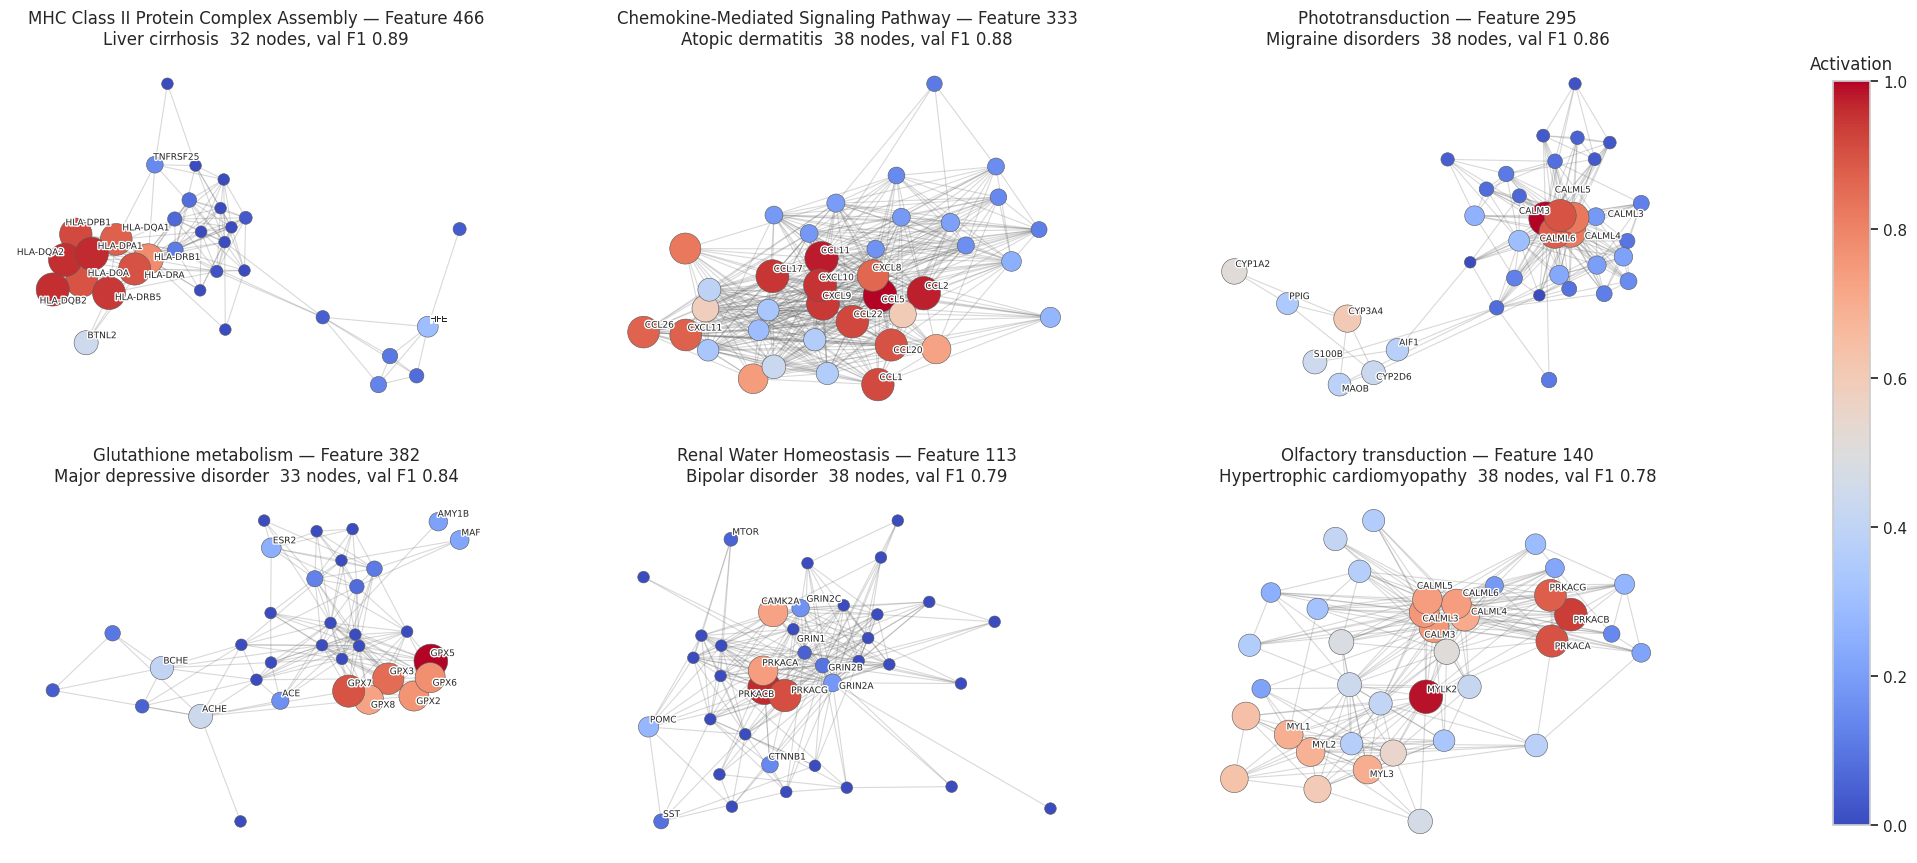

In [95]:
LEVEL_PANEL = "node"        # "node" | "edge"

UNIQUE_CONCEPTS = True   # several features often split one concept; show distinct concepts instead

table = (node_table if LEVEL_PANEL == "node" else edge_table).dropna(subset=["f1_val"])
picks = table.sort_values("f1_val", ascending=False).drop_duplicates("feature")
if UNIQUE_CONCEPTS:
    picks = picks.drop_duplicates("term")
picks = picks.head(PANEL_FEATURES)
sae_panel = split_saes[LEVEL_PANEL]

rows_n = int(np.ceil(len(picks) / 3))
fig, axes = plt.subplots(rows_n, 3, figsize=(24, 5.2 * rows_n))
axes = np.atleast_1d(axes).ravel()
shown = set()  # one disease per panel — otherwise a hub disease wins several
for ax, (_, r) in zip(axes, picks.iterrows()):
    fn = (node_panel if LEVEL_PANEL == "node" else edge_panel)
    where, size, mean_act = fn(ax, int(r["feature"]), sae_panel, exclude=shown)
    shown.add(where)
    concept = str(r["term"]).split(" | ")[-1]
    def strip_parens(s):
        while "(" in s and ")" in s:
            i = s.index("(")
            j = s.index(")", i)
            s = s[:i] + s[j + 1:]
        return s.strip()

    title_concept = strip_parens(concept)
    title_where = strip_parens(where)

    ax.set_title(
        f"{title_concept[:46]} — Feature {int(r['feature'])}\n"
        f"{title_where[:40]}  {size} {'nodes' if LEVEL_PANEL == 'node' else 'edges'}, "
        f"val F1 {r['f1_val']:.2f}",
        fontsize=12,
    )
for ax in axes[len(picks):]:
    ax.set_axis_off()

sm = plt.cm.ScalarMappable(cmap=ACT_CMAP, norm=plt.Normalize(0, 1))
cb = fig.colorbar(sm, ax=axes, location="right", orientation="vertical",
                  fraction=0.02, pad=0.08)
cb.ax.set_title("Activation", pad=8)
plt.show()

### Where this leaves the project

What exists now: an atlas of disease-specific PPI graphs, a self-supervised encoder whose edge level
demonstrably infers wiring, and three SAE dictionaries with gene-set annotations at the node and edge
levels and disease rankings at the graph level.

What the numbers above should be read against, and what to do next:

1. **The graph level is the weak link, and the readout is why.** If the feature-similarity table is
   dominated by ESM composition, that is the mean-pooling readout showing through — see the note at
   the end of section 15. Changing it (mean ‖ max ‖ attention over nodes, plus pooled edge states) is
   the single highest-value experiment left.
2. **The ablations the plan calls for** are all one config change away: shuffled ESM features
   (`STRUCTURAL_FEATURES`/identity block), degree-preserving rewiring, disease holdout (the split is
   stored in the GCN checkpoint), and 1-hop network expansion in Part 1.
3. **Transfer to the LIONESS graphs.** The mouse T2D atlas from `demo-t2d.ipynb` has the same
   `Data` layout; running its graphs through this encoder and asking whether the same node features
   fire is the "do these concepts transfer across graph-construction paradigms" experiment, and it is
   the strongest result this project could produce.